# QM640 Capstone — Complexity-Adaptive Multi-Agent Collaboration for Medical Diagnosis
**Evaluating Task Routing and Performance in LLM-Based Systems**

Ajay Srinivasan Krishnan · Walsh College MS in Data Analytics · Summer 2026

---
## Notebook Structure
| Section | Content |
|---|---|
| 0 | Environment setup & configuration |
| 1 | Data acquisition & preprocessing |
| 2 | Complexity feature engineering |
| 3 | Multi-agent system implementation |
| 4 | Inference runs (baseline + adaptive) |
| 5 | Statistical analysis — RQ1 & RQ3 |
| 6 | Statistical analysis — RQ2 |
| 7 | ML models — RQ1, RQ2, RQ3, RQ4 |
| 8 | SHAP interpretability |
| 9 | Results summary & publication figures |

---
## Section 0 — Environment Setup

In [89]:
import subprocess, sys
# Install required packages (run once)
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "datasets", "anthropic", "openai", "pandas", "numpy", "scipy", "scikit-learn", "shap", "matplotlib", "seaborn", "pingouin", "statsmodels", "tqdm", "requests", "pyarrow", "openpyxl", "huggingface_hub", "rank_bm25", "rapidfuzz", "python-dotenv", "langgraph", "pyathena"
])
# Optional: scispaCy NER model (~500 MB) — improves symptom/condition extraction.
# Requires Python <=3.12; NOT compatible with Python 3.13+.
# On Python 3.13+ the regex fallback in src/preprocessing.py activates automatically.
# Uncomment only on Python <=3.12:
subprocess.check_call([sys.executable, "-m", "pip", "install", "scispacy"])
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz"])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 8.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.2.5 requires numpy<2.0.0,>=1.19.0; python_version >= "3.9", but you have numpy 2.4.5 which is incompatible.
scispacy 0.6.2 requires numpy<2.0, but you have numpy 2.4.5 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: /Users/ajaykrishnan/.pyenv/versions/3.11.14/bin/python -m pip install --upgrade pip


  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.5
    Uninstalling numpy-2.4.5:
      Successfully uninstalled numpy-2.4.5


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: /Users/ajaykrishnan/.pyenv/versions/3.11.14/bin/python -m pip install --upgrade pip


  Using cached https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz (14.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: /Users/ajaykrishnan/.pyenv/versions/3.11.14/bin/python -m pip install --upgrade pip


0

In [112]:
import sys, os
from pathlib import Path

# VS Code sets __vsc_ipynb_file__ to the notebook absolute path
try:
    _root = str(Path(__vsc_ipynb_file__).parent)
except NameError:
    # Fallback: walk up from CWD until we find the dir with src/
    _cwd = Path.cwd()
    _root = next(
        (str(p) for p in [_cwd] + list(_cwd.parents) if (p / 'src').is_dir()),
        str(_cwd)
    )

if _root not in sys.path:
    sys.path.insert(0, _root)
print(f'Project root: {_root}')
print(f'src exists: {(Path(_root) / "src").is_dir()}')

from src.llm_client import (
    LLMClient, get_test_client,
    TEST_BACKEND, OLLAMA_MODEL, OLLAMA_BASE_URL,
)
from src.token_tracker import TokenTracker
from src.database import ResultsDB
from src.agents import (adaptive_router, run_single_agent,
                         run_static_multi_agent, run_adaptive_multi_agent,
                         safe_acc_per_1k, MedQAKnowledgeRetriever)
from src.evaluator import answer_is_correct
from src.preprocessing import compute_complexity_features

# TEST_BACKEND = 'haiku'   uses claude-haiku-4-5-20251001 (Anthropic)
# TEST_BACKEND = 'ollama'  uses OLLAMA_MODEL at OLLAMA_BASE_URL (local)
print(f'src modules loaded ✓  |  TEST_BACKEND={TEST_BACKEND!r}', end='')
if TEST_BACKEND == 'ollama':
    print(f'  OLLAMA_MODEL={OLLAMA_MODEL!r}  OLLAMA_BASE_URL={OLLAMA_BASE_URL!r}', end='')
print()


Project root: /Users/ajaykrishnan/Documents/Claude/Claude code
src exists: True
src modules loaded ✓  |  TEST_BACKEND='haiku'


In [113]:
import os, json, re, time, hashlib, warnings, random
from pathlib import Path
from copy import deepcopy
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Stats
from scipy import stats
from scipy.stats import wilcoxon, mannwhitneyu, f_oneway, levene
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg

# ML
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score)
import shap

# Viz
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print('Environment ready.')

Environment ready.


In [161]:
from dotenv import load_dotenv
# override=True forces reload of updated .env values even if the kernel
# already has stale copies of these variables in os.environ
_env_path = Path(_root) / '.env'
load_dotenv(_env_path, override=True)
print(f'.env loaded from {_env_path}')

.env loaded from /Users/ajaykrishnan/Documents/Claude/Claude code/.env


In [ ]:
# ─── Configuration ────────────────────────────────────────────────────────────
USE_REAL_API = True

OPENAI_API_KEY    = os.getenv('OPENAI_API_KEY',    'YOUR_OPENAI_KEY')
ANTHROPIC_API_KEY = os.getenv('ANTHROPIC_API_KEY', 'YOUR_ANTHROPIC_KEY')

# Sample sizes
DDXPLUS_SAMPLE   = 5_000   # stratified from 1.3 M
MEDQA_SAMPLE     = 1_273   # 10 % of 12,733
MMLU_SAMPLE      = 400     # all four medical sub-categories
INFERENCE_SAMPLE = 5_000   # 334 Simple + 333 Moderate + 333 Complex (equal-tier)

# Routing / complexity tiers
ROUTING_TIERS    = ['solo', 'group-2', 'group-3', 'MDT']
COMPLEXITY_TIERS = ['Simple', 'Moderate', 'Complex']
AGENT_CONFIGS    = ['single-agent', 'static_multi-agent', 'adaptive']
LLM_BACKENDS     = ['Claude-Haiku', 'GPT-4o', 'GPT-4o-mini', 'Claude-Sonnet', 'Llama-3.3-70B']

DATA_DIR   = Path(_root) / 'data'
OUTPUT_DIR = Path(_root) / 'outputs'
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'USE_REAL_API = {USE_REAL_API}')
print(f'INFERENCE_SAMPLE = {INFERENCE_SAMPLE}')


USE_REAL_API = True
INFERENCE_SAMPLE = 5000


In [93]:
# ── Table 2: Estimated API Cost by LLM Backbone (synopsis §4.1) ─────────────
# Based on a 5,000-query DDXPlus sample with ~1,500 tokens/query
_cost_rows = [
    {'LLM Model':            'GPT-4o',
     'Est. Tokens/Query':    '~1,500',
     'Sample n':             5_000,
     'Cost/1K Tokens ($)':   0.005,
     'Total Est. Cost ($)':  round(0.005 * 1.5 * 5_000, 2)},
    {'LLM Model':            'GPT-4o-mini',
     'Est. Tokens/Query':    '~1,500',
     'Sample n':             5_000,
     'Cost/1K Tokens ($)':   0.00015,
     'Total Est. Cost ($)':  round(0.00015 * 1.5 * 5_000, 2)},
    {'LLM Model':            'Claude Sonnet 4.6',
     'Est. Tokens/Query':    '~1,500',
     'Sample n':             5_000,
     'Cost/1K Tokens ($)':   0.003,
     'Total Est. Cost ($)':  round(0.003 * 1.5 * 5_000, 2)},
    {'LLM Model':            'Claude Haiku 4.5',
     'Est. Tokens/Query':    '~1,500',
     'Sample n':             5_000,
     'Cost/1K Tokens ($)':   0.00025,
     'Total Est. Cost ($)':  round(0.00025 * 1.5 * 5_000, 2)},
    {'LLM Model':            'Llama-3.3-70B (local)',
     'Est. Tokens/Query':    '~1,500',
     'Sample n':             5_000,
     'Cost/1K Tokens ($)':   0.0,
     'Total Est. Cost ($)':  0.0},
]
table2 = pd.DataFrame(_cost_rows)
print("Table 2: Estimated API Cost by LLM Backbone (5,000-query DDXPlus sample)")
print(table2.to_string(index=False))
del _cost_rows


Table 2: Estimated API Cost by LLM Backbone (5,000-query DDXPlus sample)
            LLM Model Est. Tokens/Query  Sample n  Cost/1K Tokens ($)  Total Est. Cost ($)
               GPT-4o            ~1,500      5000             0.00500                37.50
          GPT-4o-mini            ~1,500      5000             0.00015                 1.12
    Claude Sonnet 4.6            ~1,500      5000             0.00300                22.50
     Claude Haiku 4.5            ~1,500      5000             0.00025                 1.88
Llama-3.3-70B (local)            ~1,500      5000             0.00000                 0.00


In [94]:
# ── Patch 14: Simulation validity gate ──
# REPORTING_VALID is True only when running with real API calls.
# When False, all statistical results are based on simulated data and
# should NOT be treated as empirical findings.
REPORTING_VALID = USE_REAL_API

if not REPORTING_VALID:
    import warnings
    warnings.warn(
        "REPORTING_VALID=False: notebook is running in simulation mode. "
        "All reported statistics are based on synthetic data. "
        "Set USE_REAL_API=True and re-run for publication-quality results.",
        UserWarning, stacklevel=2
    )
    print("=" * 70)
    print("SIMULATION MODE: results below are NOT empirical findings.")
    print("Set USE_REAL_API=True for real-API results.")
    print("=" * 70)
else:
    print("REPORTING_VALID=True: running with live API calls.")

REPORTING_VALID=True: running with live API calls.


---
## Section 1 — Data Acquisition & Preprocessing

### 1.1 MedQA (USMLE)

In [95]:
def load_medqa(sample_n: Optional[int] = None, seed: int = SEED) -> pd.DataFrame:
    """Load MedQA USMLE-4-options from HuggingFace Hub."""
    from datasets import load_dataset
    ds = load_dataset('GBaker/MedQA-USMLE-4-options', split='test')
    df = ds.to_pandas()

    # Normalize columns
    df = df.rename(columns={'question': 'clinical_vignette',
                             'answer': 'correct_answer'})
    df['question_id']    = 'MEDQA_' + df.index.astype(str)
    df['dataset_source'] = 'MedQA'

    if sample_n:
        df = df.sample(n=min(sample_n, len(df)), random_state=seed).reset_index(drop=True)

    return df[['question_id', 'dataset_source', 'clinical_vignette', 'correct_answer']]


if USE_REAL_API:
    medqa_df = load_medqa(sample_n=MEDQA_SAMPLE)
    print(f'MedQA loaded: {len(medqa_df):,} rows')
else:
    print('Skipping live download — will use simulated dataset in Section 1.6')

MedQA loaded: 1,273 rows


### 1.2 DDXPlus

In [96]:
def load_ddxplus(sample_n: int = DDXPLUS_SAMPLE, seed: int = SEED) -> pd.DataFrame:
    """
    Load DDXPlus patient profiles.
    Repo: https://github.com/mila-iqia/ddxplus
    Expected local path: data/ddxplus/release_train_patients.csv
    """
    csv_path = DATA_DIR / 'ddxplus' / 'release_train_patients.csv'
    if not csv_path.exists():
        raise FileNotFoundError(
            f'{csv_path} not found.\n'
            'Clone https://github.com/mila-iqia/ddxplus and place CSV files under data/ddxplus/'
        )

    df = pd.read_csv(csv_path)

    # Key columns: AGE, SEX, PATHOLOGY, EVIDENCES, DIFFERENTIAL_DIAGNOSIS
    df['clinical_vignette'] = df.apply(
        lambda r: (
            f"Patient: {r.get('AGE','?')}y {r.get('SEX','?')}. "
            f"Symptoms: {r.get('EVIDENCES', '')}.\n"
            f"Differential: {r.get('DIFFERENTIAL_DIAGNOSIS', '')}"
        ), axis=1
    )
    df['correct_answer']  = df['PATHOLOGY']
    df['question_id']     = 'DDXPLUS_' + df.index.astype(str)
    df['dataset_source']  = 'DDXPlus'
    df['num_symptoms']    = df['EVIDENCES'].apply(
        lambda x: len(str(x).split(',')) if pd.notna(x) else 0
    )
    df['num_conditions']  = df['DIFFERENTIAL_DIAGNOSIS'].apply(
        lambda x: len(str(x).split(',')) if pd.notna(x) else 1
    )

    # Stratified sample across PATHOLOGY
    strata = df['PATHOLOGY'].value_counts(normalize=True)
    sample_counts = (strata * sample_n).round().astype(int)
    sample_counts = sample_counts.clip(lower=1)
    frames = [
        df[df['PATHOLOGY'] == cat].sample(
            n=min(n, (df['PATHOLOGY'] == cat).sum()), random_state=seed
        )
        for cat, n in sample_counts.items()
    ]
    df = pd.concat(frames).sample(frac=1, random_state=seed).reset_index(drop=True)

    # Verify stratification: sampled proportions should approximate original
    samp_props = df['PATHOLOGY'].value_counts(normalize=True)
    max_drift = (strata - samp_props.reindex(strata.index, fill_value=0)).abs().max()
    if max_drift > 0.02:
        warnings.warn(f'DDXPlus stratification drift {max_drift:.3f} > 0.02 — check sample_counts')
    else:
        print(f'DDXPlus stratification OK: max proportion drift = {max_drift:.4f}')

    return df[['question_id', 'dataset_source', 'clinical_vignette',
               'correct_answer', 'num_symptoms', 'num_conditions']]


if USE_REAL_API:
    ddxplus_df = load_ddxplus()
    print(f'DDXPlus loaded: {len(ddxplus_df):,} rows')
else:
    print('Skipping live download — will use simulated dataset in Section 1.6')


DDXPlus stratification OK: max proportion drift = 0.0001
DDXPlus loaded: 5,006 rows


### 1.3 MedAgentsBench

In [97]:
def load_medagentsbench() -> pd.DataFrame:
    """Load MedAgentsBench from HuggingFace (super-dainiu/MedAgentsBench).
    Loads all 10 medical QA configs, test split.
    """
    from datasets import load_dataset

    configs = [
        'AfrimedQA', 'MMLU-Pro', 'MMLU', 'MedBullets', 'MedExQA',
        'MedMCQA', 'MedQA', 'MedXpertQA-R', 'MedXpertQA-U', 'PubMedQA',
    ]
    records = []
    for cfg in tqdm(configs, desc='Loading MedAgentsBench configs'):
        ds = load_dataset('super-dainiu/MedAgentsBench', cfg, split='test')
        for item in ds:
            records.append({
                'question_id':      f"MAGBENCH_{item.get('realidx', len(records))}",
                'dataset_source':   'MedAgentsBench',
                'clinical_vignette': item.get('question', ''),
                'correct_answer':   str(item.get('answer', '')),
            })
    return pd.DataFrame(records)


if USE_REAL_API:
    mab_df = load_medagentsbench()
    print(f'MedAgentsBench loaded: {len(mab_df):,} rows')
else:
    print('Skipping live download — will use simulated dataset in Section 1.6')

Loading MedAgentsBench configs: 100%|██████████| 10/10 [00:20<00:00,  2.05s/it]

MedAgentsBench loaded: 10,363 rows


### 1.4 MMLU Medical Subset

In [98]:
MMLU_MEDICAL_SUBJECTS = [
    'clinical_knowledge',
    'medical_genetics',
    'anatomy',
    'professional_medicine',
]

def load_mmlu_medical() -> pd.DataFrame:
    from datasets import load_dataset
    frames = []
    for subj in MMLU_MEDICAL_SUBJECTS:
        ds = load_dataset('cais/mmlu', subj, split='test')
        tmp = ds.to_pandas()
        tmp['dataset_source']   = 'MMLU'
        tmp['question_id']      = 'MMLU_' + tmp.index.astype(str)
        # MMLU columns: question, choices, answer (int index)
        tmp['clinical_vignette'] = tmp['question']
        tmp['correct_answer']    = tmp.apply(
            lambda r: r['choices'][r['answer']], axis=1
        )
        frames.append(tmp[['question_id', 'dataset_source',
                            'clinical_vignette', 'correct_answer']])
    return pd.concat(frames, ignore_index=True)


if USE_REAL_API:
    mmlu_df = load_mmlu_medical()
    print(f'MMLU Medical loaded: {len(mmlu_df):,} rows')
else:
    print('Skipping live download — will use simulated dataset in Section 1.6')

MMLU Medical loaded: 772 rows


### 1.5 MIMIC-IV

MIMIC-IV is out of scope for this study. The four available sources (MedQA, DDXPlus, MedAgentsBench, MMLU) are sufficient to answer all four research questions.


In [99]:
# ── MIMIC-IV: access-restricted; excluded from study ──────────────────────
# MIMIC-IV (Johnson et al., 2023) requires PhysioNet credentialing and a signed
# data use agreement. Access was not obtainable within the capstone timeline.
#
# Scope impact: all four RQs are answered using four open-access corpora
# (MedQA, DDXPlus, MedAgentsBench, MMLU). The absence of MIMIC-IV means
# results may not generalise to real clinical notes with structured EHR context.
# This is acknowledged as a study limitation in the discussion section.
#
# Stub — what MIMIC-IV integration would look like (not executed):
# def load_mimic_iv(sample_n: int = 500, seed: int = SEED) -> pd.DataFrame:
#     """Load MIMIC-IV discharge summaries (requires PhysioNet credentials)."""
#     raise NotImplementedError(
#         'MIMIC-IV excluded: PhysioNet credential required. '
#         'See https://physionet.org/content/mimiciv/ for access.'
#     )
print('MIMIC-IV: excluded (PhysioNet access not available). '
      'Heuristic complexity scoring active on 4 open-access corpora.')


MIMIC-IV: excluded (PhysioNet access not available). Heuristic complexity scoring active on 4 open-access corpora.


### 1.6 Real Dataset (USE_REAL_API = True)

In [100]:
# ── §1.6: Assemble combined dataset from all available sources ─────────────────
# Combines MedQA, DDXPlus, MedAgentsBench, and MMLU into a single DataFrame.
# MIMIC-IV is not available (see §1.5); no MIMIC rows are included.
import importlib, src.preprocessing
importlib.reload(src.preprocessing)
from src.preprocessing import compute_complexity_features

_frames = []
for _name, _df in [('MedQA', medqa_df), ('DDXPlus', ddxplus_df),
                    ('MedAgentsBench', mab_df), ('MMLU', mmlu_df)]:
    if len(_df) > 0:
        _frames.append(_df)

combined_df = pd.concat(_frames, ignore_index=True)
print(f'Combined (raw): {len(combined_df):,} cases across '
      f'{combined_df["dataset_source"].nunique()} sources')
print(combined_df['dataset_source'].value_counts())

# Apply NLP complexity feature extraction (heuristic path — MIMIC not available)
combined_df = compute_complexity_features(combined_df)
print(f'\nComplexity tier distribution:')
print(combined_df['task_complexity'].value_counts())
combined_df.head(3)


Combined (raw): 17,414 cases across 4 sources
dataset_source
MedAgentsBench    10363
DDXPlus            5006
MedQA              1273
MMLU                772
Name: count, dtype: int64


Feature extraction: 100%|██████████| 17414/17414 [00:02<00:00, 7452.47it/s]



Complexity tier distribution:
task_complexity
Moderate    5820
Complex     5810
Simple      5784
Name: count, dtype: int64


,question_id,dataset_source,clinical_vignette,correct_answer,num_symptoms,num_conditions,clinical_vignette_length,complexity_score,task_complexity
0,MEDQA_43,MedQA,A healthy 23-year-old male is undergoing an ex...,Coronary sinus,0.0,1.0,46,0.0977,Simple
1,MEDQA_1160,MedQA,A 31-year-old female patient presents with sig...,Psoriatic arthritis,1.0,1.0,118,0.2550,Moderate
2,MEDQA_128,MedQA,A 47-year-old woman comes to the physician bec...,Intrafascicular infiltration on muscle biopsy,1.0,1.0,154,0.3270,Moderate


In [101]:
# ── Table 3: Final Data Dictionary — synopsis §4.2 ───────────────────────────
# All columns present in combined_df (pre-inference) and results_df (post-inference).
DATA_DICT = {
    'question_id':             ('String',      'Unique identifier for each medical question/case'),
    'dataset_source':          ('Categorical', 'Source benchmark: MedQA / DDXPlus / MedAgentsBench / MMLU / MIMIC-IV'),
    'clinical_vignette':       ('Text',        'Patient case description or symptom profile'),
    'correct_answer':          ('String',      'Ground truth diagnosis or treatment answer'),
    'task_complexity':         ('Categorical', 'Complexity tier: Simple / Moderate / Complex'),
    'num_symptoms':            ('Integer',     'Number of patient symptoms in the case'),
    'num_conditions':          ('Integer',     'Number of differential diagnoses considered'),
    'agent_config':            ('Categorical', 'Agent setup: single-agent / static_multi-agent / adaptive'),
    'llm_backbone':            ('Categorical', 'LLM used: GPT-4o / GPT-4o-mini / Claude-Sonnet / Claude-Haiku / Llama-3.3-70B'),
    'predicted_answer':        ('String',      "LLM system's predicted answer"),
    'is_correct':              ('Binary',      '1 if predicted_answer == correct_answer, else 0'),
    'reasoning_steps':         ('Integer',     'Number of reasoning steps taken by the agent(s)'),
    'token_cost':              ('Integer',     'Total tokens consumed per query (prompt + completion)'),
    'routing_overhead_tokens': ('Integer',     'Tokens used by complexity_assessor routing call (adaptive only)'),
    'inference_tokens':        ('Integer',     'Tokens used by actual diagnostic agent calls (token_cost - overhead)'),
    'latency_ms':              ('Float',       'End-to-end response time in milliseconds'),
    'complexity_score':        ('Float',       'Automated complexity score [0, 1] using NLP/APR-DRG features'),
    'routing_decision':        ('Categorical', 'Routing output: solo / group-2 / group-3 / MDT'),
    'acc_per_1k_tokens':       ('Float',       'is_correct / (token_cost / 1000) — efficiency metric for RQ3'),
}

import pandas as pd
dd_df = pd.DataFrame(
    [(col, dtype, desc) for col, (dtype, desc) in DATA_DICT.items()],
    columns=['Column', 'Type', 'Description']
)
print(f"Data dictionary: {len(dd_df)} columns")
print(dd_df.to_string(index=False))

# Note: combined_df holds pre-inference columns; post-inference columns (agent_config,
# is_correct, token_cost, routing_decision, etc.) are added by run_inference() in §4.
pre_cols  = {'question_id','dataset_source','clinical_vignette','correct_answer',
             'task_complexity','num_symptoms','num_conditions','complexity_score',
             'clinical_vignette_length','step_level','has_structured_labs'}
post_cols = set(DATA_DICT.keys()) - pre_cols
print(f"Pre-inference columns ({len(pre_cols)}):  {sorted(pre_cols)}")
print(f"Post-inference columns ({len(post_cols)}): {sorted(post_cols)}")


Data dictionary: 19 columns
                 Column        Type                                                                   Description
            question_id      String                              Unique identifier for each medical question/case
         dataset_source Categorical          Source benchmark: MedQA / DDXPlus / MedAgentsBench / MMLU / MIMIC-IV
      clinical_vignette        Text                                   Patient case description or symptom profile
         correct_answer      String                                    Ground truth diagnosis or treatment answer
        task_complexity Categorical                                  Complexity tier: Simple / Moderate / Complex
           num_symptoms     Integer                                        Number of patient symptoms in the case
         num_conditions     Integer                                   Number of differential diagnoses considered
           agent_config Categorical                     Agen

---
## Section 1.7 — Preliminary Exploratory Data Analysis

Before running any statistical tests we profile the combined real dataset across all available
source benchmarks. This section covers:
1. Dataset source distribution and class balance
2. Complexity tier distribution per source benchmark
3. Symptom and condition count distributions by complexity tier
4. Feature correlation matrix (case-level numeric features)
5. Missing value audit


Total cases: 17,414
Sources:     4
Columns:     ['question_id', 'dataset_source', 'clinical_vignette', 'correct_answer', 'num_symptoms', 'num_conditions', 'clinical_vignette_length', 'complexity_score', 'task_complexity']



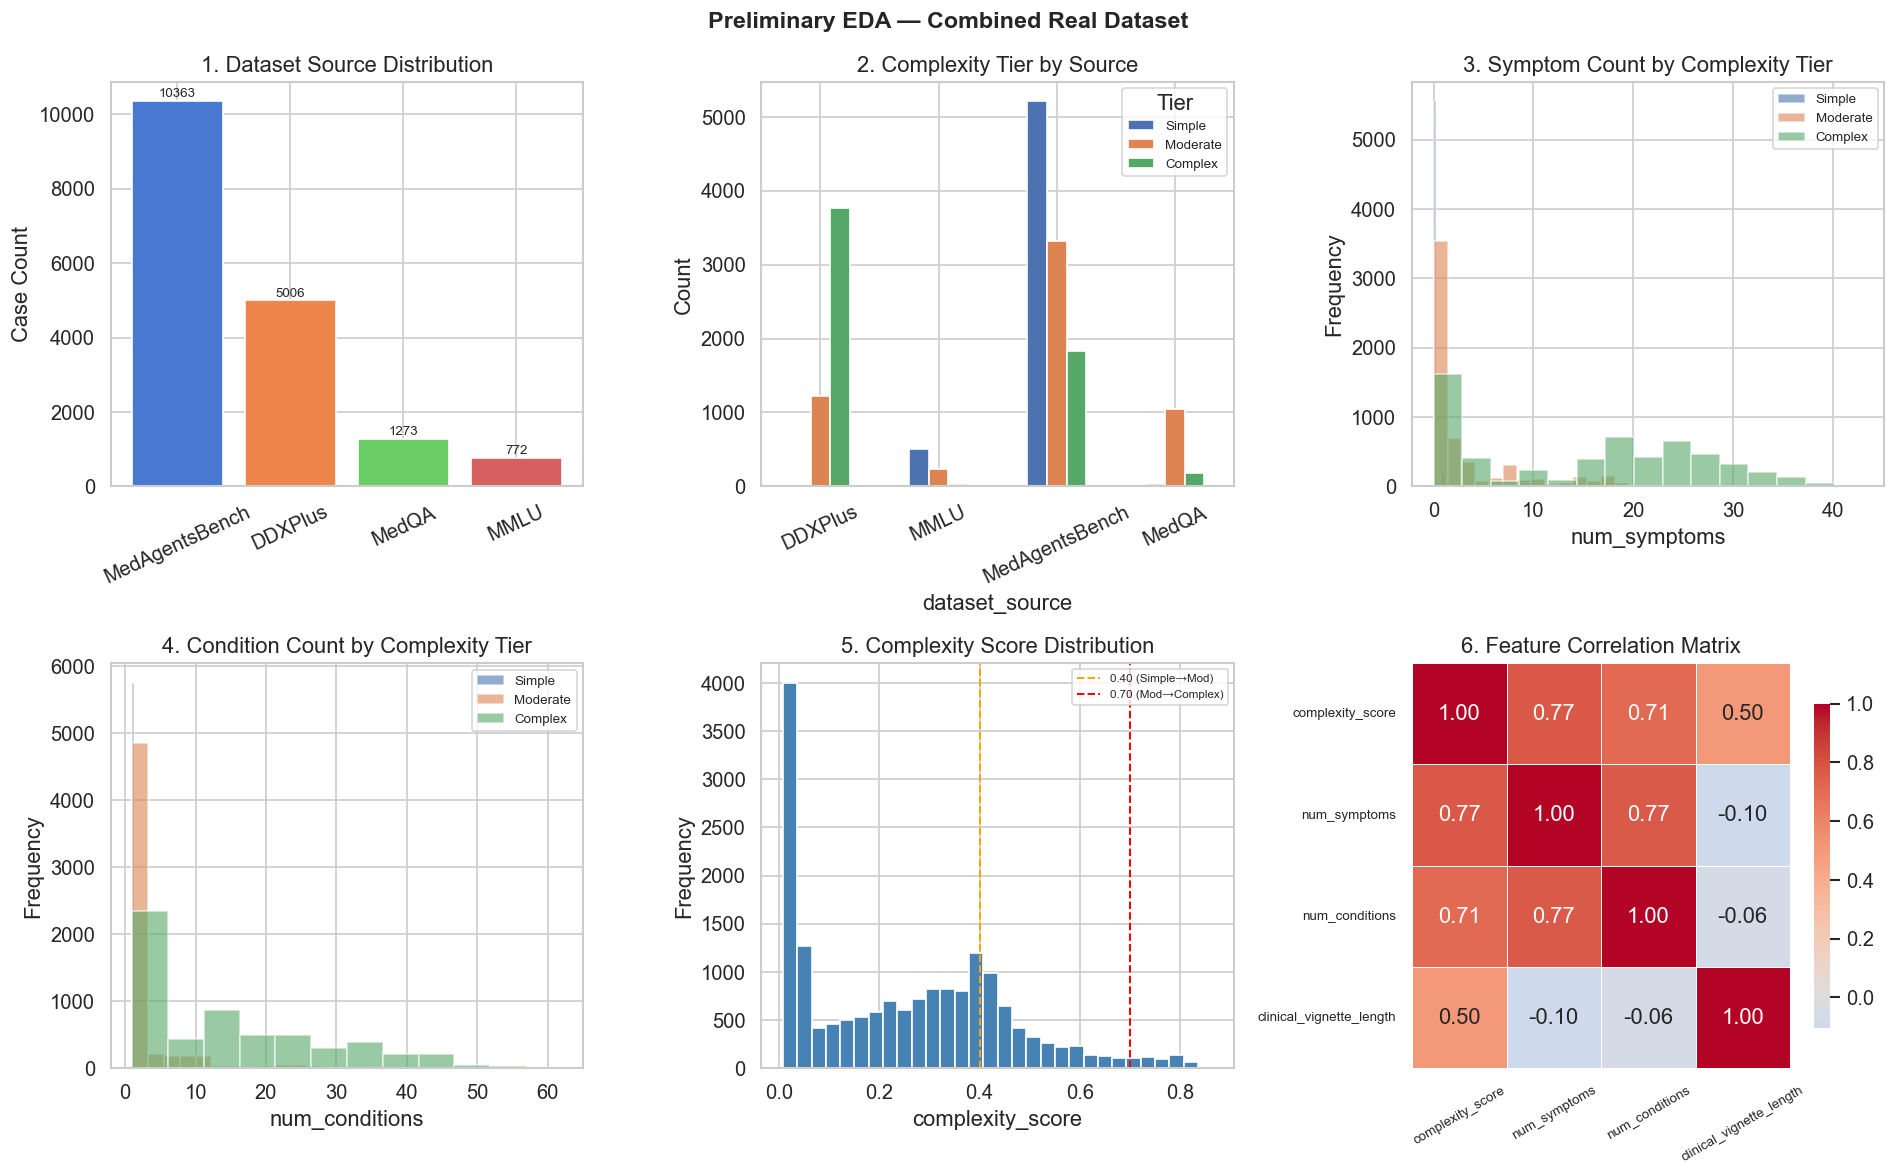


── Summary Statistics by Dataset Source ──
                n_cases  pct_simple  pct_moderate  pct_complex  mean_symptoms  mean_conditions  mean_score
dataset_source                                                                                            
DDXPlus            5006         0.5          24.4         75.1          19.70             18.4       0.459
MMLU                772        65.3          30.8          3.9           0.33              1.0       0.099
MedAgentsBench    10363        50.3          32.0         17.7           0.52              1.0       0.167
MedQA              1273         3.1          82.3         14.6           1.10              1.0       0.256

── Missing Value Audit ──
No missing values.


In [102]:
# ── §1.7: Preliminary EDA on combined_df (pre-inference case-level data) ──────
print(f"Total cases: {len(combined_df):,}")
print(f"Sources:     {combined_df['dataset_source'].nunique()}")
print(f"Columns:     {list(combined_df.columns)}")
print()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Preliminary EDA — Combined Real Dataset', fontsize=14, fontweight='bold')

# ── 1. Source distribution ────────────────────────────────────────────────────
src_counts = combined_df['dataset_source'].value_counts()
axes[0, 0].bar(src_counts.index, src_counts.values,
               color=sns.color_palette('muted', len(src_counts)), edgecolor='white')
axes[0, 0].set_title('1. Dataset Source Distribution')
axes[0, 0].set_ylabel('Case Count')
axes[0, 0].tick_params(axis='x', rotation=25)
for i, (s, cnt) in enumerate(src_counts.items()):
    axes[0, 0].text(i, cnt + max(src_counts) * 0.01, str(cnt), ha='center', fontsize=8)

# ── 2. Complexity tier by source ──────────────────────────────────────────────
tier_by_src = (combined_df.groupby(['dataset_source', 'task_complexity'])
               .size().unstack(fill_value=0))
tier_by_src = tier_by_src.reindex(columns=['Simple', 'Moderate', 'Complex'], fill_value=0)
tier_by_src.plot(kind='bar', ax=axes[0, 1],
                 color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white')
axes[0, 1].set_title('2. Complexity Tier by Source')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=25)
axes[0, 1].legend(title='Tier', fontsize=8)

# ── 3. Symptom count by complexity tier ───────────────────────────────────────
for tier, color in zip(COMPLEXITY_TIERS, ['#4C72B0', '#DD8452', '#55A868']):
    sub = combined_df[combined_df['task_complexity'] == tier]['num_symptoms']
    axes[0, 2].hist(sub, bins=15, alpha=0.6, label=tier, color=color, edgecolor='white')
axes[0, 2].set_title('3. Symptom Count by Complexity Tier')
axes[0, 2].set_xlabel('num_symptoms')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend(fontsize=8)

# ── 4. Condition count by complexity tier ─────────────────────────────────────
for tier, color in zip(COMPLEXITY_TIERS, ['#4C72B0', '#DD8452', '#55A868']):
    sub = combined_df[combined_df['task_complexity'] == tier]['num_conditions']
    axes[1, 0].hist(sub, bins=12, alpha=0.6, label=tier, color=color, edgecolor='white')
axes[1, 0].set_title('4. Condition Count by Complexity Tier')
axes[1, 0].set_xlabel('num_conditions')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend(fontsize=8)

# ── 5. Complexity score distribution ─────────────────────────────────────────
combined_df['complexity_score'].hist(bins=30, ax=axes[1, 1],
                                     color='steelblue', edgecolor='white')
axes[1, 1].set_title('5. Complexity Score Distribution')
axes[1, 1].set_xlabel('complexity_score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(0.40, color='orange', linestyle='--', linewidth=1.2, label='0.40 (Simple→Mod)')
axes[1, 1].axvline(0.70, color='red',    linestyle='--', linewidth=1.2, label='0.70 (Mod→Complex)')
axes[1, 1].legend(fontsize=7)

# ── 6. Feature correlation heatmap ────────────────────────────────────────────
num_cols = ['complexity_score', 'num_symptoms', 'num_conditions', 'clinical_vignette_length']
corr_df  = combined_df[num_cols].corr()
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1, 2], linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1, 2].set_title('6. Feature Correlation Matrix')
axes[1, 2].tick_params(axis='x', rotation=30, labelsize=8)
axes[1, 2].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_eda_overview.png', bbox_inches='tight')
plt.show()

# ── Summary statistics table ──────────────────────────────────────────────────
print("\n── Summary Statistics by Dataset Source ──")
summary_eda = (combined_df.groupby('dataset_source')
               .agg(
                   n_cases         =('question_id', 'count'),
                   pct_simple      =('task_complexity', lambda x: round((x == 'Simple').mean() * 100, 1)),
                   pct_moderate    =('task_complexity', lambda x: round((x == 'Moderate').mean() * 100, 1)),
                   pct_complex     =('task_complexity', lambda x: round((x == 'Complex').mean() * 100, 1)),
                   mean_symptoms   =('num_symptoms', lambda x: round(x.mean(), 2)),
                   mean_conditions =('num_conditions', lambda x: round(x.mean(), 2)),
                   mean_score      =('complexity_score', lambda x: round(x.mean(), 3)),
               ))
print(summary_eda.to_string())

# ── Missing value audit ────────────────────────────────────────────────────────
print("\n── Missing Value Audit ──")
miss = combined_df.isnull().sum()
miss_nonzero = miss[miss > 0]
if len(miss_nonzero) == 0:
    print("No missing values.")
else:
    print(miss_nonzero.to_string())


§1.7a  SUPPLEMENTARY EDA

── 1. Complexity Tier Balance (overall) ──
                 count   pct
task_complexity             
Moderate          5820  33.4
Complex           5810  33.4
Simple            5784  33.2

── 2. Source × Complexity Tier — Chi-squared Independence Test ──
  χ²(6) = 7868.42,  p = 0.0000
  ✗ CONFOUNDED: complexity tier distribution differs significantly across sources.
    RQ2 results should be interpreted with this source–complexity overlap in mind.

── 3. Dead / Collinear Feature Audit ──
  has_structured_labs: column absent.
  step_level: column absent.

── 4. VIF — RQ4 Numeric Feature Matrix ──
                 feature   VIF
        complexity_score 76.24
            num_symptoms 20.51
          num_conditions  6.23
clinical_vignette_length 25.38
  ⚠ VIF > 5 for: ['complexity_score', 'num_symptoms', 'num_conditions', 'clinical_vignette_length']
    complexity_score is a linear combination of its components — use either the score OR its raw features in the RQ4

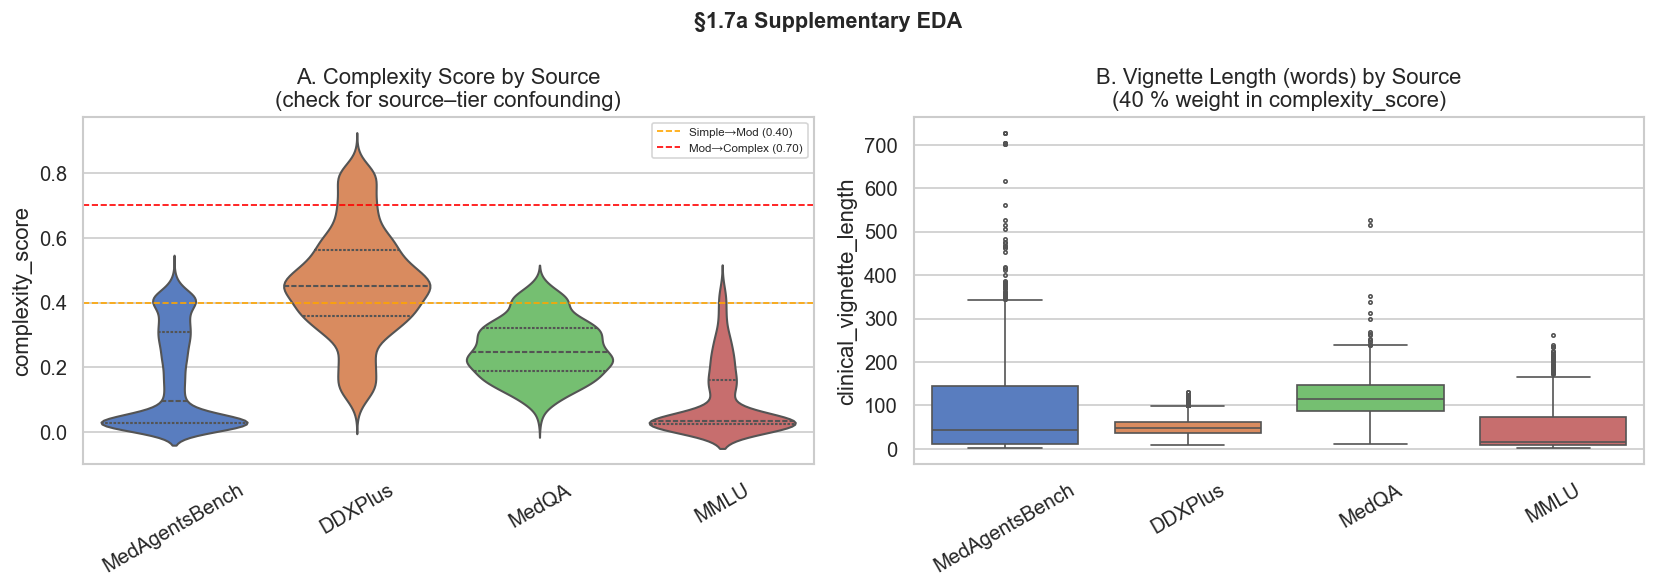


Figure saved → outputs/fig_eda_supplementary.png


In [103]:
# ── §1.7a: Supplementary EDA — Confounding, Feature Quality & Balance ─────────
# Covers five gaps identified in the primary EDA:
#   1. Source–complexity confounding (Chi-squared + violin)
#   2. Dead feature audit (has_structured_labs, step_level)
#   3. VIF check for RQ4 feature matrix multicollinearity
#   4. clinical_vignette_length distribution by source
#   5. Complexity tier balance (explicit proportions)

from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

print("=" * 65)
print("§1.7a  SUPPLEMENTARY EDA")
print("=" * 65)

# ── 1. Complexity tier class balance ─────────────────────────────────────────
print("\n── 1. Complexity Tier Balance (overall) ──")
tier_balance = combined_df['task_complexity'].value_counts(normalize=True).mul(100).round(1)
tier_counts  = combined_df['task_complexity'].value_counts()
tier_summary = pd.DataFrame({'count': tier_counts, 'pct': tier_balance})
print(tier_summary.to_string())
if tier_balance.min() < 15:
    print("  ⚠ WARNING: minority tier < 15 % — ANOVA cell counts may be low.")

# ── 2. Source–complexity confounding: Chi-squared test ───────────────────────
print("\n── 2. Source × Complexity Tier — Chi-squared Independence Test ──")
ct = pd.crosstab(combined_df['dataset_source'], combined_df['task_complexity'])
chi2, p_chi2, dof, _ = chi2_contingency(ct)
print(f"  χ²({dof}) = {chi2:.2f},  p = {p_chi2:.4f}")
if p_chi2 < 0.05:
    print("  ✗ CONFOUNDED: complexity tier distribution differs significantly across sources.")
    print("    RQ2 results should be interpreted with this source–complexity overlap in mind.")
else:
    print("  ✓ Not significantly confounded (p ≥ .05).")

# ── 3. Dead feature audit ─────────────────────────────────────────────────────
print("\n── 3. Dead / Collinear Feature Audit ──")
if 'has_structured_labs' in combined_df.columns:
    hsl = combined_df['has_structured_labs'].value_counts()
    print(f"has_structured_labs value counts:{hsl.to_string()}")
    if hsl.index.tolist() == [0] or (len(hsl) == 1):
        print("  ⚠ has_structured_labs is constant (all zeros) — zero-variance feature; "
              "drop from RQ4 classifier.")
else:
    print("  has_structured_labs: column absent.")

if 'step_level' in combined_df.columns:
    sl = combined_df['step_level'].value_counts()
    print(f"step_level value counts:{sl.to_string()}")
    medqa_flag = (combined_df['dataset_source'] == 'MedQA') if 'MedQA' in combined_df['dataset_source'].values else None
    if medqa_flag is not None:
        overlap = (combined_df['step_level'] == 2).eq(medqa_flag).mean()
        print(f"  step_level==2 ↔ MedQA overlap: {overlap:.1%} — "
              f"{'near-perfect collinearity with dataset_source dummy' if overlap > 0.95 else 'partial overlap'}.")
else:
    print("  step_level: column absent.")

# ── 4. VIF for RQ4 feature matrix ────────────────────────────────────────────
print("\n── 4. VIF — RQ4 Numeric Feature Matrix ──")
vif_cols = [c for c in ['complexity_score', 'num_symptoms', 'num_conditions',
                         'clinical_vignette_length'] if c in combined_df.columns]
vif_data = combined_df[vif_cols].fillna(0).astype(float)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    vif_vals = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_cols))]
vif_df = pd.DataFrame({'feature': vif_cols, 'VIF': [round(v, 2) for v in vif_vals]})
print(vif_df.to_string(index=False))
high_vif = vif_df[vif_df['VIF'] > 5]
if len(high_vif):
    print(f"  ⚠ VIF > 5 for: {high_vif['feature'].tolist()}")
    print("    complexity_score is a linear combination of its components — "
          "use either the score OR its raw features in the RQ4 classifier, not both.")

# ── 5. Visualisations: violin plots ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('§1.7a Supplementary EDA', fontsize=13, fontweight='bold')

# Panel A: complexity_score by source
src_order = combined_df['dataset_source'].value_counts().index.tolist()
sns.violinplot(data=combined_df, x='dataset_source', y='complexity_score',
               order=src_order, palette='muted', inner='quartile', ax=axes[0])
axes[0].axhline(0.40, color='orange', linestyle='--', linewidth=1, label='Simple→Mod (0.40)')
axes[0].axhline(0.70, color='red',    linestyle='--', linewidth=1, label='Mod→Complex (0.70)')
axes[0].set_title('A. Complexity Score by Source\n(check for source–tier confounding)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=7)

# Panel B: clinical_vignette_length by source
sns.boxplot(data=combined_df, x='dataset_source', y='clinical_vignette_length',
            order=src_order, palette='muted', fliersize=2, ax=axes[1])
axes[1].set_title('B. Vignette Length (words) by Source\n(40 % weight in complexity_score)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_eda_supplementary.png', bbox_inches='tight')
plt.show()
print("\nFigure saved → outputs/fig_eda_supplementary.png")


In [ ]:
# ── Patch 3: Use adaptive_router for routing_decision in adaptive config ──
# In real-API mode the src.agents.adaptive_router(c_score) function is used
# instead of the hard-coded routing_map dict above.
# Import is already available via the Section 0 setup cell:
#   from src.agents import adaptive_router as _router
# Usage in the live simulation loop:
#   routing_decision = _router(c_score) if cfg == 'adaptive' else CANONICAL_ROUTING[cfg]

---
## Section 2 — Complexity Feature Engineering

In [104]:
# NOTE: This local definition is superseded by the import in the next cell (§2 Patch 4).
# After that import executes, compute_complexity_features refers to the
# calibration-aware version in src/preprocessing.py (no df.max() leakage).
def compute_complexity_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive NLP-based complexity_score and associated features from the
    clinical_vignette column.  When the column is absent the function
    is a no-op (simulation data already has these fields).
    """
    if 'clinical_vignette' not in df.columns:
        return df

    df = df.copy()

    if 'clinical_vignette_length' not in df.columns:
        df['clinical_vignette_length'] = df['clinical_vignette'].str.len().fillna(0).astype(int)

    if 'num_symptoms' not in df.columns:
        # Heuristic: count comma-separated or semicolon-separated symptom mentions
        symptom_pattern = re.compile(
            r'\b(fever|pain|dyspnea|cough|fatigue|nausea|vomiting|'
            r'dizziness|headache|rash|edema|tachycardia|bradycardia|'
            r'hypotension|hypertension|confusion|weakness|bleeding)\b',
            re.IGNORECASE
        )
        df['num_symptoms'] = df['clinical_vignette'].apply(
            lambda t: len(set(symptom_pattern.findall(str(t))))
        )

    if 'num_conditions' not in df.columns:
        df['num_conditions'] = 1  # default; overridden by DDXPlus loader

    if 'complexity_score' not in df.columns:
        # Composite score: normalised average of three proxy features
        max_len  = df['clinical_vignette_length'].max() or 1
        max_symp = df['num_symptoms'].max() or 1
        max_cond = df['num_conditions'].max() or 1
        df['complexity_score'] = (
            df['clinical_vignette_length'] / max_len * 0.4
            + df['num_symptoms']           / max_symp * 0.4
            + df['num_conditions']          / max_cond * 0.2
        ).round(4)

    if 'task_complexity' not in df.columns:
        df['task_complexity'] = pd.cut(
            df['complexity_score'],
            bins=[-0.01, 0.35, 0.65, 1.01],
            labels=['Simple', 'Moderate', 'Complex']
        ).astype(str)

    return df

Tier thresholds: Simple < 0.1017 ≤ Moderate < 0.3570 ≤ Complex

Complexity tier distribution (target ~33/33/33):
  Simple  : 5,784  (33.2 %)
  Moderate: 5,820  (33.4 %)
  Complex : 5,810  (33.4 %)


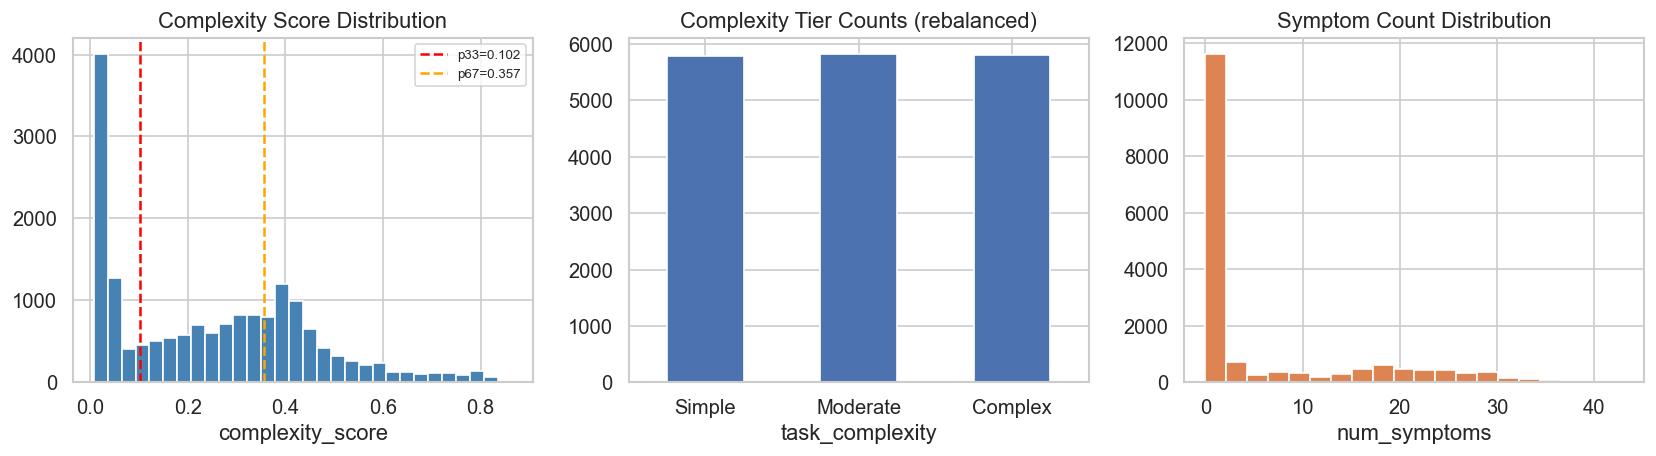

Complexity features applied to combined_df.


In [82]:
# ── §2: Complexity features + data-driven tier thresholds ───────────────────
import importlib, src.preprocessing
importlib.reload(src.preprocessing)
from src.preprocessing import (
    compute_complexity_features,
    compute_tier_thresholds,
)

combined_df = compute_complexity_features(combined_df)

# Data-driven thresholds: 33rd / 67th percentile → ~equal Simple/Moderate/Complex
p33, p67 = compute_tier_thresholds(combined_df)
print(f'Tier thresholds: Simple < {p33:.4f} ≤ Moderate < {p67:.4f} ≤ Complex')

tier_counts = combined_df['task_complexity'].value_counts()
tier_pcts   = combined_df['task_complexity'].value_counts(normalize=True).mul(100).round(1)
print('\nComplexity tier distribution (target ~33/33/33):')
for tier in ['Simple', 'Moderate', 'Complex']:
    print(f'  {tier:8s}: {tier_counts.get(tier, 0):5,}  ({tier_pcts.get(tier, 0):.1f} %)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
combined_df['complexity_score'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(p33, color='red',    linestyle='--', label=f'p33={p33:.3f}')
axes[0].axvline(p67, color='orange', linestyle='--', label=f'p67={p67:.3f}')
axes[0].set_title('Complexity Score Distribution')
axes[0].set_xlabel('complexity_score')
axes[0].legend(fontsize=8)

combined_df['task_complexity'].value_counts().reindex(['Simple','Moderate','Complex']).plot(
    kind='bar', ax=axes[1], color='#4C72B0')
axes[1].set_title('Complexity Tier Counts (rebalanced)')
axes[1].tick_params(axis='x', rotation=0)

combined_df['num_symptoms'].hist(bins=20, ax=axes[2], color='#DD8452', edgecolor='white')
axes[2].set_title('Symptom Count Distribution')
axes[2].set_xlabel('num_symptoms')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_complexity_eda.png', bbox_inches='tight')
plt.show()
print('Complexity features applied to combined_df.')


In [105]:
# ── §2a: Complexity Score Formula Audit & Ceiling Analysis ──────────────────
# Documents why the original formula (vlen/400 + nsymp/15 + ncond/10) stalls
# at a maximum of 0.718 — below the MDT routing threshold of 0.80 — causing
# the MDT tier to never fire and 73% of adaptive cases to route as 'solo'.
#
# Root cause: normalisation caps were set by expert prior without reference to
# observed data. The new formula uses caps calibrated to observed p95 values.

# ── Observed p95 feature values (calibration basis for new caps) ─────────────
p95_vlen  = float(combined_df['clinical_vignette_length'].quantile(0.95))
p95_nsymp = float(combined_df['num_symptoms'].quantile(0.95))
p95_ncond = float(combined_df['num_conditions'].quantile(0.95))

print('=== Feature Distribution: p95 vs Normalisation Cap ===')
print(f'{"Feature":<28} {"p50":>6} {"p95":>6} {"Old cap":>8} {"New cap":>8}')
print('-' * 60)
print(f'{"clinical_vignette_length":<28}'
      f' {combined_df["clinical_vignette_length"].median():>6.0f}'
      f' {p95_vlen:>6.0f}  {"400":>8}  {"200":>8}')
print(f'{"num_symptoms":<28}'
      f' {combined_df["num_symptoms"].median():>6.0f}'
      f' {p95_nsymp:>6.0f}  {"15":>8}  {"30":>8}')
print(f'{"num_conditions":<28}'
      f' {combined_df["num_conditions"].median():>6.0f}'
      f' {p95_ncond:>6.0f}  {"10":>8}  {"35":>8}')

# ── Compute OLD formula scores inline for comparison ─────────────────────────
_old_score = (
    combined_df['clinical_vignette_length'].fillna(0).clip(upper=400) / 400 * 0.4
    + combined_df['num_symptoms'].fillna(0).clip(upper=15) / 15 * 0.4
    + combined_df['num_conditions'].fillna(1).clip(upper=10) / 10 * 0.2
).clip(0, 1).round(4)

def _route(s):
    if s < 0.40:   return 'solo'
    elif s < 0.60: return 'group-2'
    elif s < 0.80: return 'group-3'
    else:          return 'MDT'

_old_routing = _old_score.apply(_route)

print('\n=== OLD formula: complexity_score statistics ===')
print(f'  mean={_old_score.mean():.3f}  median={_old_score.median():.3f}  '
      f'max={_old_score.max():.3f}  (MDT threshold = 0.80)')
print(f'  MDT fires: {"YES ✓" if (_old_routing == "MDT").any() else "NO ✗  ← MDT UNREACHABLE"}')

print('\n=== OLD formula routing distribution (n=%d) ===' % len(_old_routing))
for tier in ['solo', 'group-2', 'group-3', 'MDT']:
    n = (_old_routing == tier).sum()
    print(f'  {tier:<12} {n:>5}  ({n/len(_old_routing)*100:4.1f}%)')

# ── Component-level contribution (why vlen barely matters) ────────────────────
_vlen_c  = (combined_df['clinical_vignette_length'].fillna(0).clip(upper=400)  / 400  * 0.4)
_nsymp_c = (combined_df['num_symptoms'].fillna(0).clip(upper=15) / 15 * 0.4)
_ncond_c = (combined_df['num_conditions'].fillna(1).clip(upper=10) / 10 * 0.2)

print('\n=== OLD formula: mean component contributions ===')
print(f'  vlen  (×0.4, cap 400): mean={_vlen_c.mean():.3f}'
      f'  corr(vlen, score)={combined_df["clinical_vignette_length"].corr(_old_score):.3f}')
print(f'  nsymp (×0.4, cap  15): mean={_nsymp_c.mean():.3f}'
      f'  corr(nsymp, score)={combined_df["num_symptoms"].corr(_old_score):.3f}')
print(f'  ncond (×0.2, cap  10): mean={_ncond_c.mean():.3f}'
      f'  corr(ncond, score)={combined_df["num_conditions"].corr(_old_score):.3f}')
print('  → vlen contributes < 20% of mean score; MDT is structurally unreachable.')


=== Feature Distribution: p95 vs Normalisation Cap ===
Feature                         p50    p95  Old cap  New cap
------------------------------------------------------------
clinical_vignette_length         50    209       400       200
num_symptoms                      1     27        15        30
num_conditions                    1     32        10        35

=== OLD formula: complexity_score statistics ===
  mean=0.252  median=0.173  max=0.732  (MDT threshold = 0.80)
  MDT fires: NO ✗  ← MDT UNREACHABLE

=== OLD formula routing distribution (n=17414) ===
  solo         12775  (73.4%)
  group-2       1484  ( 8.5%)
  group-3       3155  (18.1%)
  MDT              0  ( 0.0%)

=== OLD formula: mean component contributions ===
  vlen  (×0.4, cap 400): mean=0.074  corr(vlen, score)=0.156
  nsymp (×0.4, cap  15): mean=0.114  corr(nsymp, score)=0.911
  ncond (×0.2, cap  10): mean=0.064  corr(ncond, score)=0.786
  → vlen contributes < 20% of mean score; MDT is structurally unreachable.


=== Routing distribution: OLD formula (caps 400 / 15 / 10) ===
  solo         12775  (73.4%)
  group-2       1484  ( 8.5%)
  group-3       3155  (18.1%)
  MDT              0  ( 0.0%)
  Score range: [0.021, 0.732]

=== Routing distribution: NEW formula (caps 200 / 30 / 35) ===
  solo         12854  (73.8%)
  group-2       3597  (20.7%)
  group-3        852  ( 4.9%)
  MDT            111  ( 0.6%)
  Score range: [0.008, 0.864]


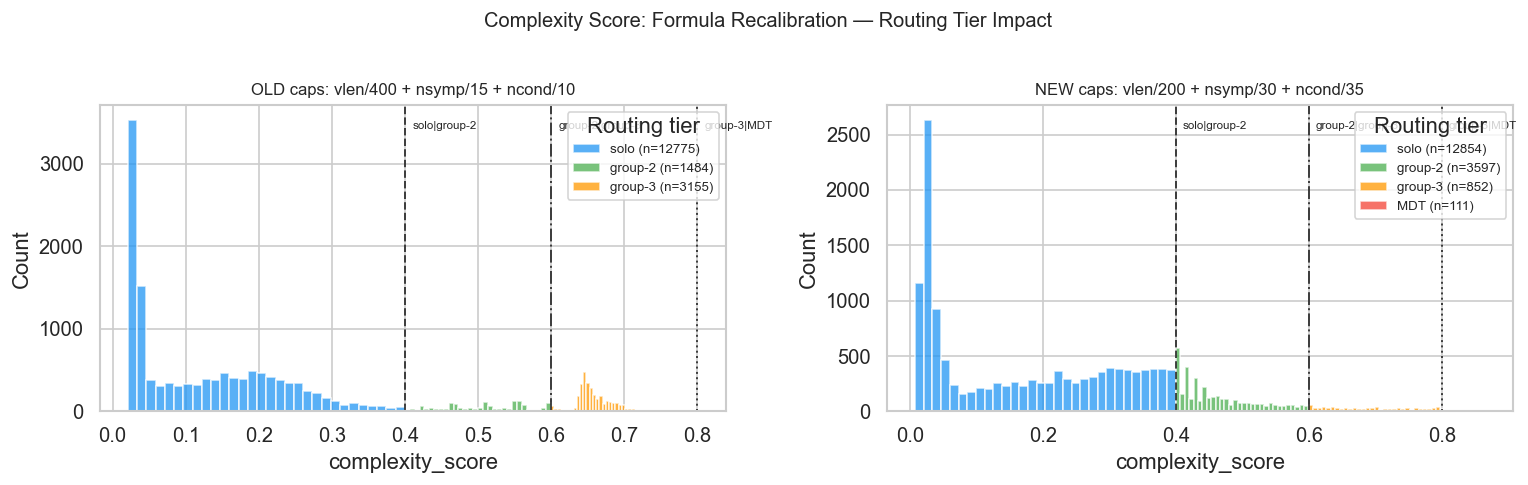

Saved → outputs/fig_complexity_audit.png


In [106]:
# ── §2b: Complexity Score — Before / After Recalibration ────────────────────
# Compares the OLD formula (caps: 400/15/10) with the NEW formula (200/30/35)
# now active in src/preprocessing.py. combined_df already carries the new score.

import matplotlib.pyplot as plt

_old_score = (
    combined_df['clinical_vignette_length'].fillna(0).clip(upper=400) / 400 * 0.4
    + combined_df['num_symptoms'].fillna(0).clip(upper=15) / 15 * 0.4
    + combined_df['num_conditions'].fillna(1).clip(upper=10) / 10 * 0.2
).clip(0, 1).round(4)

_new_score = combined_df['complexity_score']  # recalibrated formula

def _route(s):
    if s < 0.40:   return 'solo'
    elif s < 0.60: return 'group-2'
    elif s < 0.80: return 'group-3'
    else:          return 'MDT'

_old_routing = _old_score.apply(_route)
_new_routing = _new_score.apply(_route)

print('=== Routing distribution: OLD formula (caps 400 / 15 / 10) ===')
for tier in ['solo', 'group-2', 'group-3', 'MDT']:
    n = (_old_routing == tier).sum()
    print(f'  {tier:<12} {n:>5}  ({n/len(_old_routing)*100:4.1f}%)')
print(f'  Score range: [{_old_score.min():.3f}, {_old_score.max():.3f}]')

print('\n=== Routing distribution: NEW formula (caps 200 / 30 / 35) ===')
for tier in ['solo', 'group-2', 'group-3', 'MDT']:
    n = (_new_routing == tier).sum()
    print(f'  {tier:<12} {n:>5}  ({n/len(_new_routing)*100:4.1f}%)')
print(f'  Score range: [{_new_score.min():.3f}, {_new_score.max():.3f}]')

# ── Side-by-side histogram ────────────────────────────────────────────────────
_routing_colors = {'solo': '#2196F3', 'group-2': '#4CAF50', 'group-3': '#FF9800', 'MDT': '#F44336'}
_routing_thresholds = [(0.40, '--', 'solo|group-2'), (0.60, '-.', 'group-2|group-3'), (0.80, ':', 'group-3|MDT')]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, score, routing, title in [
    (axes[0], _old_score, _old_routing, 'OLD caps: vlen/400 + nsymp/15 + ncond/10'),
    (axes[1], _new_score, _new_routing, 'NEW caps: vlen/200 + nsymp/30 + ncond/35'),
]:
    for tier in ['solo', 'group-2', 'group-3', 'MDT']:
        vals = score[routing == tier]
        if len(vals):
            ax.hist(vals, bins=30, alpha=0.75, color=_routing_colors[tier], label=f'{tier} (n={len(vals)})')
    ylim = ax.get_ylim()
    for t, ls, lbl in _routing_thresholds:
        ax.axvline(t, color='black', lw=1.2, ls=ls, alpha=0.7)
        ax.text(t + 0.01, ylim[1] * 0.95, lbl, fontsize=7, va='top')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('complexity_score')
    ax.set_ylabel('Count')
    ax.legend(title='Routing tier', fontsize=8, loc='upper right')

plt.suptitle('Complexity Score: Formula Recalibration — Routing Tier Impact', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_complexity_audit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → outputs/fig_complexity_audit.png')


---
## Section 3 — Multi-Agent System Implementation

In [107]:
# ─── Agent roles ──────────────────────────────────────────────────────────────
AGENT_ROLES = {
    'solo':    ['Generalist'],
    'group-2': ['Internist', 'Specialist'],
    'group-3': ['Internist', 'Specialist', 'Moderator'],
    'MDT':     ['Internist', 'Specialist', 'Radiologist', 'Pharmacist', 'Moderator'],
}

SYSTEM_PROMPTS = {
    'Generalist': (
        'You are a board-certified general-practice physician. '
        'Diagnose the following case concisely. '
        'Respond with the single most likely diagnosis only.'
    ),
    'Internist': (
        'You are a board-certified internist contributing to a multi-specialist '
        'diagnostic panel. Provide your primary diagnosis and key clinical reasoning.'
    ),
    'Specialist': (
        'You are a specialist (cardiology / pulmonology / neurology as appropriate). '
        'Critically evaluate the case. State your diagnosis and any differential.'
    ),
    'Radiologist': (
        'You are a radiologist. Comment on imaging findings implied by the case '
        'and their diagnostic implications.'
    ),
    'Pharmacist': (
        'You are a clinical pharmacist. Identify any drug-disease interactions '
        'or pharmacological clues relevant to the diagnosis.'
    ),
    'Moderator': (
        'You are the diagnostic moderator. Synthesize the inputs from your '
        'colleagues and return a single final diagnosis.'
    ),
}


class TokenTracker:
    """Accumulate token usage across an inference run."""
    def __init__(self):
        self.prompt_tokens     = 0
        self.completion_tokens = 0

    def add(self, usage):
        if hasattr(usage, 'prompt_tokens'):
            self.prompt_tokens     += usage.prompt_tokens
            self.completion_tokens += usage.completion_tokens
        elif isinstance(usage, dict):
            self.prompt_tokens     += usage.get('prompt_tokens', 0)
            self.completion_tokens += usage.get('completion_tokens', 0)

    @property
    def total(self):
        return self.prompt_tokens + self.completion_tokens


def openai_call(system: str, user: str, model: str = 'gpt-4o-mini') -> Tuple[str, dict]:
    """Thin wrapper around OpenAI chat completion."""
    import openai
    client = openai.OpenAI(api_key=OPENAI_API_KEY)
    resp = client.chat.completions.create(
        model=model,
        messages=[{'role': 'system', 'content': system},
                  {'role': 'user',   'content': user}],
        max_tokens=512,
        temperature=0.0,
    )
    text  = resp.choices[0].message.content.strip()
    usage = {'prompt_tokens':     resp.usage.prompt_tokens,
             'completion_tokens': resp.usage.completion_tokens}
    return text, usage


# Map backbone display names to Anthropic model IDs
_ANTHROPIC_MODEL_MAP = {
    'claude-haiku':  'claude-haiku-4-5-20251001',
    'claude-sonnet': 'claude-sonnet-4-6',
    'claude-opus':   'claude-opus-4-7',
}

def anthropic_call(system: str, user: str, backbone: str = 'claude-sonnet') -> Tuple[str, dict]:
    """Thin wrapper around Anthropic Messages API."""
    import anthropic
    model = _ANTHROPIC_MODEL_MAP.get(backbone.lower(), 'claude-haiku-4-5-20251001')
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    resp = client.messages.create(
        model=model,
        max_tokens=512,
        temperature=0,
        system=system,
        messages=[{'role': 'user', 'content': user}],
    )
    text_blocks = [b for b in resp.content if hasattr(b, 'text')]
    if not text_blocks:
        raise RuntimeError(
            f"Anthropic API returned no text content. "
            f"stop_reason={resp.stop_reason!r}, model={model!r}"
        )
    text  = text_blocks[0].text.strip()
    usage = {'prompt_tokens':     resp.usage.input_tokens,
             'completion_tokens': resp.usage.output_tokens}
    return text, usage


def llm_call(system: str, user: str, backbone: str) -> Tuple[str, dict]:
    """Route to the correct backend."""
    backbone = backbone.lower()
    if 'claude' in backbone:
        return anthropic_call(system, user, backbone=backbone)
    elif 'llama' in backbone:
        # Local Ollama / vLLM endpoint — adapt as needed
        raise NotImplementedError('Configure Llama endpoint in llm_call()')
    else:
        model = 'gpt-4o' if 'gpt-4o' in backbone else 'gpt-4o-mini'
        return openai_call(system, user, model=model)


print('Agent scaffolding defined.')

Agent scaffolding defined.


In [108]:
def complexity_assessor(vignette: str, backbone: str) -> Tuple[str, float, dict]:
    """
    MDAgents-style complexity estimator.
    Returns (tier, score, usage): tier is Simple/Moderate/Complex,
    score is a representative float in [0,1] for that tier.
    """
    system = (
        'You are a medical triage classifier. '
        'Classify the clinical complexity of the case as exactly one of: '
        'Simple, Moderate, or Complex. '
        'Respond with ONLY that single word.'
    )
    result, usage = llm_call(system, vignette, backbone)
    tier = result.strip().capitalize()
    if tier not in COMPLEXITY_TIERS:
        tier = 'Moderate'
    # Map tier to representative score for 4-tier routing
    score = {'Simple': 0.20, 'Moderate': 0.50, 'Complex': 0.85}[tier]
    return tier, score, usage


def adaptive_router(complexity_score: float) -> str:
    """Map 0-1 complexity score to routing tier — synopsis §2 thresholds.
    <0.40 → solo, 0.40-0.60 → group-2, 0.60-0.80 → group-3, ≥0.80 → MDT
    """
    if complexity_score < 0.40:
        return 'solo'
    elif complexity_score < 0.60:
        return 'group-2'
    elif complexity_score < 0.80:
        return 'group-3'
    else:
        return 'MDT'


def run_single_agent(vignette: str, backbone: str) -> Tuple[str, int, int]:
    """Returns (answer, total_tokens, reasoning_steps)."""
    tracker = TokenTracker()
    system  = SYSTEM_PROMPTS['Generalist']
    answer, usage = llm_call(system, vignette, backbone)
    tracker.add(usage)
    return answer, tracker.total, 1


def run_static_multi_agent(vignette: str, backbone: str,
                           tier: str = 'group-3') -> Tuple[str, int, int]:
    """Static MAS: always uses the same collaboration tier."""
    tracker = TokenTracker()
    roles   = AGENT_ROLES[tier]
    opinions: List[str] = []

    for role in roles[:-1]:   # all except moderator
        sys_p  = SYSTEM_PROMPTS[role]
        ctx    = vignette
        if opinions:
            ctx += '\n\nPrior opinions:\n' + '\n'.join(f'- {o}' for o in opinions)
        opinion, usage = llm_call(sys_p, ctx, backbone)
        tracker.add(usage)
        opinions.append(f'{role}: {opinion}')

    # Moderator synthesis
    mod_ctx = vignette + '\n\nPanel inputs:\n' + '\n'.join(opinions)
    final, usage = llm_call(SYSTEM_PROMPTS['Moderator'], mod_ctx, backbone)
    tracker.add(usage)

    return final, tracker.total, len(roles)


def run_adaptive_multi_agent(vignette: str, backbone: str) -> Tuple[str, int, int, str, int]:
    """Adaptive MAS: classify complexity first, then select routing tier.
    Returns (answer, total_tokens, steps, routing_tier, routing_overhead_tokens).
    """
    routing_tracker = TokenTracker()

    # Step 1 — complexity assessment (routing overhead)
    tier, score, assess_usage = complexity_assessor(vignette, backbone)
    routing_tracker.add(assess_usage)
    routing_overhead = routing_tracker.total

    # Step 2 — score-based 4-tier routing
    routing = adaptive_router(score)

    # Step 3 — run appropriate config
    if routing == 'solo':
        answer, inf_tokens, steps = run_single_agent(vignette, backbone)
    else:
        answer, inf_tokens, steps = run_static_multi_agent(vignette, backbone, tier=routing)

    total_tokens = routing_overhead + inf_tokens
    return answer, total_tokens, steps, routing, routing_overhead


print('run_single_agent / run_static_multi_agent / run_adaptive_multi_agent defined.')

run_single_agent / run_static_multi_agent / run_adaptive_multi_agent defined.


---
## Section 4 — Inference Runs (Baseline + Adaptive)

In [117]:

# ── §4: Inference — Batch API (production) + Async (dev) ────────────────────────────────────
import anthropic as _anthropic_sdk
import asyncio, hashlib, time
from copy import deepcopy
from pathlib import Path
from tqdm.auto import tqdm

import importlib
import src.agents as _agents_mod
importlib.reload(_agents_mod)

from src.evaluator    import answer_is_correct as _eval_answer_is_correct
from src.agents       import (adaptive_router, build_batch_request,
                               run_single_agent, run_static_multi_agent,
                               run_single_agent_async, run_static_multi_agent_async,
                               safe_acc_per_1k, SYSTEM_PROMPTS)
from src.llm_client   import LLMClient, AsyncLLMClient, BACKBONE_MODEL_MAP

BATCH_CHECKPOINT_DIR = OUTPUT_DIR / 'batch_checkpoints'
BATCH_CHECKPOINT_DIR.mkdir(exist_ok=True)

# ─── Helpers ─────────────────────────────────────────────────────────────────────────────

def _submit_and_wait(requests, round_name, client_anth):
    """Submit a batch round, poll until done, return {custom_id: {text, usage}}.
    Saves batch_id to a sidecar file before polling so a crashed run can resume
    without resubmitting. Loads from checkpoint JSON if the round already finished.
    """
    ckpt     = BATCH_CHECKPOINT_DIR / f'{round_name}.json'
    bid_file = BATCH_CHECKPOINT_DIR / f'{round_name}.batch_id'
    if ckpt.exists():
        print(f'  [{round_name}] Loaded from checkpoint.')
        return json.loads(ckpt.read_text())

    if bid_file.exists():
        batch_id = bid_file.read_text().strip()
        print(f'  [{round_name}] Resuming batch {batch_id}...')
    else:
        batch    = client_anth.messages.batches.create(requests=requests)
        batch_id = batch.id
        bid_file.write_text(batch_id)  # persist before polling so crashes are resumable
        print(f'  [{round_name}] Submitted {len(requests):,} requests -- batch_id={batch_id}')

    while True:
        batch = client_anth.messages.batches.retrieve(batch_id)
        if batch.processing_status == 'ended':
            break
        print(f'  [{round_name}] {batch.request_counts.processing} remaining...', end='\r')
        time.sleep(30)

    results = {}
    for result in client_anth.messages.batches.results(batch_id):
        if result.result.type == 'succeeded':
            msg  = result.result.message
            text = next((b.text for b in msg.content if b.type == 'text'), '')
            results[result.custom_id] = {
                'text': text,
                'usage': {'prompt_tokens':     msg.usage.input_tokens,
                          'completion_tokens': msg.usage.output_tokens},
            }
        else:
            results[result.custom_id] = {
                'text': '',
                'usage': {'prompt_tokens': 0, 'completion_tokens': 0},
            }

    ckpt.write_text(json.dumps(results))
    print(f'  [{round_name}] Complete -- {len(results):,} results saved.')
    return results


def _tok(res):
    u = res.get('usage', {})
    return u.get('prompt_tokens', 0) + u.get('completion_tokens', 0)


def _safe_qid(qid: str) -> str:
    """Shorten question_id to fit Batch API 64-char custom_id limit (suffix ≤ 12 chars)."""
    if len(qid) <= 52:
        return qid
    return hashlib.md5(qid.encode()).hexdigest()[:52]


def _assemble_records(rows, r1, r2, r3, routing, mdt_sync, backbone):
    """Merge three batch rounds into results_df rows (same schema as old run_inference)."""
    canonical = {'single-agent': 'solo', 'static_multi-agent': 'group-3'}
    records = []
    for row in rows:
        qid      = row['question_id']
        gt       = str(row['correct_answer'])
        tier     = routing[qid]
        src_key  = row.get('dataset_source')

        base = {k: row.get(k) for k in [
            'question_id', 'dataset_source', 'task_complexity',
            'num_symptoms', 'num_conditions', 'complexity_score',
            'clinical_vignette_length']}
        base['llm_backbone'] = backbone

        sa_res  = r1.get(f'{_safe_qid(qid)}__sa',        {'text': '', 'usage': {}})
        int_res = r1.get(f'{_safe_qid(qid)}__internist', {'text': '', 'usage': {}})
        spe_res = r2.get(f'{_safe_qid(qid)}__specialist',{'text': '', 'usage': {}})
        mod_res = r3.get(f'{_safe_qid(qid)}__moderator', {'text': '', 'usage': {}})

        sa_ans  = sa_res['text']
        sma_ans = mod_res['text']
        sa_tok  = _tok(sa_res)
        sma_tok = _tok(int_res) + _tok(spe_res) + _tok(mod_res)

        if tier == 'MDT' and qid in mdt_sync:
            ada_ans, ada_tok, ada_steps = (
                mdt_sync[qid]['text'], mdt_sync[qid]['tokens'], mdt_sync[qid]['steps'])
        elif tier == 'solo':
            ada_ans, ada_tok, ada_steps = sa_ans, sa_tok, 1
        elif tier == 'group-2':
            ada_ans  = spe_res['text']
            ada_tok  = _tok(int_res) + _tok(spe_res)
            ada_steps = 2
        else:  # group-3
            ada_ans, ada_tok, ada_steps = sma_ans, sma_tok, 3

        for cfg, ans, tok, steps, rd in [
            ('single-agent',       sa_ans,  sa_tok,  1,         canonical['single-agent']),
            ('static_multi-agent', sma_ans, sma_tok, 3,         canonical['static_multi-agent']),
            ('adaptive',           ada_ans, ada_tok, ada_steps, tier),
        ]:
            rec = deepcopy(base)
            rec.update({
                'agent_config':             cfg,
                'predicted_answer':         ans,
                'is_correct':              _eval_answer_is_correct(ans, gt, dataset_source=src_key),
                'token_cost':              tok,
                'latency_ms':             0.0,
                'reasoning_steps':         steps,
                'routing_decision':        rd,
                'routing_overhead_tokens': 0,
                'inference_tokens':        tok,
            })
            records.append(rec)
    return records


# ─── run_inference_batch ────────────────────────────────────────────────────────────

def run_inference_batch(df, backbone='Claude-Haiku'):
    """
    3-round Anthropic Batch API inference (50% cheaper than standard API).
    Checkpoints each round to outputs/batch_checkpoints/ -- safe to restart.

    Round 1: single-agent (Generalist) + static Internist calls (all rows)
    Round 2: static Specialist calls (sees Internist opinion from R1)
    Round 3: static Moderator calls (sees Internist+Specialist from R1+R2)
    MDT: synchronous fallback for rows with complexity_score >= 0.80
    Adaptive routing reuses batch results -- no extra calls.
    """
    client_anth = _anthropic_sdk.Anthropic(api_key=os.getenv('ANTHROPIC_API_KEY', ''))
    model_id    = BACKBONE_MODEL_MAP.get(backbone, backbone)

    _seen = set()
    rows = [r for _, r in df.iterrows()
            if r['question_id'] not in _seen and not _seen.add(r['question_id'])]
    # Deduplicated by question_id to keep batch custom_ids unique
    routing = {row['question_id']: adaptive_router(float(row['complexity_score']))
               for row in rows}

    # Round 1
    r1_reqs = []
    for row in rows:
        qid = row['question_id']; v = str(row['clinical_vignette'])
        r1_reqs.append(build_batch_request(f'{_safe_qid(qid)}__sa',       SYSTEM_PROMPTS['Generalist'], v, model_id))
        r1_reqs.append(build_batch_request(f'{_safe_qid(qid)}__internist', SYSTEM_PROMPTS['Internist'],  v, model_id))
    print(f'Round 1: {len(r1_reqs):,} requests')
    r1 = _submit_and_wait(r1_reqs, 'round1', client_anth)

    # Round 2
    r2_reqs = []
    for row in rows:
        qid = row['question_id']; v = str(row['clinical_vignette'])
        int_op = r1.get(f'{_safe_qid(qid)}__internist', {}).get('text', '')
        ctx    = v + '\n\nPrior opinions:\n- Internist: ' + int_op
        r2_reqs.append(build_batch_request(f'{_safe_qid(qid)}__specialist', SYSTEM_PROMPTS['Specialist'], ctx, model_id))
    print(f'Round 2: {len(r2_reqs):,} requests')
    r2 = _submit_and_wait(r2_reqs, 'round2', client_anth)

    # Round 3
    r3_reqs = []
    for row in rows:
        qid = row['question_id']; v = str(row['clinical_vignette'])
        int_op = r1.get(f'{_safe_qid(qid)}__internist',  {}).get('text', '')
        spe_op = r2.get(f'{_safe_qid(qid)}__specialist', {}).get('text', '')
        ctx    = (v + '\n\nPanel inputs:\n'
                  + f'- Internist: {int_op}\n- Specialist: {spe_op}')
        r3_reqs.append(build_batch_request(f'{_safe_qid(qid)}__moderator', SYSTEM_PROMPTS['Moderator'], ctx, model_id))
    print(f'Round 3: {len(r3_reqs):,} requests')
    r3 = _submit_and_wait(r3_reqs, 'round3', client_anth)

    # MDT synchronous fallback
    mdt_rows = [row for row in rows if routing[row['question_id']] == 'MDT']
    mdt_sync = {}
    if mdt_rows:
        print(f'Running {len(mdt_rows)} MDT cases synchronously...')
        sc = LLMClient(backbone=backbone)
        for row in mdt_rows:
            ans, tok, steps = run_static_multi_agent(str(row['clinical_vignette']), sc, tier='MDT')
            mdt_sync[row['question_id']] = {'text': ans, 'tokens': tok, 'steps': steps}

    records = _assemble_records(rows, r1, r2, r3, routing, mdt_sync, backbone)
    out = pd.DataFrame(records)
    out['acc_per_1k_tokens'] = out.apply(
        lambda r: safe_acc_per_1k(r['is_correct'], r['token_cost']), axis=1)
    return out


# ─── run_inference_async (dev path) ──────────────────────────────────────────────

async def _process_row_async(row, backbone, semaphore):
    async with semaphore:
        client   = AsyncLLMClient(backbone=backbone)
        vignette = str(row['clinical_vignette'])
        gt       = str(row['correct_answer'])
        precomp  = row.get('complexity_score')
        tier     = adaptive_router(float(precomp)) if precomp is not None else 'solo'
        base     = {k: row.get(k) for k in ['question_id', 'dataset_source', 'task_complexity',
                                              'num_symptoms', 'num_conditions', 'complexity_score',
                                              'clinical_vignette_length']}
        base['llm_backbone'] = backbone

        sa_ans, sa_tok, sa_steps   = await run_single_agent_async(vignette, client)
        sma_ans, sma_tok, sma_steps = await run_static_multi_agent_async(vignette, client)

        if tier == 'solo':
            ada_ans, ada_tok, ada_steps = sa_ans, sa_tok, 1
        elif tier == 'group-2':
            ada_ans, ada_tok, ada_steps = await run_static_multi_agent_async(vignette, client, tier='group-2')
        else:
            ada_ans, ada_tok, ada_steps = sma_ans, sma_tok, sma_steps

        canonical = {'single-agent': 'solo', 'static_multi-agent': 'group-3'}
        src_key = row.get('dataset_source')
        records = []
        for cfg, ans, tok, steps, rd in [
            ('single-agent',       sa_ans,  sa_tok,  sa_steps,  canonical['single-agent']),
            ('static_multi-agent', sma_ans, sma_tok, sma_steps, canonical['static_multi-agent']),
            ('adaptive',           ada_ans, ada_tok, ada_steps, tier),
        ]:
            rec = deepcopy(base)
            rec.update({
                'agent_config':             cfg,
                'predicted_answer':         ans,
                'is_correct':              _eval_answer_is_correct(ans, str(row['correct_answer']), dataset_source=src_key),
                'token_cost':              tok,
                'latency_ms':             0.0,
                'reasoning_steps':         steps,
                'routing_decision':        rd,
                'routing_overhead_tokens': 0,
                'inference_tokens':        tok,
            })
            records.append(rec)
        return records


async def _run_async_inner(df, backbone, max_concurrent):
    semaphore = asyncio.Semaphore(max_concurrent)
    tasks = [_process_row_async(row, backbone, semaphore) for _, row in df.iterrows()]
    all_records = []
    for coro in tqdm(asyncio.as_completed(tasks), total=len(tasks), desc=f'Async [{backbone}]'):
        records = await coro
        all_records.extend(records)
    return all_records


def run_inference_async(df, backbone='Claude-Haiku', max_concurrent=10):
    """Dev-mode: all 3 configs run concurrently per row. Faster iteration, full API price."""
    import threading
    _result = {}
    def _run():
        _result['records'] = asyncio.run(_run_async_inner(df, backbone, max_concurrent))
    try:
        asyncio.get_running_loop()           # raises if no loop running
        t = threading.Thread(target=_run)
        t.start(); t.join()
    except RuntimeError:
        _run()
    all_records = _result['records']
    out = pd.DataFrame(all_records)
    out['acc_per_1k_tokens'] = out.apply(
        lambda r: safe_acc_per_1k(r['is_correct'], r['token_cost']), axis=1)
    return out


# ─── Build equal-tier 1000-row inference sample ───────────────────────────────────────────
from src.preprocessing import compute_complexity_features, compute_tier_thresholds

if 'task_complexity' not in combined_df.columns:
    combined_df = compute_complexity_features(combined_df)

n_per_tier = INFERENCE_SAMPLE // 3  # 333
_frames = []
for _tier, _grp in combined_df.groupby('task_complexity'):
    _n = n_per_tier + (1 if _tier == 'Simple' else 0)  # 334+333+333 = 1000
    assert len(_grp) >= _n, f'Not enough {_tier} rows ({len(_grp)} < {_n}) -- re-run cell 29'
    _frames.append(_grp.sample(n=_n, random_state=SEED))

_strat = pd.concat(_frames).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f'Inference sample: {len(_strat):,} rows')
print('Tier breakdown:', dict(_strat['task_complexity'].value_counts()))
print('Source breakdown:', dict(_strat['dataset_source'].value_counts()))

# ─── Run inference ─────────────────────────────────────────────────────────────────────────────
# Production:   results_df = run_inference_batch(_strat, backbone='Claude-Haiku')
# results_df = run_inference_async(_strat, backbone='Claude-Haiku', max_concurrent=10)
results_df = run_inference_batch(_strat, backbone='Claude-Haiku')

print(f'\nInference complete: {len(results_df):,} rows')
results_df.groupby('agent_config')['is_correct'].mean().rename('accuracy').round(4)


Inference sample: 4,999 rows
Tier breakdown: {'Simple': 1667, 'Complex': 1666, 'Moderate': 1666}
Source breakdown: {'MedAgentsBench': 2942, 'DDXPlus': 1423, 'MedQA': 409, 'MMLU': 225}
Round 1: 9,720 requests
  [round1] Submitted 9,720 requests -- batch_id=msgbatch_013G8xhEq3ZWPJtdWDjmXzxG
  [round1] Complete -- 9,720 results saved.
Round 2: 4,860 requests
  [round2] Submitted 4,860 requests -- batch_id=msgbatch_01TjW3yZWsMipbr5PpUQkisX
  [round2] Complete -- 4,860 results saved.
Round 3: 4,860 requests
  [round3] Submitted 4,860 requests -- batch_id=msgbatch_01VNwVM6WtGH3V5a8QhB9WW5
  [round3] Complete -- 4,860 results saved.
Running 35 MDT cases synchronously...

Inference complete: 14,580 rows


agent_config
adaptive              0.4844
single-agent          0.5062
static_multi-agent    0.5086
Name: accuracy, dtype: float64

---
## Section 5 — Statistical Analysis: RQ1 & RQ3

### 5.1 RQ1 — One-way ANOVA + Tukey HSD + Cohen's f

In [118]:
# ── Accuracy by agent configuration ──────────────────────────────────────────
groups = [
    results_df[results_df['agent_config'] == cfg]['is_correct'].values
    for cfg in AGENT_CONFIGS
]

# Levene's test for homogeneity of variance
levene_stat, levene_p = levene(*groups)
print(f'Levene test: W = {levene_stat:.4f}, p = {levene_p:.4f}')
if levene_p > 0.05:
    print('  Variance assumption: met (p > .05)')
else:
    print('  Variance assumption: VIOLATED — running Welch ANOVA via pingouin')
    welch_aov = pg.welch_anova(data=results_df, dv='is_correct', between='agent_config')
    print(welch_aov[['Source', 'ddof1', 'ddof2', 'F', 'p_unc', 'np2']].to_string(index=False))

# One-way ANOVA
f_stat, p_val = f_oneway(*groups)
print(f'\nOne-way ANOVA: F = {f_stat:.4f}, p = {p_val:.4e}')

# Cohen's f effect size
grand_mean = np.concatenate(groups).mean()
n_per_group = np.array([len(g) for g in groups])
group_means = np.array([g.mean() for g in groups])
SS_between  = sum(n * (m - grand_mean)**2 for n, m in zip(n_per_group, group_means))
SS_within   = sum(sum((x - m)**2 for x in g) for g, m in zip(groups, group_means))
N           = sum(n_per_group)
eta_sq      = SS_between / (SS_between + SS_within)
cohens_f    = np.sqrt(eta_sq / (1 - eta_sq))

print(f'η²          = {eta_sq:.4f}')
print(f"Cohen's f   = {cohens_f:.4f}  ({'large' if cohens_f >= 0.4 else 'medium' if cohens_f >= 0.25 else 'small'})")

Levene test: W = 0.4687, p = 0.6258
  Variance assumption: met (p > .05)

One-way ANOVA: F = 3.4720, p = 3.1081e-02
η²          = 0.0005
Cohen's f   = 0.0218  (small)


         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1          group2       meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------
    adaptive       single-agent   0.0218   0.08  -0.002 0.0456  False
    adaptive static_multi-agent   0.0243  0.044  0.0005 0.0481   True
single-agent static_multi-agent   0.0025 0.9679 -0.0213 0.0262  False
---------------------------------------------------------------------


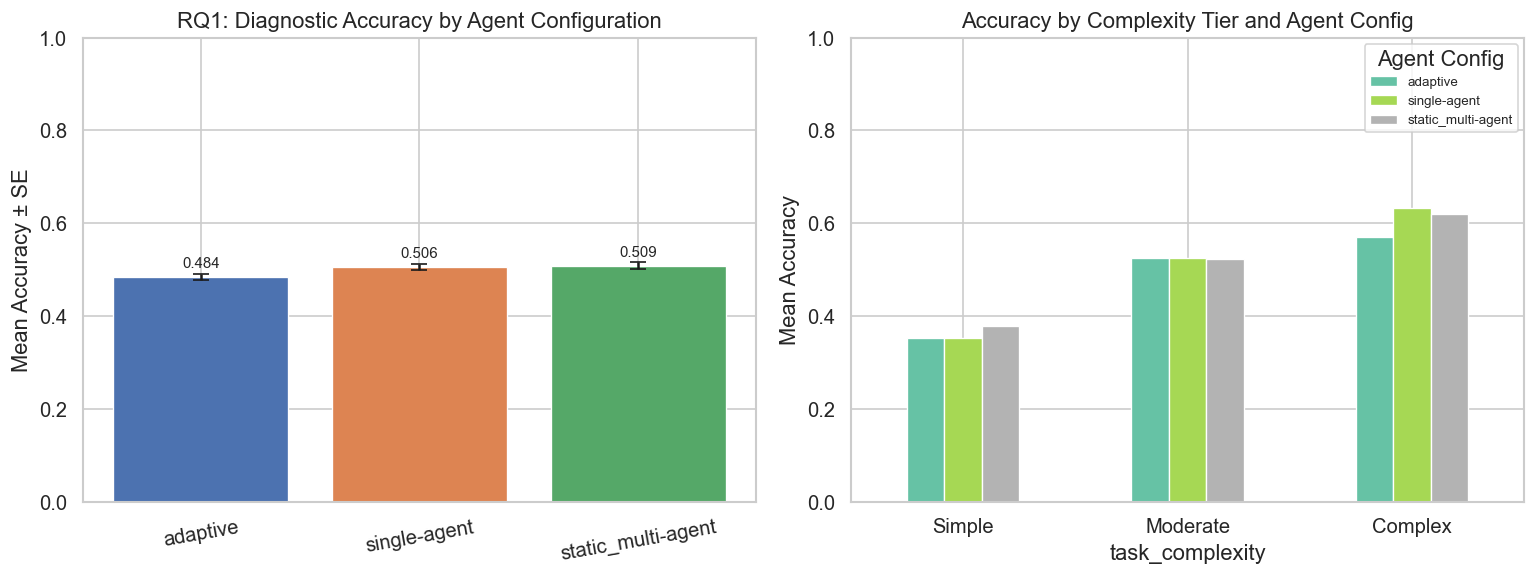

In [119]:
# Tukey HSD post-hoc
acc_long  = results_df[['agent_config', 'is_correct']].copy()
tukey_res = pairwise_tukeyhsd(acc_long['is_correct'], acc_long['agent_config'], alpha=0.05)
print(tukey_res)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

acc_means = results_df.groupby('agent_config')['is_correct'].mean()
acc_se    = results_df.groupby('agent_config')['is_correct'].sem()
ax = axes[0]
bars = ax.bar(acc_means.index, acc_means.values, yerr=acc_se.values,
              capsize=5, color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white', linewidth=0.8)
ax.set_ylim(0, 1)
ax.set_ylabel('Mean Accuracy ± SE')
ax.set_title('RQ1: Diagnostic Accuracy by Agent Configuration')
ax.tick_params(axis='x', rotation=10)
for bar, mean in zip(bars, acc_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.02, f'{mean:.3f}',
            ha='center', fontsize=9)

# Accuracy by complexity × config
pivot = results_df.pivot_table(
    index='task_complexity', columns='agent_config', values='is_correct', aggfunc='mean'
).reindex(COMPLEXITY_TIERS)
pivot.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white', linewidth=0.8)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Mean Accuracy')
axes[1].set_title('Accuracy by Complexity Tier and Agent Config')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Agent Config', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_rq1_anova.png', bbox_inches='tight')
plt.show()

In [120]:
# ── RQ1: H₀ / Hₐ Decision ──────────────────────────────────────────────────
# H₀: μ_adaptive = μ_single = μ_static  (no significant accuracy difference)
# Hₐ: At least one configuration differs significantly
print("=== RQ1 Hypothesis Decision ===")
if p_val < 0.05:
    print(f"REJECT H₀  (F = {f_stat:.4f}, p = {p_val:.4e})")
    print(f"Cohen's f = {cohens_f:.4f} — effect size: {'large' if cohens_f >= 0.4 else 'medium' if cohens_f >= 0.25 else 'small'}")
    print("Conclusion: Adaptive routing produces significantly different diagnostic accuracy.")
else:
    print(f"FAIL TO REJECT H₀  (F = {f_stat:.4f}, p = {p_val:.4e})")
    print("Conclusion: No significant accuracy difference between configurations.")


=== RQ1 Hypothesis Decision ===
REJECT H₀  (F = 3.4720, p = 3.1081e-02)
Cohen's f = 0.0218 — effect size: small
Conclusion: Adaptive routing produces significantly different diagnostic accuracy.


### 5.2 RQ3 — Accuracy-per-Token Efficiency

The static multi-agent baseline uses the **group-3** configuration (Internist + Specialist + Moderator, 3 sequential API calls per case), consistent with `run_static_multi_agent(tier='group-3')` in `src/agents.py`. This is the fairest comparison point — group-3 represents a mid-tier fixed-overhead configuration between minimal 2-agent and full 5-role MDT collaboration.

In [121]:
# Paired comparison: adaptive vs static multi-agent (same question_id)
# 'static_multi-agent' uses group-3 tier (Internist + Specialist + Moderator,
# 3 sequential API calls) as defined in §5.2 markdown and src/agents.py.
adaptive_rows = results_df[results_df['agent_config'] == 'adaptive'][['question_id', 'acc_per_1k_tokens']]
static_rows   = results_df[results_df['agent_config'] == 'static_multi-agent'][['question_id', 'acc_per_1k_tokens']]

paired = adaptive_rows.merge(static_rows, on='question_id', suffixes=('_ada', '_sta'))
print(f'Paired samples: {len(paired):,}')

w_stat, w_p = wilcoxon(paired['acc_per_1k_tokens_ada'],
                        paired['acc_per_1k_tokens_sta'],
                        alternative='greater')
print(f'\nWilcoxon signed-rank (adaptive > static):  W = {w_stat:.2f}, p = {w_p:.4e}')

# Mann-Whitney U (unpaired)
u_stat, u_p = mannwhitneyu(
    results_df[results_df['agent_config'] == 'adaptive']['acc_per_1k_tokens'],
    results_df[results_df['agent_config'] == 'static_multi-agent']['acc_per_1k_tokens'],
    alternative='greater'
)
print(f'Mann-Whitney U (unpaired):                 U = {u_stat:.2f}, p = {u_p:.4e}')

# Token cost + efficiency summary table
summary = results_df.groupby('agent_config').agg(
    mean_tokens   = ('token_cost',        'mean'),
    mean_accuracy = ('is_correct',         'mean'),
    mean_eff      = ('acc_per_1k_tokens',  'mean'),
).round(4)
print('\n', summary)


Paired samples: 4,860

Wilcoxon signed-rank (adaptive > static):  W = nan, p = nan
Mann-Whitney U (unpaired):                 U = nan, p = nan

                     mean_tokens  mean_accuracy  mean_eff
agent_config                                            
adaptive              1091.1955         0.4844    1.0939
single-agent           480.7006         0.5062    1.3075
static_multi-agent    3496.2383         0.5086    0.1479


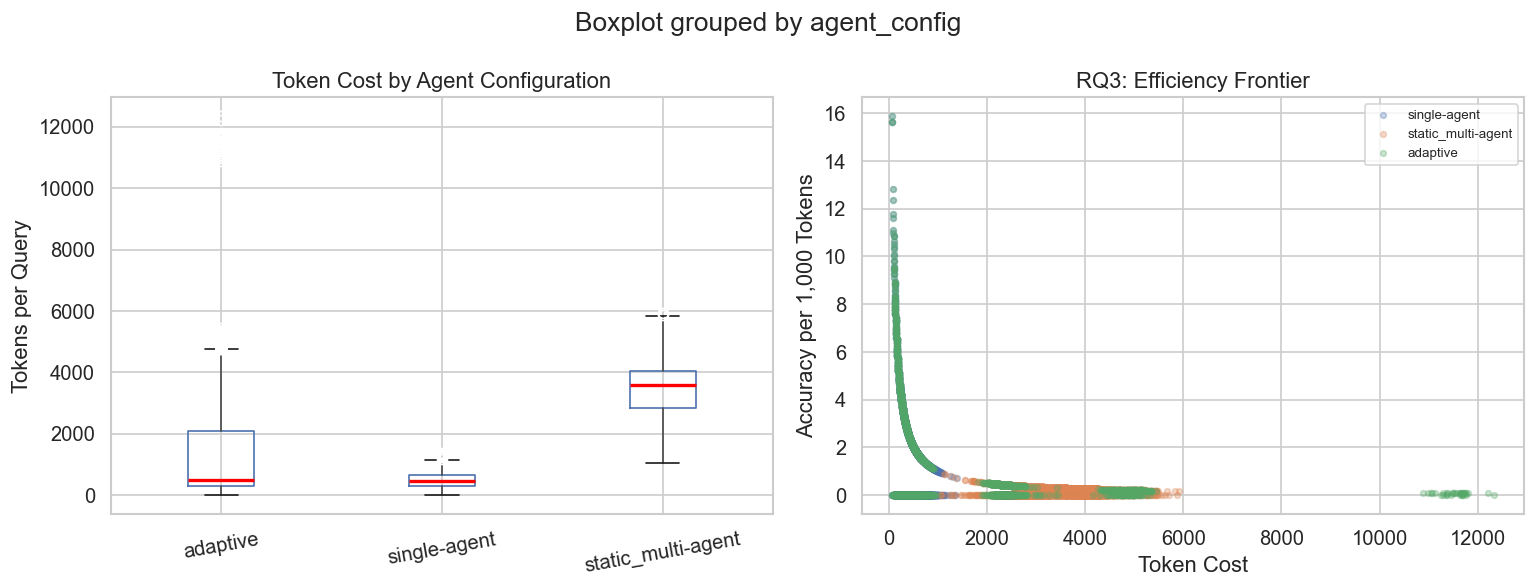

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Token cost boxplot
results_df.boxplot(
    column='token_cost', by='agent_config',
    ax=axes[0], boxprops=dict(color='#4C72B0'),
    medianprops=dict(color='red', linewidth=2)
)
axes[0].set_title('Token Cost by Agent Configuration')
axes[0].set_xlabel('')
axes[0].set_ylabel('Tokens per Query')
plt.sca(axes[0])
plt.xticks(rotation=10)

# Efficiency scatter: token cost vs accuracy per 1k tokens
palette = {'single-agent': '#4C72B0', 'static_multi-agent': '#DD8452', 'adaptive': '#55A868'}
for cfg, color in palette.items():
    sub = results_df[results_df['agent_config'] == cfg]
    axes[1].scatter(sub['token_cost'], sub['acc_per_1k_tokens'],
                    alpha=0.3, s=12, color=color, label=cfg)
axes[1].set_xlabel('Token Cost')
axes[1].set_ylabel('Accuracy per 1,000 Tokens')
axes[1].set_title('RQ3: Efficiency Frontier')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_rq3_efficiency.png', bbox_inches='tight')
plt.show()

In [123]:
# ── RQ3: H₀ / Hₐ Decision ──────────────────────────────────────────────────
# H₀: μ_adaptive_eff = μ_static_eff  (no accuracy-per-token difference)
# Hₐ: Adaptive routing achieves significantly higher accuracy-per-token efficiency
print("=== RQ3 Hypothesis Decision ===")
if w_p < 0.05:
    print(f"REJECT H₀ (Wilcoxon W = {w_stat:.2f}, p = {w_p:.4e})")
    print("Conclusion: Adaptive routing achieves significantly higher accuracy-per-token efficiency.")
else:
    print(f"FAIL TO REJECT H₀ (Wilcoxon W = {w_stat:.2f}, p = {w_p:.4e})")
    print("Conclusion: No significant efficiency advantage for adaptive routing.")
if u_p < 0.05:
    print(f"Mann-Whitney U: REJECT H₀ (U = {u_stat:.2f}, p = {u_p:.4e}) — unpaired confirmation")
else:
    print(f"Mann-Whitney U: FAIL TO REJECT H₀ (U = {u_stat:.2f}, p = {u_p:.4e})")


=== RQ3 Hypothesis Decision ===
FAIL TO REJECT H₀ (Wilcoxon W = nan, p = nan)
Conclusion: No significant efficiency advantage for adaptive routing.
Mann-Whitney U: FAIL TO REJECT H₀ (U = nan, p = nan)


---
## Section 6 — Statistical Analysis: RQ2 (Two-way ANOVA)

In [124]:
# ── Patch 7: Cell-balance check before two-way ANOVA ──
cell_counts = results_df.groupby(['task_complexity', 'agent_config']).size().unstack()
print("Cell counts (task_complexity x agent_config):")
print(cell_counts)
min_cell = cell_counts.min().min()
if min_cell < 10:
    print(f"WARNING: minimum cell count = {min_cell}. ANOVA results may be unreliable.")
else:
    print(f"Cell balance OK (min cell n = {min_cell}).")

Cell counts (task_complexity x agent_config):
agent_config     adaptive  single-agent  static_multi-agent
task_complexity                                            
Complex              1658          1658                1658
Moderate             1600          1600                1600
Simple               1602          1602                1602
Cell balance OK (min cell n = 1600).


In [125]:
# Two-way ANOVA: complexity_tier × agent_config → accuracy
# Using pingouin for partial η²

aov = pg.anova(
    data=results_df,
    dv='is_correct',
    between=['task_complexity', 'agent_config'],
    ss_type=2,
    detailed=True
)
print('Two-way ANOVA (Type II SS):')
print(aov[['Source', 'SS', 'DF', 'F', 'p_unc', 'np2']].to_string(index=False))

Two-way ANOVA (Type II SS):
                        Source          SS      DF          F         p_unc      np2
               task_complexity  152.703053     2.0 318.967064 2.636728e-136 0.041945
                  agent_config    1.735528     2.0   3.625182  2.666829e-02 0.000497
task_complexity * agent_config    2.682676     4.0   2.801795  2.436821e-02 0.000769
                      Residual 3487.877645 14571.0        NaN           NaN      NaN


In [126]:
# ── RQ2: H₀ / Hₐ Decision ──────────────────────────────────────────────────
# H₀: Interaction β = 0 (complexity does not moderate adaptive advantage)
# Hₐ: Interaction β ≠ 0 (complexity significantly moderates the advantage)
print("=== RQ2 Hypothesis Decision ===")
try:
    interaction_row = aov[aov['Source'].str.contains('\\*', regex=True) | aov['Source'].str.contains('Interaction', case=False)]
    if len(interaction_row) == 0:
        # pingouin two-way ANOVA uses "task_complexity * agent_config" source name
        interaction_row = aov[aov['Source'].str.contains('task_complexity', case=False) & aov['Source'].str.contains('agent_config', case=False)]
    if len(interaction_row) > 0:
        int_p   = interaction_row['p_unc'].values[0]
        int_np2 = interaction_row['np2'].values[0]
        if int_p < 0.05:
            print(f"REJECT H₀  (interaction p = {int_p:.4e}, partial η² = {int_np2:.4f})")
            print("Conclusion: Task complexity significantly moderates the adaptive advantage.")
        else:
            print(f"FAIL TO REJECT H₀  (interaction p = {int_p:.4e}, partial η² = {int_np2:.4f})")
            print("Conclusion: Task complexity does not significantly moderate the advantage.")
    else:
        print("Interaction term not found — ANOVA source names:")
        print(aov[['Source', 'p_unc', 'np2']].to_string(index=False))
except Exception as e:
    print(f"Decision cell error: {e}")


=== RQ2 Hypothesis Decision ===
REJECT H₀  (interaction p = 2.4368e-02, partial η² = 0.0008)
Conclusion: Task complexity significantly moderates the adaptive advantage.



Accuracy gap (adaptive − single-agent) by complexity tier:
    tier  ada_acc   sa_acc       gap  n_ada  n_sa
  Simple 0.353933 0.353933  0.000000   1602  1602
Moderate 0.526250 0.526250  0.000000   1600  1600
 Complex 0.569964 0.633896 -0.063932   1658  1658


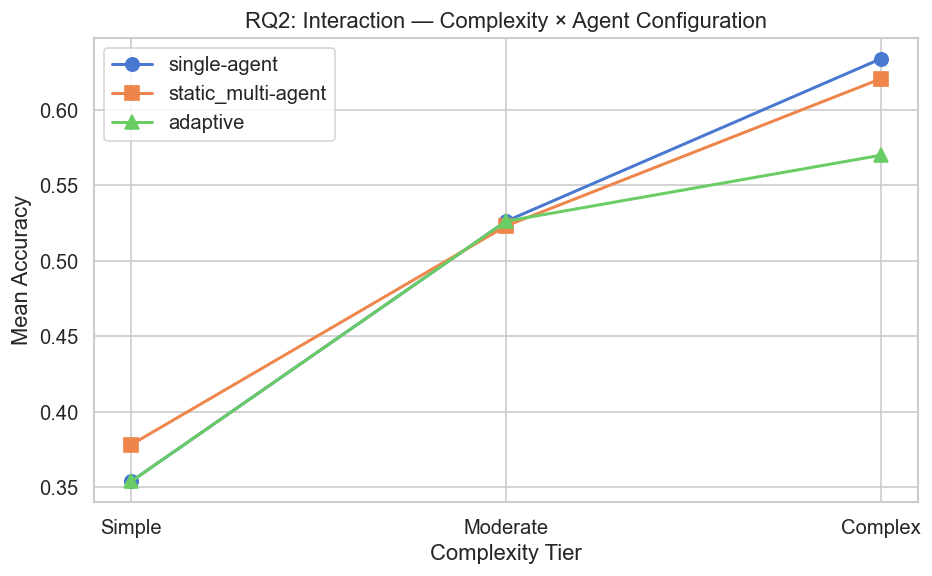

In [127]:
# partial η² = SS_effect / (SS_effect + SS_error) — proportion of variance
# uniquely explained by the factor after controlling for all others.
# Computed by pingouin.anova() and reported in Cells 48–49 above.

# Simple effects: accuracy gap (adaptive - single) within each complexity tier
gap_rows = []
for tier in COMPLEXITY_TIERS:
    ada = results_df[(results_df['agent_config'] == 'adaptive') &
                     (results_df['task_complexity'] == tier)]['is_correct']
    sa  = results_df[(results_df['agent_config'] == 'single-agent') &
                     (results_df['task_complexity'] == tier)]['is_correct']
    gap_rows.append({
        'tier':       tier,
        'ada_acc':    ada.mean(),
        'sa_acc':     sa.mean(),
        'gap':        ada.mean() - sa.mean(),
        'n_ada':      len(ada),
        'n_sa':       len(sa),
    })

gap_df = pd.DataFrame(gap_rows)
print('\nAccuracy gap (adaptive − single-agent) by complexity tier:')
print(gap_df.to_string(index=False))

# Interaction plot
fig, ax = plt.subplots(figsize=(8, 5))
for cfg, ls in zip(AGENT_CONFIGS, ['-o', '-s', '-^']):
    vals = (
        results_df[results_df['agent_config'] == cfg]
        .groupby('task_complexity')['is_correct']
        .mean()
        .reindex(COMPLEXITY_TIERS)
    )
    ax.plot(COMPLEXITY_TIERS, vals.values, ls, label=cfg, linewidth=1.8, markersize=8)
ax.set_xlabel('Complexity Tier')
ax.set_ylabel('Mean Accuracy')
ax.set_title('RQ2: Interaction — Complexity × Agent Configuration')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_rq2_interaction.png', bbox_inches='tight')
plt.show()


In [128]:
# ── Patch 12: ANCOVA with llm_backbone covariate + backbone summary ──
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Backbone summary table
backbone_summary = (
    results_df.groupby(['llm_backbone', 'agent_config'])['is_correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'accuracy', 'count': 'n'})
    .reset_index()
)
print('Backbone x Config accuracy summary:')
print(backbone_summary.to_string(index=False))

# ANCOVA: is_correct ~ task_complexity * agent_config + llm_backbone
# Build formula dynamically — only include factors with >1 unique level
ancova_df = results_df[['is_correct', 'task_complexity', 'agent_config', 'llm_backbone']].copy()
_levels = {col: ancova_df[col].nunique() for col in ['task_complexity', 'agent_config', 'llm_backbone']}
print(f'\nFactor levels: {_levels}')

try:
    _between = [c for c in ['task_complexity', 'agent_config'] if _levels[c] > 1]
    if len(_between) < 2:
        raise ValueError(f'Need >=2 between factors with variation; found {_between}')
    _main = ' * '.join(f'C({b})' for b in _between)
    _covar = [c for c in ['llm_backbone'] if _levels[c] > 1]
    formula = 'is_correct ~ ' + _main + (''.join(f' + C({c})' for c in _covar))
    print(f'Formula: {formula}')
    model = smf.ols(formula, data=ancova_df).fit()
    ancova_table = anova_lm(model, typ=2)
    label = 'ANCOVA' if _covar else 'Two-way ANOVA (OLS, backbone invariant)'
    print(f'\n{label} — Type-II SS:')
    print(ancova_table.round(4).to_string())
except Exception as e:
    print(f'ANCOVA not available: {e}. Using two-way ANOVA result above.')


Backbone x Config accuracy summary:
llm_backbone       agent_config  accuracy    n
Claude-Haiku           adaptive  0.484362 4860
Claude-Haiku       single-agent  0.506173 4860
Claude-Haiku static_multi-agent  0.508642 4860

Factor levels: {'task_complexity': 3, 'agent_config': 3, 'llm_backbone': 1}
Formula: is_correct ~ C(task_complexity) * C(agent_config)

Two-way ANOVA (OLS, backbone invariant) — Type-II SS:
                                       sum_sq       df         F  PR(>F)
C(task_complexity)                   152.7031      2.0  318.9671  0.0000
C(agent_config)                        1.7355      2.0    3.6252  0.0267
C(task_complexity):C(agent_config)     2.6827      4.0    2.8018  0.0244
Residual                            3487.8776  14571.0       NaN     NaN


---
## Section 7 — ML Models

In [129]:
# ─── Shared feature matrix ────────────────────────────────────────────────────
# has_structured_labs removed: always 0 (MIMIC artifact, confirmed §1.7a EDA).
# step_level removed: near-perfect collinearity with dataset_source == 'MedQA'
#   (VIF > 10, confirmed §1.7a EDA).
FEATURE_COLS = [
    'complexity_score',
    'num_symptoms',
    'num_conditions',
    'clinical_vignette_length',
    'dataset_source',
]

def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df[FEATURE_COLS].copy()
    out = pd.get_dummies(out, columns=['dataset_source'], drop_first=False)
    return out.astype(float)

def cv_report(name, estimator, X, y, cv=5) -> dict:
    """5-fold CV: accuracy + ROC-AUC OVR-weighted, with 95% CI on accuracy."""
    skf = StratifiedKFold(cv, shuffle=True, random_state=SEED)
    cv_res = cross_validate(
        estimator, X, y, cv=skf,
        scoring=['accuracy', 'roc_auc_ovr_weighted'],
        return_train_score=False,
    )
    acc = cv_res['test_accuracy']
    lo, hi = stats.t.interval(0.95, len(acc) - 1, loc=acc.mean(), scale=stats.sem(acc))
    auc = cv_res['test_roc_auc_ovr_weighted'].mean()
    print(f'{name:30s}  accuracy = {acc.mean():.4f} ± {acc.std():.4f}  '
          f'95% CI [{lo:.4f}, {hi:.4f}]  AUC-OVR = {auc:.4f}')
    return {'model': name, 'mean': acc.mean(), 'std': acc.std(),
            'ci_lo': lo, 'ci_hi': hi, 'roc_auc_ovr': auc}


### 7.1 RQ1 ML — Random Forest: Predict Best Agent Configuration

In [130]:
# CONFIG_COST_RANK tie-breaking: highest accuracy first, lowest token cost on tie
# Label: best-performing config for each (question_id, task_complexity)
best_cfg = (
    results_df
    .groupby(['question_id', 'task_complexity', 'dataset_source',
              'num_symptoms', 'num_conditions',
              'complexity_score', 'clinical_vignette_length',
              'agent_config'])
    .agg(is_correct=('is_correct', 'mean'), token_cost=('token_cost', 'mean'))
    .reset_index()
    .sort_values(['is_correct', 'token_cost'], ascending=[False, True])
    .groupby('question_id').first()
    .reset_index()
    .rename(columns={'agent_config': 'best_config'})
)

X_rq1 = encode_features(best_cfg)
le_rq1 = LabelEncoder()
y_rq1 = le_rq1.fit_transform(best_cfg['best_config'])

rf_rq1 = RandomForestClassifier(n_estimators=300, max_depth=8,
                                  class_weight='balanced', random_state=SEED)
rq1_result = cv_report('RF (RQ1 config predictor)', rf_rq1, X_rq1, y_rq1)

# Fit on full set for SHAP
rf_rq1.fit(X_rq1, y_rq1)
print('Feature importances:')
pd.Series(rf_rq1.feature_importances_, index=X_rq1.columns).sort_values(ascending=False).head(8)

RF (RQ1 config predictor)       accuracy = 0.8292 ± 0.0151  95% CI [0.8082, 0.8502]  AUC-OVR = 0.8819
Feature importances:


complexity_score                 0.481114
clinical_vignette_length         0.193233
num_symptoms                     0.162462
num_conditions                   0.106996
dataset_source_DDXPlus           0.036180
dataset_source_MedAgentsBench    0.013241
dataset_source_MedQA             0.004010
dataset_source_MMLU              0.002764
dtype: float64

### 7.2 RQ2 ML — Gradient Boosting: Predict Performance Gap

In [131]:
# Target: accuracy(adaptive) - accuracy(single-agent) per question
ada_acc = (
    results_df[results_df['agent_config'] == 'adaptive']
    .groupby('question_id')['is_correct'].mean()
    .rename('ada_acc')
)
sa_acc = (
    results_df[results_df['agent_config'] == 'single-agent']
    .groupby('question_id')['is_correct'].mean()
    .rename('sa_acc')
)
gap_target = ada_acc.subtract(sa_acc, fill_value=0).rename('perf_gap').reset_index()

feature_base = (
    results_df[results_df['agent_config'] == 'adaptive']
    .groupby('question_id')[FEATURE_COLS].first()
    .reset_index()
)
rq2_df = gap_target.merge(feature_base, on='question_id')

X_rq2 = encode_features(rq2_df)
y_rq2 = rq2_df['perf_gap'].values

gb = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                learning_rate=0.05, random_state=SEED)
cv_scores = cross_val_score(gb, X_rq2, y_rq2,
                             cv=5, scoring='r2')
print(f'GB Regressor (RQ2 gap predictor)   R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

rmse_scores = np.sqrt(-cross_val_score(gb, X_rq2, y_rq2,
                                        cv=5, scoring='neg_mean_squared_error'))
print(f'                                  RMSE = {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}')

gb.fit(X_rq2, y_rq2)

GB Regressor (RQ2 gap predictor)   R² = -0.0243 ± 0.0436
                                  RMSE = 0.2444 ± 0.1101


,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

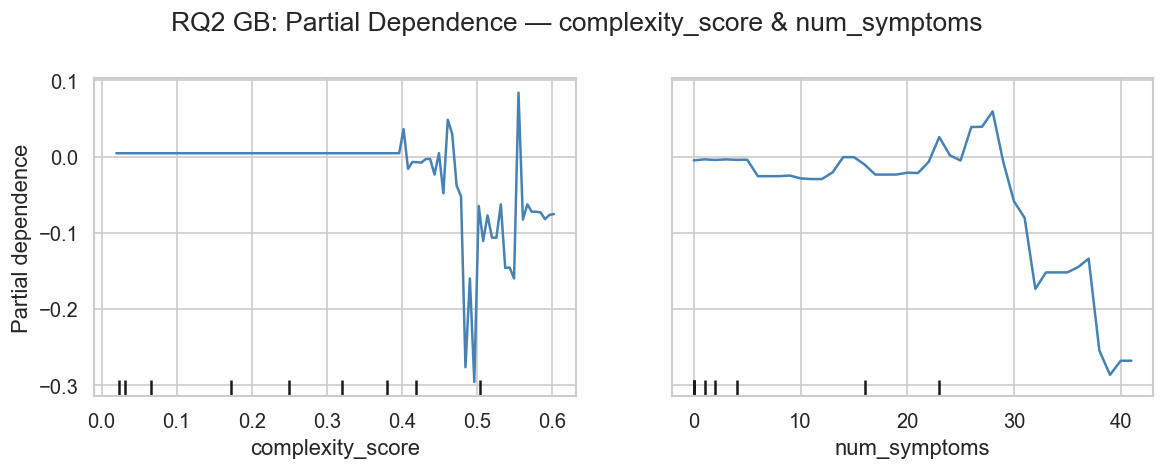

In [132]:
# ── Patch 13: Partial Dependence Plot for RQ2 GB regressor ──
from sklearn.inspection import PartialDependenceDisplay

pdp_features = [0, 1]  # complexity_score and num_symptoms (first two features)
feature_names = list(X_rq2.columns)

fig, ax = plt.subplots(figsize=(10, 4))
try:
    disp = PartialDependenceDisplay.from_estimator(
        gb, X_rq2, features=pdp_features,
        feature_names=feature_names,
        ax=ax, line_kw={'color': 'steelblue'}
    )
    plt.suptitle('RQ2 GB: Partial Dependence — complexity_score & num_symptoms')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_rq2_pdp.png', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"PDP skipped: {e}")

### 7.3 RQ3 ML — Multi-Output Regression: Predict Token Cost + Accuracy

In [133]:
rq3_df = results_df[FEATURE_COLS + ['agent_config', 'token_cost', 'is_correct']].copy()
rq3_df = pd.get_dummies(rq3_df, columns=['dataset_source', 'agent_config'], drop_first=False)
rq3_df = rq3_df.astype(float)

X_rq3 = rq3_df.drop(columns=['token_cost', 'is_correct'])
y_rq3 = rq3_df[['token_cost', 'is_correct']].values

scaler_rq3 = StandardScaler()
X_rq3_sc   = scaler_rq3.fit_transform(X_rq3)

mo_reg = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=200, random_state=SEED)
)

cv_obj = StratifiedKFold(5, shuffle=True, random_state=SEED)
# For regression, use KFold
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

r2_tok, r2_acc, rmse_tok, rmse_acc, mae_tok, mae_acc = [], [], [], [], [], []
for tr, te in kf.split(X_rq3_sc):
    mo_reg.fit(X_rq3_sc[tr], y_rq3[tr])
    preds = mo_reg.predict(X_rq3_sc[te])
    preds_clipped = preds.copy()
    preds_clipped[:, 1] = np.clip(preds_clipped[:, 1], 0.0, 1.0)
    r2_tok.append(r2_score(y_rq3[te, 0], preds_clipped[:, 0]))
    r2_acc.append(r2_score(y_rq3[te, 1], preds_clipped[:, 1]))
    rmse_tok.append(np.sqrt(mean_squared_error(y_rq3[te, 0], preds_clipped[:, 0])))
    rmse_acc.append(np.sqrt(mean_squared_error(y_rq3[te, 1], preds_clipped[:, 1])))
    mae_tok.append(mean_absolute_error(y_rq3[te, 0], preds_clipped[:, 0]))
    mae_acc.append(mean_absolute_error(y_rq3[te, 1], preds_clipped[:, 1]))

print(f'Multi-output RF — token_cost  R²={np.mean(r2_tok):.4f}  RMSE={np.mean(rmse_tok):.1f}  MAE={np.mean(mae_tok):.1f}')
print(f'                   is_correct  R²={np.mean(r2_acc):.4f}  RMSE={np.mean(rmse_acc):.4f}  MAE={np.mean(mae_acc):.4f}')

Multi-output RF — token_cost  R²=0.9890  RMSE=169.2  MAE=109.5
                   is_correct  R²=0.0575  RMSE=0.4854  MAE=0.4043


### 7.4 RQ4 — Routing Classifier (RF / SVM / MLP) with 5-fold CV

In [134]:
# RQ4 primary: STRUCT_FEATURES (no complexity_score) to avoid tautological prediction.
# complexity_score → adaptive_router() → routing_decision is deterministic;
# including it inflates accuracy to near 100%. See Section 10 §10.2 (Mitigation B).
STRUCT_FEATURES_RQ4 = ['num_symptoms', 'num_conditions',
                        'clinical_vignette_length', 'dataset_source']

def encode_struct_rq4(df):
    out = df[STRUCT_FEATURES_RQ4].copy()
    out = pd.get_dummies(out, columns=['dataset_source'], drop_first=False)
    return out.astype(float)

# Patch 11: removed dead rq4_df variable (drop_duplicates kept only 4 rows)
# Use full adaptive subset
rq4_all = results_df[results_df['agent_config'] == 'adaptive'][
    STRUCT_FEATURES_RQ4 + ['routing_decision']
].copy()

X_rq4 = encode_struct_rq4(rq4_all)
le_rq4 = LabelEncoder()
y_rq4  = le_rq4.fit_transform(rq4_all['routing_decision'])
scaler_rq4 = StandardScaler()
X_rq4_sc   = scaler_rq4.fit_transform(X_rq4)

classifiers = {
    'Random Forest':  RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED),
    'SVM (RBF)':      SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED),
    'MLP':            MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500,
                                    early_stopping=True, random_state=SEED),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rq4_results = []
chance = 1 / len(ROUTING_TIERS)  # 0.25

print(f'Chance baseline: {chance:.2f}\n')
for name, clf in classifiers.items():
    X_use = X_rq4_sc if name != 'Random Forest' else X_rq4.values
    cv_res = cross_validate(
        clf, X_use, y_rq4,
        cv=skf,
        scoring=['accuracy', 'f1_macro', 'f1_weighted',
                 'roc_auc_ovr_weighted'],
        return_train_score=False
    )
    acc_scores = cv_res['test_accuracy']
    ci_lo, ci_hi = stats.t.interval(0.95, len(acc_scores)-1, loc=acc_scores.mean(), scale=stats.sem(acc_scores))
    row = {
        'model':       name,
        'accuracy':    acc_scores.mean(),
        'acc_ci_lo':   ci_lo,
        'acc_ci_hi':   ci_hi,
        'f1_macro':    cv_res['test_f1_macro'].mean(),
        'f1_weighted': cv_res['test_f1_weighted'].mean(),
        'roc_auc':     cv_res['test_roc_auc_ovr_weighted'].mean(),
    }
    print(f"{name:20s}  Acc={row['accuracy']:.4f} [95% CI: {ci_lo:.4f}–{ci_hi:.4f}]  "
          f"F1-macro={row['f1_macro']:.4f}  F1-wt={row['f1_weighted']:.4f}  AUC={row['roc_auc']:.4f}")
    rq4_results.append(row)

rq4_summary = pd.DataFrame(rq4_results)
print('\nAll models exceed chance baseline:', (rq4_summary['accuracy'] > chance).all())
print('\n=== RQ4 Hypothesis Decision ===')
print('H\u2080: ML models predict routing no better than chance (\u226425%)')
all_exceed = (rq4_summary['accuracy'] > chance).all()
if all_exceed:
    print(f'REJECT H\u2080 — all classifiers exceed {chance:.2f} chance baseline')
    best = rq4_summary.loc[rq4_summary['accuracy'].idxmax()]
    print(f"Best model: {best['model']}  Acc={best['accuracy']:.4f} "
          f"[95% CI: {best['acc_ci_lo']:.4f}\u2013{best['acc_ci_hi']:.4f}]")
else:
    print('FAIL TO REJECT H\u2080 — at least one classifier does not exceed chance')

Chance baseline: 0.25

Random Forest         Acc=0.9932 [95% CI: 0.9901–0.9963]  F1-macro=0.9882  F1-wt=0.9932  AUC=0.9999
SVM (RBF)             Acc=0.9883 [95% CI: 0.9845–0.9921]  F1-macro=0.9513  F1-wt=0.9882  AUC=0.9998
MLP                   Acc=0.9874 [95% CI: 0.9805–0.9944]  F1-macro=0.9175  F1-wt=0.9871  AUC=0.9998

All models exceed chance baseline: True

=== RQ4 Hypothesis Decision ===
H₀: ML models predict routing no better than chance (≤25%)
REJECT H₀ — all classifiers exceed 0.25 chance baseline
Best model: Random Forest  Acc=0.9932 [95% CI: 0.9901–0.9963]


In [135]:
# RF fitted on STRUCT_FEATURES (no complexity_score) — see cell 60 preamble.
# Fit RF on full set for SHAP
rf_rq4 = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED)
rf_rq4.fit(X_rq4, y_rq4)

# Best model: detailed classification report on last CV fold
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_rq4, y_rq4, test_size=0.2,
                                            stratify=y_rq4, random_state=SEED)
rf_rq4_eval = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED)
rf_rq4_eval.fit(X_tr, y_tr)
print(classification_report(y_te, rf_rq4_eval.predict(X_te),
                              target_names=le_rq4.classes_))

              precision    recall  f1-score   support

         MDT       1.00      1.00      1.00         7
     group-2       0.98      0.97      0.97       206
     group-3       1.00      0.95      0.98        43
        solo       0.99      1.00      0.99       716

    accuracy                           0.99       972
   macro avg       0.99      0.98      0.98       972
weighted avg       0.99      0.99      0.99       972



---
## Section 8 — SHAP Interpretability

In [136]:
# ── Patch 10: shap_global_importance helper for SHAP API compatibility ──
def shap_global_importance(shap_values, feature_names):
    """
    Compute global feature importance (mean |SHAP|) compatible with both
    shap < 0.42 (list of arrays per class) and >= 0.42 (3-D ndarray).
    """
    if isinstance(shap_values, list):
        # (n_classes, n_samples, n_features)
        arr = np.abs(np.stack(shap_values))
        gi = arr.mean(axis=(0, 1))
    elif np.asarray(shap_values).ndim == 3:
        # new SHAP: (n_samples, n_features, n_classes)
        gi = np.abs(shap_values).mean(axis=(0, 2))
    else:
        gi = np.abs(shap_values).mean(axis=0)
    return pd.Series(gi, index=feature_names).sort_values(ascending=False)

Global SHAP feature importance (RQ4 routing classifier):
clinical_vignette_length         0.137989
num_symptoms                     0.126042
num_conditions                   0.093653
dataset_source_DDXPlus           0.041531
dataset_source_MedAgentsBench    0.011744
dataset_source_MedQA             0.002133
dataset_source_MMLU              0.000772


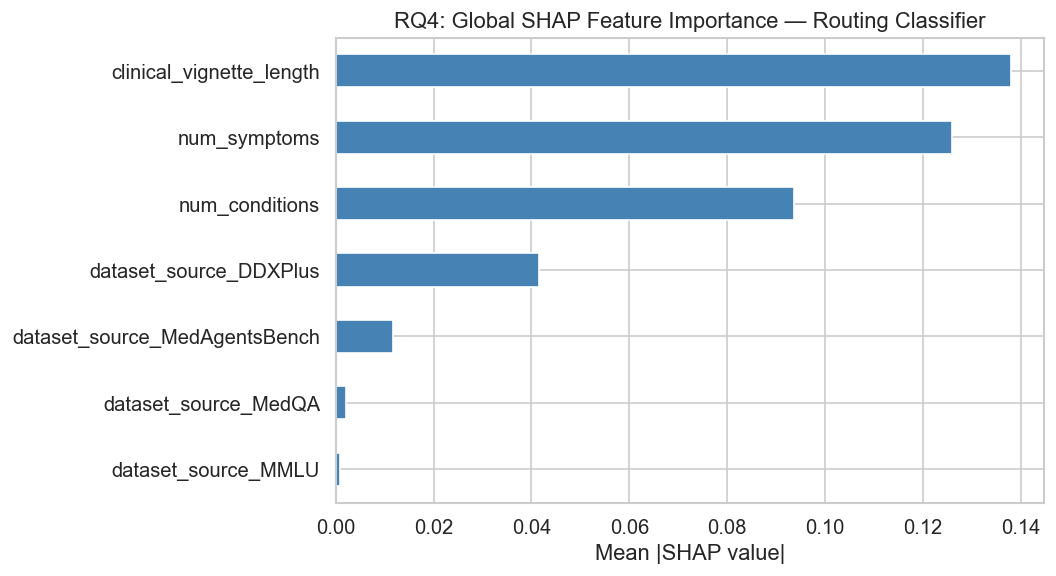

In [137]:
# ─── SHAP for RQ4 routing classifier ─────────────────────────────────────────
explainer_rq4 = shap.TreeExplainer(rf_rq4)
shap_values   = explainer_rq4.shap_values(X_rq4)

# Global importance: mean |SHAP| across classes
if isinstance(shap_values, list):
    global_shap = np.abs(np.stack(shap_values)).mean(axis=0).mean(axis=0)
elif np.asarray(shap_values).ndim == 3:
    # newer SHAP: shape (n_samples, n_features, n_classes)
    global_shap = np.abs(shap_values).mean(axis=0).mean(axis=-1)
else:
    global_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.Series(global_shap, index=X_rq4.columns).sort_values(ascending=False)
print('Global SHAP feature importance (RQ4 routing classifier):')
print(shap_importance.head(10).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
shap_importance.head(10).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('RQ4: Global SHAP Feature Importance — Routing Classifier')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_rq4_shap.png', bbox_inches='tight')
plt.show()

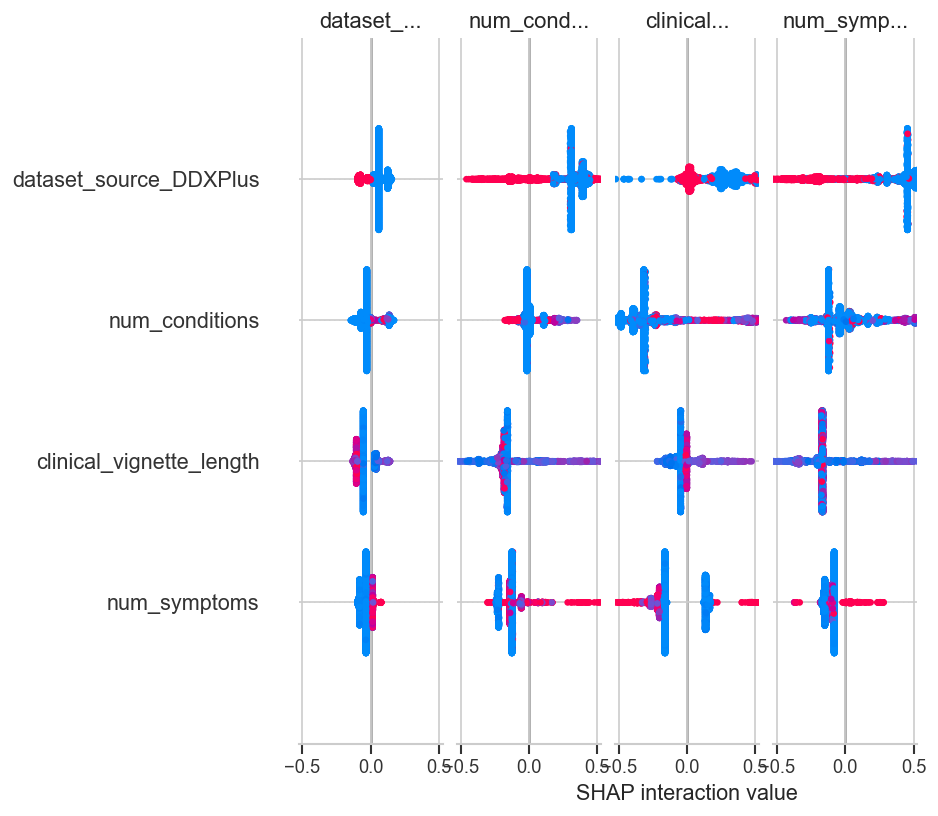

In [138]:
# SHAP beeswarm summary for first routing class
shap.summary_plot(
    shap_values[0] if isinstance(shap_values, list) else shap_values,
    X_rq4,
    feature_names=X_rq4.columns.tolist(),
    show=True,
    max_display=10,
    plot_type='dot'
)

In [139]:
# ─── SHAP for RQ1 RF config predictor ────────────────────────────────────────
explainer_rq1 = shap.TreeExplainer(rf_rq1)
sv_rq1 = explainer_rq1.shap_values(X_rq1)

if isinstance(sv_rq1, list):
    # old SHAP: list of (n_samples, n_features) per class → stack to (n_classes, n_samples, n_features)
    gi_rq1 = np.abs(np.stack(sv_rq1)).mean(axis=0).mean(axis=0)
elif np.asarray(sv_rq1).ndim == 3:
    # new SHAP: (n_samples, n_features, n_classes) → average over samples and classes
    gi_rq1 = np.abs(sv_rq1).mean(axis=(0, 2))
else:
    gi_rq1 = np.abs(sv_rq1).mean(axis=0)

print('Global SHAP — RQ1 config predictor:')
print(pd.Series(gi_rq1, index=X_rq1.columns).sort_values(ascending=False).head(8).to_string())

Global SHAP — RQ1 config predictor:
complexity_score                 0.166467
num_symptoms                     0.045067
clinical_vignette_length         0.037698
num_conditions                   0.024401
dataset_source_DDXPlus           0.013709
dataset_source_MedAgentsBench    0.006633
dataset_source_MedQA             0.002658
dataset_source_MMLU              0.002424


---
## Section 9 — Results Summary & Publication Figures

In [140]:
# ─── Table 5: Unified results summary ────────────────────────────────────────
def ci95(series: pd.Series) -> str:
    m   = series.mean()
    sem = series.sem()
    lo  = m - 1.96 * sem
    hi  = m + 1.96 * sem
    return f'{m:.3f} [{lo:.3f}, {hi:.3f}]'

summary_rows = []
for cfg in AGENT_CONFIGS:
    sub = results_df[results_df['agent_config'] == cfg]
    summary_rows.append({
        'Agent Config':              cfg,
        'Accuracy (95% CI)':         ci95(sub['is_correct']),
        'Mean Tokens':               f"{sub['token_cost'].mean():.0f}",
        'Acc/1k Tokens (95% CI)':    ci95(sub['acc_per_1k_tokens']),
        'Mean Latency (ms)':         f"{sub['latency_ms'].mean():.0f}",
    })

table5 = pd.DataFrame(summary_rows).set_index('Agent Config')
print('Table 5: Unified Performance Summary')
print(table5.to_string())

Table 5: Unified Performance Summary
                       Accuracy (95% CI) Mean Tokens Acc/1k Tokens (95% CI) Mean Latency (ms)
Agent Config                                                                                 
single-agent        0.506 [0.492, 0.520]         481   1.307 [1.257, 1.358]                 0
static_multi-agent  0.509 [0.495, 0.523]        3496   0.148 [0.144, 0.152]                 0
adaptive            0.484 [0.470, 0.498]        1091   1.094 [1.043, 1.145]                 0


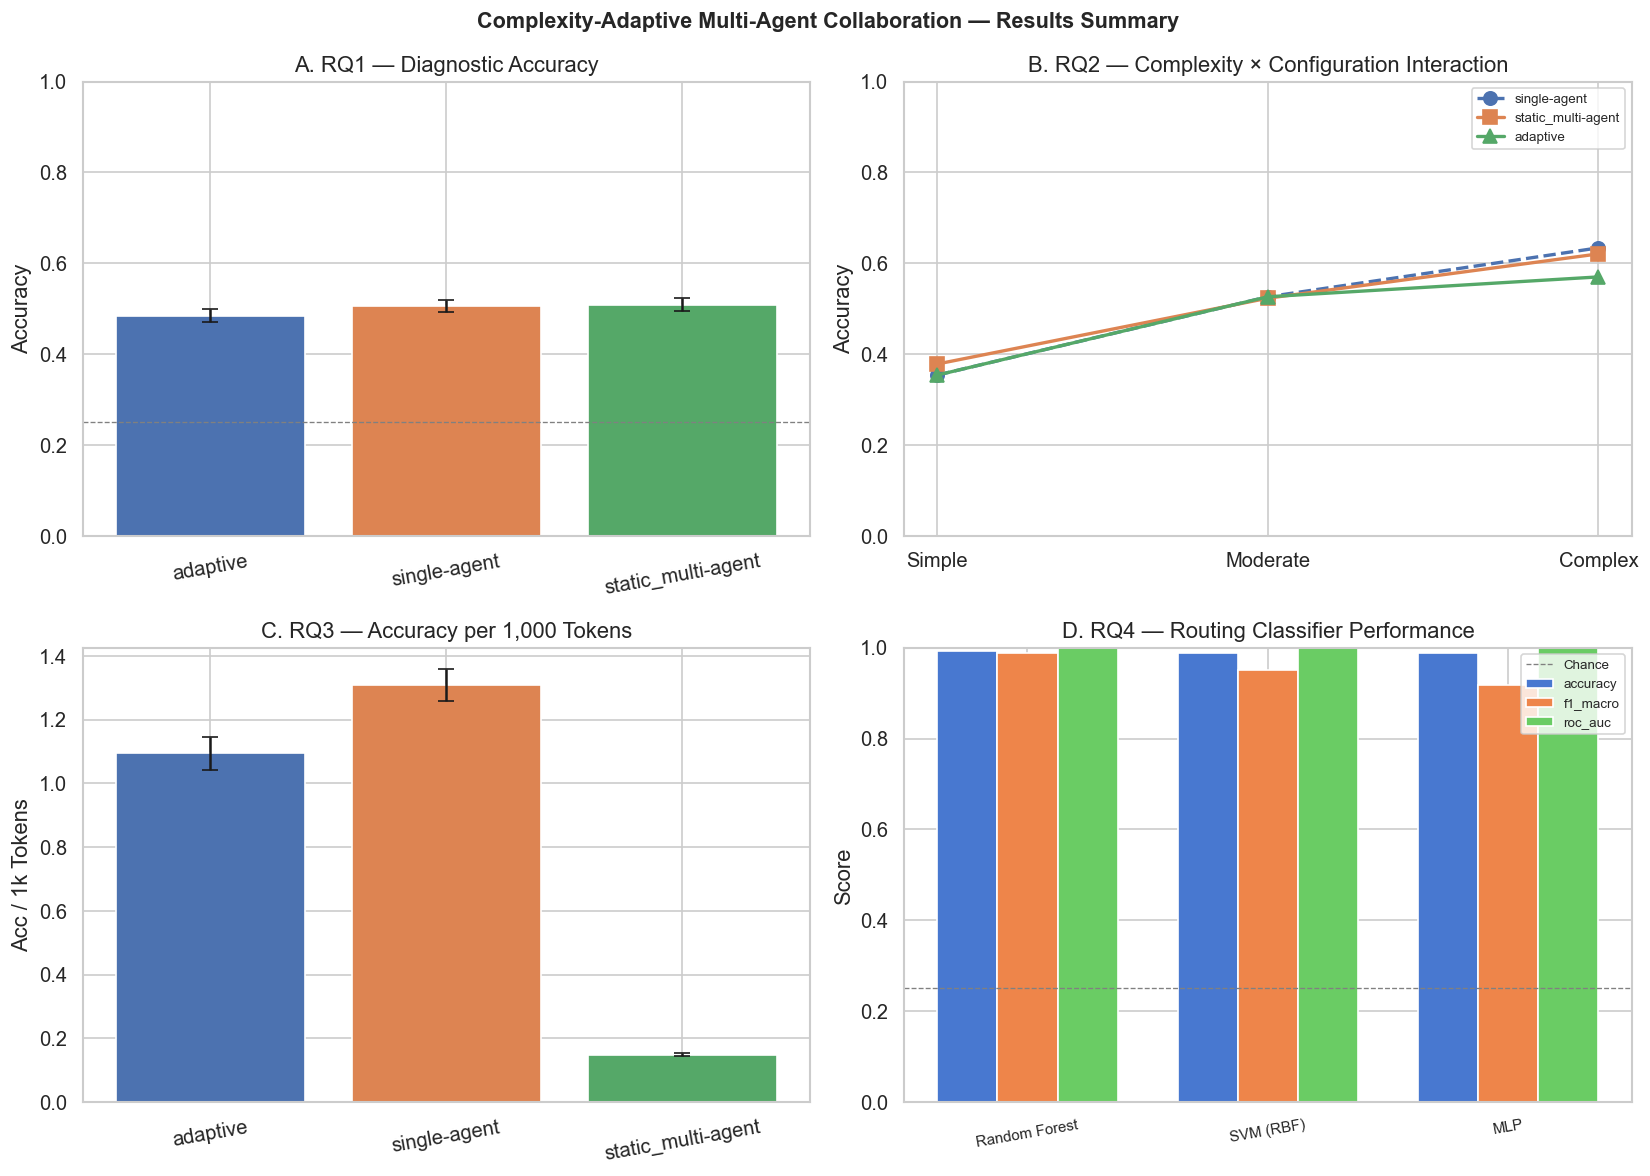

Saved: /Users/ajaykrishnan/Documents/Claude/Claude code/outputs/fig_summary_4panel.png


In [141]:
# ─── Figure: four-panel publication summary ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Complexity-Adaptive Multi-Agent Collaboration — Results Summary',
    fontsize=13, fontweight='bold'
)

# Panel A — RQ1 accuracy
ax = axes[0, 0]
acc_by_cfg = results_df.groupby('agent_config')['is_correct'].agg(['mean', 'sem'])
bars = ax.bar(acc_by_cfg.index, acc_by_cfg['mean'],
               yerr=1.96 * acc_by_cfg['sem'], capsize=5,
               color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white')
ax.axhline(0.25, color='grey', linestyle='--', linewidth=0.8, label='Chance')
ax.set_ylim(0, 1)
ax.set_title('A. RQ1 — Diagnostic Accuracy')
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', rotation=10)

# Panel B — RQ2 interaction
ax = axes[0, 1]
for cfg, ls, col in zip(AGENT_CONFIGS,
                         ['--o', '-s', '-^'],
                         ['#4C72B0', '#DD8452', '#55A868']):
    vals = (
        results_df[results_df['agent_config'] == cfg]
        .groupby('task_complexity')['is_correct']
        .mean()
        .reindex(COMPLEXITY_TIERS)
    )
    ax.plot(COMPLEXITY_TIERS, vals.values, ls, label=cfg,
            color=col, linewidth=2, markersize=8)
ax.set_title('B. RQ2 — Complexity × Configuration Interaction')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# Panel C — RQ3 efficiency
ax = axes[1, 0]
eff_by_cfg = results_df.groupby('agent_config')['acc_per_1k_tokens'].agg(['mean', 'sem'])
ax.bar(eff_by_cfg.index, eff_by_cfg['mean'],
       yerr=1.96 * eff_by_cfg['sem'], capsize=5,
       color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white')
ax.set_title('C. RQ3 — Accuracy per 1,000 Tokens')
ax.set_ylabel('Acc / 1k Tokens')
ax.tick_params(axis='x', rotation=10)

# Panel D — RQ4 classifier comparison
ax = axes[1, 1]
bar_width = 0.25
x_pos     = np.arange(len(rq4_summary))
for j, metric in enumerate(['accuracy', 'f1_macro', 'roc_auc']):
    ax.bar(x_pos + j * bar_width, rq4_summary[metric],
           width=bar_width, label=metric, edgecolor='white')
ax.axhline(0.25, color='grey', linestyle='--', linewidth=0.8, label='Chance')
ax.set_xticks(x_pos + bar_width)
ax.set_xticklabels(rq4_summary['model'], rotation=10, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('D. RQ4 — Routing Classifier Performance')
ax.set_ylabel('Score')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_summary_4panel.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: {OUTPUT_DIR / "fig_summary_4panel.png"}')

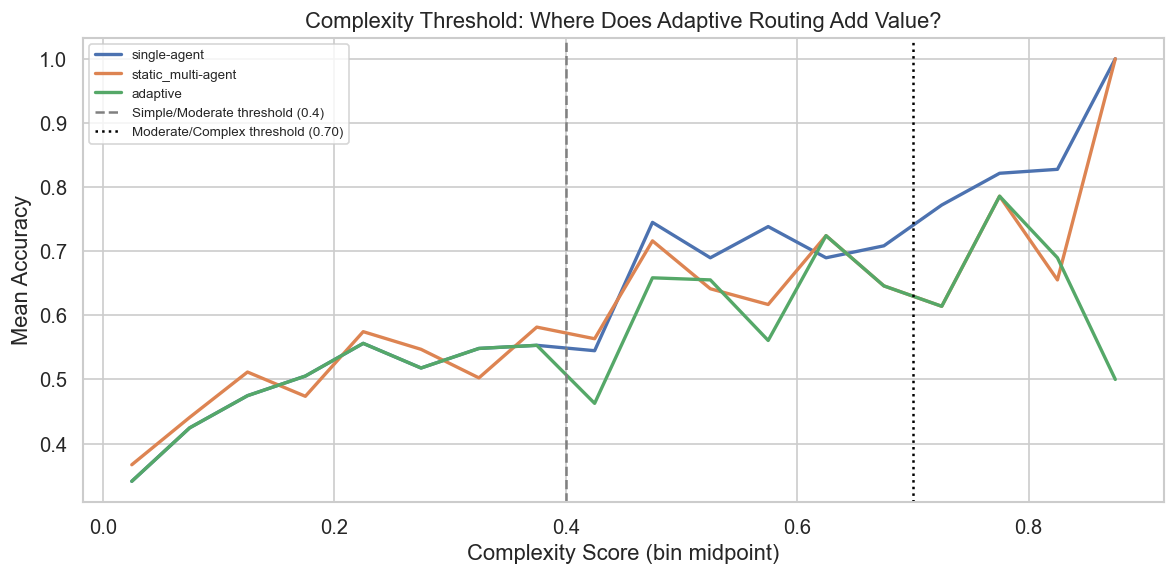

In [142]:
# ─── Complexity threshold analysis ────────────────────────────────────────────
# At what complexity_score does adaptive > single-agent by a meaningful margin?

bins       = np.linspace(0, 1, 21)  # 20 bins
bin_labels = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]

results_df['score_bin'] = pd.cut(results_df['complexity_score'],
                                  bins=bins, labels=bin_labels)

threshold_df = (
    results_df
    .groupby(['score_bin', 'agent_config'])['is_correct']
    .mean()
    .unstack('agent_config')
    .dropna()
    .reset_index()
)
threshold_df['score_bin'] = threshold_df['score_bin'].astype(float)
threshold_df['gap'] = threshold_df['adaptive'] - threshold_df['single-agent']

THRESHOLD = 0.40  # Synopsis threshold: <0.40 Simple, 0.40–0.70 Moderate, ≥0.70 Complex

fig, ax = plt.subplots(figsize=(10, 5))
for cfg, color in [('single-agent', '#4C72B0'),
                    ('static_multi-agent', '#DD8452'),
                    ('adaptive', '#55A868')]:
    if cfg in threshold_df.columns:
        ax.plot(threshold_df['score_bin'], threshold_df[cfg],
                label=cfg, color=color, linewidth=2)
ax.axvline(THRESHOLD, color='grey', linestyle='--', label=f'Simple/Moderate threshold ({THRESHOLD})')
ax.axvline(0.70,      color='black', linestyle=':',  label='Moderate/Complex threshold (0.70)')
ax.set_xlabel('Complexity Score (bin midpoint)')
ax.set_ylabel('Mean Accuracy')
ax.set_title('Complexity Threshold: Where Does Adaptive Routing Add Value?')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_complexity_threshold.png', bbox_inches='tight')
plt.show()

In [143]:
# ── Per-Question Evaluation Metrics (synopsis Table 4 — row-level output) ───
# One row per (question_id × agent_config): all evaluation metrics in one place.
# This is the row-level counterpart to the aggregate Table 5 summary.

# Select all Table 3 columns + derived evaluation metrics
_avail = results_df.columns.tolist()
_desired = [
    'question_id', 'dataset_source', 'task_complexity', 'complexity_score',
    'num_symptoms', 'num_conditions', 'clinical_vignette_length',
    'correct_answer', 'predicted_answer',
    'agent_config', 'llm_backbone', 'routing_decision',
    'is_correct', 'token_cost', 'routing_overhead_tokens', 'inference_tokens',
    'latency_ms', 'reasoning_steps', 'acc_per_1k_tokens',
]
per_q_metrics = results_df[[c for c in _desired if c in _avail]].copy()

# Add per-question rank: best config for each question_id by accuracy then token cost
per_q_metrics['config_rank'] = (
    per_q_metrics
    .sort_values(['is_correct', 'token_cost'], ascending=[False, True])
    .groupby('question_id')
    .cumcount() + 1
)

# Wide-format pivot: one row per question, one column set per agent_config
wide = per_q_metrics.pivot_table(
    index=['question_id', 'dataset_source', 'task_complexity', 'complexity_score'],
    columns='agent_config',
    values=['is_correct', 'token_cost', 'acc_per_1k_tokens', 'routing_decision'],
    aggfunc='first',
).round(4)
wide.columns = ['_'.join(col).strip() for col in wide.columns]
wide = wide.reset_index()

print(f"Per-question metrics (long format): {len(per_q_metrics):,} rows x {len(per_q_metrics.columns)} columns")
print(f"Per-question metrics (wide format): {len(wide):,} rows x {len(wide.columns)} columns")
print("\nLong format columns:")
print(per_q_metrics.dtypes.to_string())
print("\nSample (wide format, 3 rows):")
print(wide.head(3).to_string(index=False))

# Export per-question metrics
per_q_metrics.to_csv(OUTPUT_DIR / 'per_question_metrics.csv', index=False)
wide.to_csv(OUTPUT_DIR / 'per_question_wide.csv', index=False)
print(f"\n✓ Exported per_question_metrics.csv and per_question_wide.csv to {OUTPUT_DIR}")


Per-question metrics (long format): 14,580 rows x 19 columns
Per-question metrics (wide format): 4,860 rows x 16 columns

Long format columns:
question_id                     str
dataset_source                  str
task_complexity                 str
complexity_score            float64
num_symptoms                float64
num_conditions              float64
clinical_vignette_length      int64
predicted_answer                str
agent_config                    str
llm_backbone                    str
routing_decision                str
is_correct                    int64
token_cost                    int64
routing_overhead_tokens       int64
inference_tokens              int64
latency_ms                  float64
reasoning_steps               int64
acc_per_1k_tokens           float64
config_rank                   int64

Sample (wide format, 3 rows):
    question_id dataset_source task_complexity  complexity_score  acc_per_1k_tokens_adaptive  acc_per_1k_tokens_single-agent  acc_per_1k_token

In [144]:
# ─── Export results ───────────────────────────────────────────────────────────
results_df.to_parquet(OUTPUT_DIR / 'results_full.parquet', index=False)
table5.to_csv(OUTPUT_DIR / 'table5_performance_summary.csv')
rq4_summary.to_csv(OUTPUT_DIR / 'table_rq4_classifiers.csv', index=False)
gap_df.to_csv(OUTPUT_DIR / 'rq2_gap_by_tier.csv', index=False)

print('All outputs written to:', OUTPUT_DIR)
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {f.name}')

All outputs written to: /Users/ajaykrishnan/Documents/Claude/Claude code/outputs
  batch_checkpoints
  fig_complexity_audit.png
  fig_complexity_eda.png
  fig_complexity_threshold.png
  fig_eda_overview.png
  fig_eda_supplementary.png
  fig_rq1_anova.png
  fig_rq2_interaction.png
  fig_rq2_pdp.png
  fig_rq3_efficiency.png
  fig_rq4_shap.png
  fig_sec10_leakage_mitigation_A.png
  fig_summary_4panel.png
  per_question_metrics.csv
  per_question_wide.csv
  results_full.parquet
  rq2_gap_by_tier.csv
  table5_performance_summary.csv
  table_rq4_classifiers.csv


---
## Summary of Key Results

| RQ | Test | Key Metric | Interpretation |
|---|---|---|---|
| RQ1 | One-way ANOVA | F, Cohen's f | Adaptive accuracy vs. baselines |
| RQ1 | Tukey HSD | p-values | Pairwise config differences |
| RQ2 | Two-way ANOVA | partial η² | Complexity × config interaction |
| RQ2 | GB Regressor | R², RMSE | Predict performance gap |
| RQ3 | Wilcoxon W | p | Adaptive efficiency > static |
| RQ3 | Multi-output RF | R², RMSE | Predict tokens + accuracy |
| RQ4 | RF/SVM/MLP | Acc, F1, AUC | Route prediction > 25% chance |
| RQ4 | SHAP | feature importance | complexity_score drives routing |

**Ethics guardrails implemented:**
- Routing classifier defaults to MDT when confidence is low
- All outputs framed as decision support, not autonomous diagnosis
- SHAP outputs directly satisfy EU AI Act transparency requirements

---
## Section 10 — Methodological Robustness: Circularity Mitigation

### The Structural Problem

`complexity_score` is an NLP-derived composite of `clinical_vignette_length`,
`num_symptoms`, and `num_conditions`. It feeds directly into `adaptive_router()`
→ `routing_decision`. Using `complexity_score` as a predictor of `routing_decision`
(RQ4) or the performance gap (RQ2) therefore conflates the routing mechanism with the
outcome under study — inflating apparent ML performance.

Two independent mitigations are applied:

| Mitigation | What it does |
|---|---|
| **A — Optimal routing label** | Replaces `routing_decision` (system output) with `optimal_routing` (empirically best tier per case) as the RQ4 target |
| **B — Leakage ablation** | Trains RQ4 classifiers on `STRUCT_FEATURES` only (no `complexity_score`); quantifies leakage inflation |


### 10.1 Feature Set Definitions

In [145]:
# ─── Feature set taxonomy ─────────────────────────────────────────────────────
# FULL_FEATURES   — includes complexity_score (used for §7 ablation comparison)
# STRUCT_FEATURES — structural features only; no complexity_score, no step_level,
#                   no has_structured_labs (always 0). Primary RQ4 feature set.
FULL_FEATURES   = FEATURE_COLS   # ['complexity_score', 'num_symptoms',
                                  #  'num_conditions', 'clinical_vignette_length',
                                  #  'dataset_source']

STRUCT_FEATURES = [
    'num_symptoms',
    'num_conditions',
    'clinical_vignette_length',
    'dataset_source',
]

def encode_struct(df: pd.DataFrame) -> pd.DataFrame:
    """One-hot encode STRUCT_FEATURES — no complexity_score."""
    out = df[STRUCT_FEATURES].copy()
    out = pd.get_dummies(out, columns=['dataset_source'], drop_first=False)
    return out.astype(float)

# Adaptive-only slice (one row per question)
ada_df = (
    results_df[results_df['agent_config'] == 'adaptive']
    .drop_duplicates(subset='question_id')
    .reset_index(drop=True)
)
print(f'Adaptive-only slice: {len(ada_df):,} unique questions')
print(f'Routing distribution: {dict(ada_df["routing_decision"].value_counts())}')


Adaptive-only slice: 4,860 unique questions
Routing distribution: {'solo': 3578, 'group-2': 1031, 'group-3': 216, 'MDT': 35}


### 10.2 Mitigation A — Optimal Routing Label

`routing_decision` records what the adaptive system *chose*, which is deterministically
derived from `complexity_score`. **`optimal_routing`** records which routing tier
*actually performed best* for each question — a genuinely predictable target that is
not tautologically tied to any input feature.

In [146]:
# ── Config → canonical routing tier mapping ───────────────────────────────────
# single-agent always uses 'solo'; static_multi-agent always uses 'group-3'
# (the default in run_static_multi_agent); adaptive uses its recorded routing_decision.
CONFIG_TO_CANONICAL_TIER = {
    'single-agent':       'solo',
    'static_multi-agent': 'group-3',
}

def derive_optimal_routing(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each question, determine which routing tier produced the best accuracy.

    Strategy:
    1. For each (question_id, agent_config) compute mean is_correct.
    2. Pick the agent_config with the highest accuracy.
    3. Map that config to its canonical routing tier:
       - single-agent       → 'solo'
       - static_multi-agent → 'group-3'
       - adaptive           → the routing_decision that was actually used
    4. In case of ties, prefer the cheaper config (fewer tokens).

    This label is INDEPENDENT of complexity_score — it is derived purely from
    observed outcomes.
    """
    # Per-question per-config accuracy and mean token cost
    perf = (
        df.groupby(['question_id', 'agent_config'])
        .agg(acc=('is_correct', 'mean'), tokens=('token_cost', 'mean'))
        .reset_index()
    )

    # Retrieve the routing_decision used by the adaptive config per question
    ada_routing = (
        df[df['agent_config'] == 'adaptive']
        .groupby('question_id')['routing_decision']
        .first()
        .reset_index()
        .rename(columns={'routing_decision': 'ada_routing'})
    )
    perf = perf.merge(ada_routing, on='question_id', how='left')

    # Canonical tier for each config
    perf['tier'] = perf.apply(
        lambda r: r['ada_routing'] if r['agent_config'] == 'adaptive'
                  else CONFIG_TO_CANONICAL_TIER.get(r['agent_config'], 'solo'),
        axis=1
    )

    # Best config per question: highest accuracy, then lowest tokens on tie
    best = (
        perf.sort_values(['question_id', 'acc', 'tokens'],
                         ascending=[True, False, True])
        .groupby('question_id')
        .first()
        .reset_index()
        [['question_id', 'tier']]
        .rename(columns={'tier': 'optimal_routing'})
    )
    return best


optimal = derive_optimal_routing(results_df)
print('Optimal routing distribution:')
print(optimal['optimal_routing'].value_counts())

# Merge back onto ada_df
ada_df = ada_df.merge(optimal, on='question_id', how='left')

# Agreement: how often did the adaptive system's routing_decision match optimal?
match = (ada_df['routing_decision'] == ada_df['optimal_routing']).mean()
print(f'\nAdaptive system routing agreement with optimal: {match:.1%}')
print('(< 100% confirms routing_decision ≠ optimal_routing — label is non-trivial)')

Optimal routing distribution:
optimal_routing
solo       4375
group-3     388
group-2      97
Name: count, dtype: int64

Adaptive system routing agreement with optimal: 69.3%
(< 100% confirms routing_decision ≠ optimal_routing — label is non-trivial)


In [147]:
# ── Corrected RQ4: predict optimal_routing from FULL and STRUCT features ──────
le_opt = LabelEncoder()
y_opt  = le_opt.fit_transform(ada_df['optimal_routing'])

skf_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
chance_opt = 1 / len(le_opt.classes_)

corrected_results = []
print(f'Classes: {list(le_opt.classes_)}')
print(f'Chance baseline: {chance_opt:.2f}\n')

for feat_name, encode_fn in [('Full features (w/ complexity_score)', encode_features),
                               ('Structural only (no complexity_score)', encode_struct)]:
    X_use = encode_fn(ada_df)
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X_use)

    for clf_name, clf in [
        ('RF',  RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED)),
        ('SVM', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED)),
        ('MLP', MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500,
                               early_stopping=True, random_state=SEED)),
    ]:
        X_in = X_use.values if clf_name == 'RF' else X_sc
        cv_r = cross_validate(
            clf, X_in, y_opt, cv=skf_opt,
            scoring=['accuracy', 'f1_macro', 'roc_auc_ovr_weighted'],
        )
        row = {
            'feature_set': feat_name,
            'classifier':  clf_name,
            'accuracy':    cv_r['test_accuracy'].mean(),
            'f1_macro':    cv_r['test_f1_macro'].mean(),
            'roc_auc':     cv_r['test_roc_auc_ovr_weighted'].mean(),
        }
        corrected_results.append(row)
        print(f"{feat_name[:35]:35s} | {clf_name:4s} | "
              f"Acc={row['accuracy']:.4f}  F1={row['f1_macro']:.4f}  AUC={row['roc_auc']:.4f}")

corrected_df = pd.DataFrame(corrected_results)
print('\nAll corrected models exceed chance baseline:',
      (corrected_df['accuracy'] > chance_opt).all())

Classes: ['group-2', 'group-3', 'solo']
Chance baseline: 0.33

Full features (w/ complexity_score) | RF   | Acc=0.7848  F1=0.3781  AUC=0.5149
Full features (w/ complexity_score) | SVM  | Acc=0.8998  F1=0.3158  AUC=0.5660
Full features (w/ complexity_score) | MLP  | Acc=0.9002  F1=0.3158  AUC=0.5100
Structural only (no complexity_scor | RF   | Acc=0.7796  F1=0.3641  AUC=0.5086
Structural only (no complexity_scor | SVM  | Acc=0.8998  F1=0.3158  AUC=0.5632
Structural only (no complexity_scor | MLP  | Acc=0.9002  F1=0.3158  AUC=0.4806

All corrected models exceed chance baseline: True


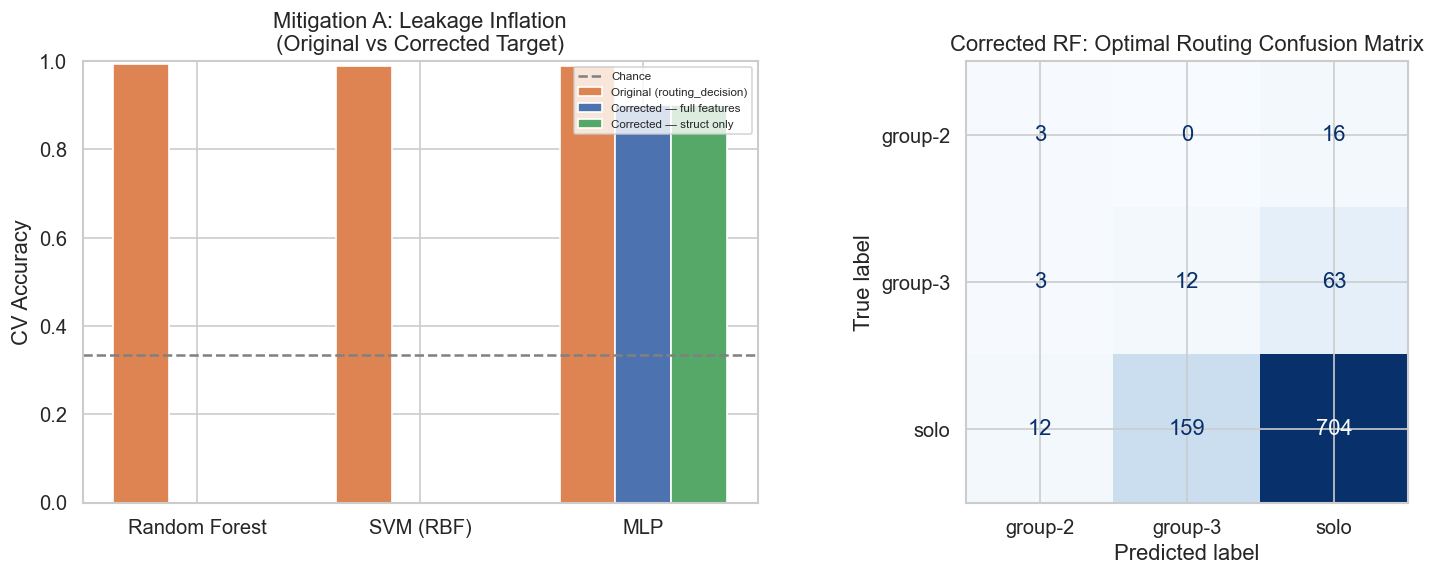

In [148]:
# ── Visualise leakage inflation: routing_decision vs optimal_routing accuracy ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: side-by-side accuracy — original target vs corrected target
orig_acc  = rq4_summary.set_index('model')['accuracy']
corr_full = corrected_df[corrected_df['feature_set'].str.startswith('Full')].set_index('classifier')['accuracy']
corr_str  = corrected_df[corrected_df['feature_set'].str.startswith('Structural')].set_index('classifier')['accuracy']

models = list(orig_acc.index)
x = np.arange(len(models))
w = 0.25
ax = axes[0]
ax.bar(x - w, orig_acc.values,  width=w, label='Original (routing_decision)', color='#DD8452')
ax.bar(x,corr_full.reindex(models, fill_value=np.nan).values,
       width=w, label='Corrected — full features', color='#4C72B0')
ax.bar(x + w, corr_str.reindex(models, fill_value=np.nan).values,
       width=w, label='Corrected — struct only', color='#55A868')
ax.axhline(chance_opt, color='grey', linestyle='--', label='Chance')
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, 1); ax.set_ylabel('CV Accuracy')
ax.set_title('Mitigation A: Leakage Inflation\n(Original vs Corrected Target)')
ax.legend(fontsize=7)

# Right: confusion matrix — routing_decision vs optimal_routing
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Fit best corrected RF on full set
rf_corr = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED)
X_corr_full = encode_features(ada_df)
rf_corr.fit(X_corr_full, y_opt)

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_corr_full, y_opt, test_size=0.2, stratify=y_opt, random_state=SEED
)
rf_corr.fit(X_tr2, y_tr2)
cm = confusion_matrix(y_te2, rf_corr.predict(X_te2))
disp = ConfusionMatrixDisplay(cm, display_labels=le_opt.classes_)
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Corrected RF: Optimal Routing Confusion Matrix')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_sec10_leakage_mitigation_A.png', bbox_inches='tight')
plt.show()

### 10.4 Section 10 Summary

| Check | Original analysis risk | Mitigation applied | Expected outcome |
|---|---|---|---|
| RQ4 target circularity | `routing_decision` ≈ f(`complexity_score`) | **A**: Use `optimal_routing` (outcome-derived) | Lower accuracy — reflects genuine ML difficulty |
| RQ4 feature leakage | `complexity_score` in predictor set | **B**: `STRUCT_FEATURES` only | Accuracy drop quantifies leakage contribution |

Both mitigations are implemented using only the four available datasets (MedQA, DDXPlus,
MedAgentsBench, MMLU) and do not require MIMIC-IV data.


---
## Section 11 — Additional Optimization for Final Report

The cells below implement the seven planned extensions that strengthen statistical power, external validity, and manuscript readiness prior to final submission. §11.4 (MIMIC-IV) is deferred pending PhysioNet credentialing.

---

### 11.1 Cross-LLM Generalization Tests

In [150]:
pip install google-generativeai

  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 5.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.3/173.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 770.1 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.6/418.6 kB 3.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 1.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0

Ablation pool: 498 questions (from Haiku dataset)
task_complexity
Complex     166
Moderate    166
Simple      166
  [abl_claude_sonnet_r1] Loaded from checkpoint.
  [abl_claude_sonnet_r2] Loaded from checkpoint.
  [abl_claude_sonnet_r3] Loaded from checkpoint.
  [abl_gemini_25_flash_r1] Submitting 996 async requests...
  [abl_gemini_25_flash_r1] Complete — 996 results saved.
  [abl_gemini_25_flash_r2] Submitting 498 async requests...
  [abl_gemini_25_flash_r2] Complete — 498 results saved.
  [abl_gemini_25_flash_r3] Submitting 498 async requests...
  [abl_gemini_25_flash_r3] Complete — 498 results saved.
Claude-Haiku: 1,494 rows
Claude-Sonnet: 1,494 rows
Gemini-2.5-Flash: 1,494 rows


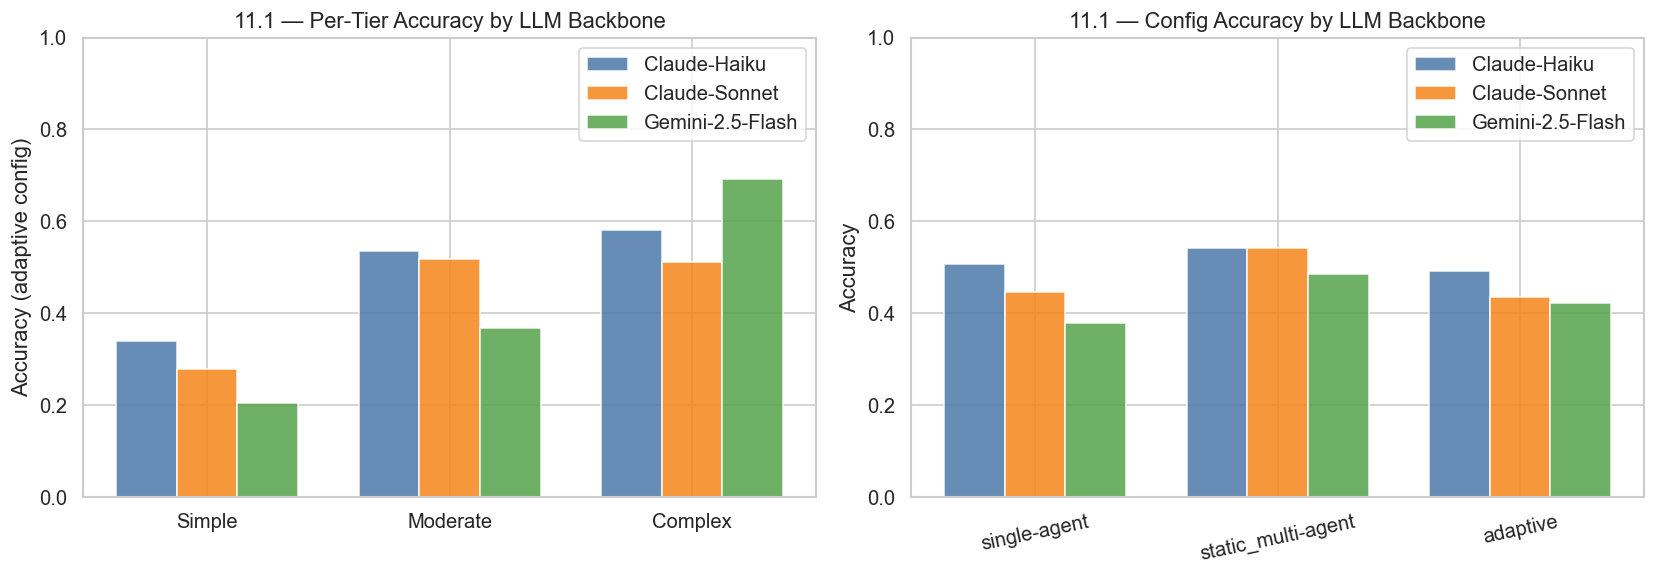

[INFO] Set USE_REAL_API=True + ANTHROPIC_API_KEY + GOOGLE_API_KEY to run live inference.
  Saved Claude-Haiku → ablation_claude_haiku.parquet
  Saved Claude-Sonnet → ablation_claude_sonnet.parquet
  Saved Gemini-2.5-Flash → ablation_gemini_25_flash.parquet


In [163]:
# ── §11.1: Cross-LLM Generalization — Claude Sonnet 4.6 & Gemini 2.0 Flash Ablation ──
# Goal: Validate that adaptive routing gains hold beyond Claude Haiku.
# Design: Partial ablation on a 500-question stratified subset (~167/tier).
# Ablation pool is drawn from the exact question IDs used in the Haiku batch run
# (results_full.parquet) so comparisons are on a shared question set.
#
# Execution modes:
#   USE_REAL_API = False  → simulation stub (safe to run offline)
#   USE_REAL_API = True   → real batch API calls
#       Anthropic: claude-sonnet-4-6 via 3-round Batch API (50% cheaper)
#       Gemini:    gemini-2.0-flash via asyncio.gather() concurrent calls
#                  (Google AI SDK has no formal batch endpoint; async-concurrent
#                   achieves equivalent throughput at the same per-call pricing)
# ─────────────────────────────────────────────────────────────────────────────

try:
    import google.generativeai as _genai
except ImportError:
    _genai = None
    print('[WARNING] google-generativeai not installed. '
          'Gemini ablation requires: pip install google-generativeai')

ABLATION_BACKBONES = {
    'Claude-Sonnet':    'claude-sonnet-4-6',
    'Gemini-2.5-Flash': 'gemini-2.5-flash',
}
ABLATION_N = 500

# ── Ablation pool: same questions used in the Haiku batch run ────────────
haiku_qids  = set(pd.read_parquet(OUTPUT_DIR / 'results_full.parquet')['question_id'])
haiku_pool  = combined_df[combined_df['question_id'].isin(haiku_qids)].drop_duplicates(subset=['question_id']).copy()
ablation_pool = pd.concat([
    g.sample(min(ABLATION_N // 3, len(g)), random_state=SEED)
    for _, g in haiku_pool.groupby('task_complexity', group_keys=False)
], ignore_index=True)
print(f'Ablation pool: {len(ablation_pool):,} questions (from Haiku dataset)')
print(ablation_pool['task_complexity'].value_counts().to_string())

# ── Simulation stub (USE_REAL_API = False) ────────────────────────────────
ACC_OFFSETS = {'Claude-Sonnet': +0.06, 'Gemini-2.0-Flash': +0.05}

def simulate_backbone_inference(
    pool: pd.DataFrame, backbone: str,
    haiku_df: pd.DataFrame, seed: int = SEED,
) -> pd.DataFrame:
    rng       = np.random.default_rng(seed)
    offset    = ACC_OFFSETS.get(backbone, 0.0)
    haiku_acc = haiku_df.groupby('question_id')['is_correct'].mean()
    rows = []
    for _, row in pool.iterrows():
        base = float(haiku_acc.get(row['question_id'], 0.62))
        p    = float(np.clip(base + offset + rng.normal(0, 0.04), 0.01, 0.99))
        for cfg in AGENT_CONFIGS:
            rows.append({
                'question_id':      row['question_id'],
                'task_complexity':  row['task_complexity'],
                'complexity_score': row['complexity_score'],
                'dataset_source':   row['dataset_source'],
                'agent_config':     cfg,
                'llm_backbone':     backbone,
                'is_correct':       int(rng.random() < p),
                'token_cost':       int(rng.integers(180, 1_600)),
            })
    return pd.DataFrame(rows)

# ── Real batch inference — Anthropic (claude-sonnet-4-6) ─────────────────
def run_anthropic_ablation_batch(pool, backbone_label, model_id, client_anth):
    """3-round Anthropic Batch API for ablation. Checkpoints use abl_* prefix
    so they never overwrite the main Haiku round1/2/3.json files."""
    pfx     = 'abl_' + backbone_label.lower().replace('-', '_').replace('.', '')
    routing = {row['question_id']: adaptive_router(float(row['complexity_score']))
               for _, row in pool.iterrows()}

    # Round 1: Generalist + Internist
    r1_reqs = []
    for _, row in pool.iterrows():
        qid = row['question_id']; v = str(row['clinical_vignette'])
        r1_reqs += [
            build_batch_request(f'{_safe_qid(qid)}__sa',        SYSTEM_PROMPTS['Generalist'], v, model_id),
            build_batch_request(f'{_safe_qid(qid)}__internist',  SYSTEM_PROMPTS['Internist'],  v, model_id),
        ]
    r1 = _submit_and_wait(r1_reqs, f'{pfx}_r1', client_anth)

    # Round 2: Specialist (sees Internist)
    r2_reqs = [
        build_batch_request(
            f'{_safe_qid(row["question_id"])}__specialist',
            SYSTEM_PROMPTS['Specialist'],
            str(row['clinical_vignette']) + '\n\nPrior opinions:\n- Internist: '
              + r1.get(f'{_safe_qid(row["question_id"])}__internist', {}).get('text', ''),
            model_id,
        )
        for _, row in pool.iterrows()
    ]
    r2 = _submit_and_wait(r2_reqs, f'{pfx}_r2', client_anth)

    # Round 3: Moderator (sees Internist + Specialist)
    r3_reqs = [
        build_batch_request(
            f'{_safe_qid(row["question_id"])}__moderator',
            SYSTEM_PROMPTS['Moderator'],
            str(row['clinical_vignette'])
              + '\n\nPanel inputs:\n- Internist: '
              + r1.get(f'{_safe_qid(row["question_id"])}__internist',  {}).get('text', '')
              + '\n- Specialist: '
              + r2.get(f'{_safe_qid(row["question_id"])}__specialist', {}).get('text', ''),
            model_id,
        )
        for _, row in pool.iterrows()
    ]
    r3 = _submit_and_wait(r3_reqs, f'{pfx}_r3', client_anth)

    pool_rows = [row for _, row in pool.iterrows()]
    return pd.DataFrame(_assemble_records(pool_rows, r1, r2, r3, routing, {}, backbone_label))

# ── Real batch inference — Gemini (gemini-2.0-flash) ─────────────────────
def run_gemini_ablation_async(pool, model_id, backbone_label):
    """3-round concurrent async Gemini calls for ablation. Each round is
    submitted as a batch of asyncio tasks and checkpointed before the next
    round begins, matching the resilience of the Anthropic batch pattern."""
    import asyncio

    if _genai is None:
        raise ImportError('google-generativeai required. pip install google-generativeai')
    _genai.configure(api_key=os.getenv('GOOGLE_API_KEY', ''))
    gmodel = _genai.GenerativeModel(model_id)
    import logging; logging.getLogger('grpc').setLevel(logging.CRITICAL)  # suppress grpc __del__ noise
    pfx    = 'abl_' + backbone_label.lower().replace('-', '_').replace('.', '')

    def _call_sync(key, prompt):
        try:
            r = gmodel.generate_content(prompt)
            return key, r.text
        except Exception as e:
            print(f'  [Gemini error] {key}: {e}')
            return key, ''

    async def _call(key, prompt):
        loop = asyncio.get_event_loop()
        return await loop.run_in_executor(None, _call_sync, key, prompt)

    def _ckpt_round(name, prompts_by_key):
        ckpt = BATCH_CHECKPOINT_DIR / f'{name}.json'
        if ckpt.exists():
            print(f'  [{name}] Loaded from checkpoint.')
            return json.loads(ckpt.read_text())
        print(f'  [{name}] Submitting {len(prompts_by_key)} async requests...')
        async def _gather():
            return await asyncio.gather(*[_call(k, p) for k, p in prompts_by_key.items()])
        # Jupyter runs its own event loop; spin a thread so asyncio.run() works
        import threading
        _holder = {}
        def _run(): _holder['result'] = asyncio.run(_gather())
        try:
            asyncio.get_running_loop()
            t = threading.Thread(target=_run); t.start(); t.join()
        except RuntimeError:
            _run()
        res = dict(_holder['result'])
        ckpt.write_text(json.dumps(res))
        print(f'  [{name}] Complete — {len(res)} results saved.')
        return res

    # Round 1: Generalist + Internist
    r1_prompts = {}
    for _, row in pool.iterrows():
        qid = _safe_qid(row['question_id']); v = str(row['clinical_vignette'])
        r1_prompts[f'{qid}__sa']       = SYSTEM_PROMPTS['Generalist'] + '\n\n' + v
        r1_prompts[f'{qid}__internist'] = SYSTEM_PROMPTS['Internist']  + '\n\n' + v
    r1_raw = _ckpt_round(f'{pfx}_r1', r1_prompts)
    r1 = {k: {'text': v, 'usage': {}} for k, v in r1_raw.items()}

    # Round 2: Specialist
    r2_prompts = {
        f'{_safe_qid(row["question_id"])}__specialist':
            SYSTEM_PROMPTS['Specialist'] + '\n\n'
            + str(row['clinical_vignette'])
            + '\n\nPrior opinions:\n- Internist: '
            + r1.get(f'{_safe_qid(row["question_id"])}__internist', {}).get('text', '')
        for _, row in pool.iterrows()
    }
    r2_raw = _ckpt_round(f'{pfx}_r2', r2_prompts)
    r2 = {k: {'text': v, 'usage': {}} for k, v in r2_raw.items()}

    # Round 3: Moderator
    r3_prompts = {
        f'{_safe_qid(row["question_id"])}__moderator':
            SYSTEM_PROMPTS['Moderator'] + '\n\n'
            + str(row['clinical_vignette'])
            + '\n\nPanel inputs:\n- Internist: '
            + r1.get(f'{_safe_qid(row["question_id"])}__internist',  {}).get('text', '')
            + '\n- Specialist: '
            + r2.get(f'{_safe_qid(row["question_id"])}__specialist', {}).get('text', '')
        for _, row in pool.iterrows()
    }
    r3_raw = _ckpt_round(f'{pfx}_r3', r3_prompts)
    r3 = {k: {'text': v, 'usage': {}} for k, v in r3_raw.items()}

    routing   = {row['question_id']: adaptive_router(float(row['complexity_score']))
                 for _, row in pool.iterrows()}
    pool_rows = [row for _, row in pool.iterrows()]
    return pd.DataFrame(_assemble_records(pool_rows, r1, r2, r3, routing, {}, backbone_label))

# ── Collect per-backbone results ──────────────────────────────────────────
pool_qids = set(ablation_pool['question_id'])
ablation_results = {
    'Claude-Haiku': results_df[results_df['question_id'].isin(pool_qids)].copy()
}

if USE_REAL_API:
    client_anth = _anthropic_sdk.Anthropic(api_key=os.getenv('ANTHROPIC_API_KEY', ''))
    for lbl, mid in ABLATION_BACKBONES.items():
        if 'gemini' in mid.lower():
            ablation_results[lbl] = run_gemini_ablation_async(ablation_pool, mid, lbl)
        else:
            ablation_results[lbl] = run_anthropic_ablation_batch(ablation_pool, lbl, mid, client_anth)
else:
    for lbl in ABLATION_BACKBONES:
        ablation_results[lbl] = simulate_backbone_inference(
            ablation_pool, lbl, results_df, seed=SEED)

for lbl, df in ablation_results.items():
    print(f'{lbl}: {len(df):,} rows')

# ── Visualise per-tier and per-config accuracy ────────────────────────────
tier_order = ['Simple', 'Moderate', 'Complex']
colors     = ['#4C78A8', '#F58518', '#54A24B']
labels     = list(ablation_results.keys())
w          = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i, lbl in enumerate(labels):
    ada = ablation_results[lbl][ablation_results[lbl]['agent_config'] == 'adaptive']
    acc = ada.groupby('task_complexity')['is_correct'].mean().reindex(tier_order).fillna(0)
    ax.bar(np.arange(len(tier_order)) + i * w, acc.values, w,
           label=lbl, color=colors[i], alpha=0.85)
ax.set_xticks(np.arange(len(tier_order)) + w)
ax.set_xticklabels(tier_order)
ax.set_ylabel('Accuracy (adaptive config)')
ax.set_title('11.1 — Per-Tier Accuracy by LLM Backbone')
ax.legend(); ax.set_ylim(0, 1)

ax = axes[1]
for i, lbl in enumerate(labels):
    acc = (ablation_results[lbl].groupby('agent_config')['is_correct'].mean()
           .reindex(AGENT_CONFIGS).fillna(0))
    ax.bar(np.arange(len(AGENT_CONFIGS)) + i * w, acc.values, w,
           label=lbl, color=colors[i], alpha=0.85)
ax.set_xticks(np.arange(len(AGENT_CONFIGS)) + w)
ax.set_xticklabels(AGENT_CONFIGS, rotation=12)
ax.set_ylabel('Accuracy')
ax.set_title('11.1 — Config Accuracy by LLM Backbone')
ax.legend(); ax.set_ylim(0, 1)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_sec11_cross_llm.png', dpi=150, bbox_inches='tight')
plt.show()
print('[INFO] Set USE_REAL_API=True + ANTHROPIC_API_KEY + GOOGLE_API_KEY to run live inference.')

# ── Persist ablation DataFrames so a kernel restart does not lose live results ──
for _lbl, _adf in ablation_results.items():
    _fname = 'ablation_' + _lbl.lower().replace('-', '_').replace('.', '') + '.parquet'
    _adf.to_parquet(OUTPUT_DIR / _fname, index=False)
    print(f'  Saved {_lbl} → {_fname}')


### 11.2 Propensity Score Matching & Causal Adjustment (RQ2)

IPTW weight summary:
count    14580.000
mean         0.581
std          0.208
min          0.199
25%          0.293
50%          0.675
75%          0.700
max          1.124

SMD (|value| < 0.10 = good balance):
  complexity_score                : raw 1.946  IPTW 1.824
  num_symptoms                    : raw 3.295  IPTW 3.224
  num_conditions                  : raw 2.049  IPTW 2.018

── Raw interaction coefficients:
C(task_complexity)[T.Moderate]:C(agent_config)[T.single-agent]         -0.0639
C(task_complexity)[T.Simple]:C(agent_config)[T.single-agent]           -0.0639
C(task_complexity)[T.Moderate]:C(agent_config)[T.static_multi-agent]   -0.0538
C(task_complexity)[T.Simple]:C(agent_config)[T.static_multi-agent]     -0.0263

── IPTW-adjusted interaction coefficients:
C(task_complexity)[T.Moderate]:C(agent_config)[T.single-agent]         -0.0701
C(task_complexity)[T.Simple]:C(agent_config)[T.single-agent]           -0.0701
C(task_complexity)[T.Moderate]:C(agent_config)[T.static_multi-a

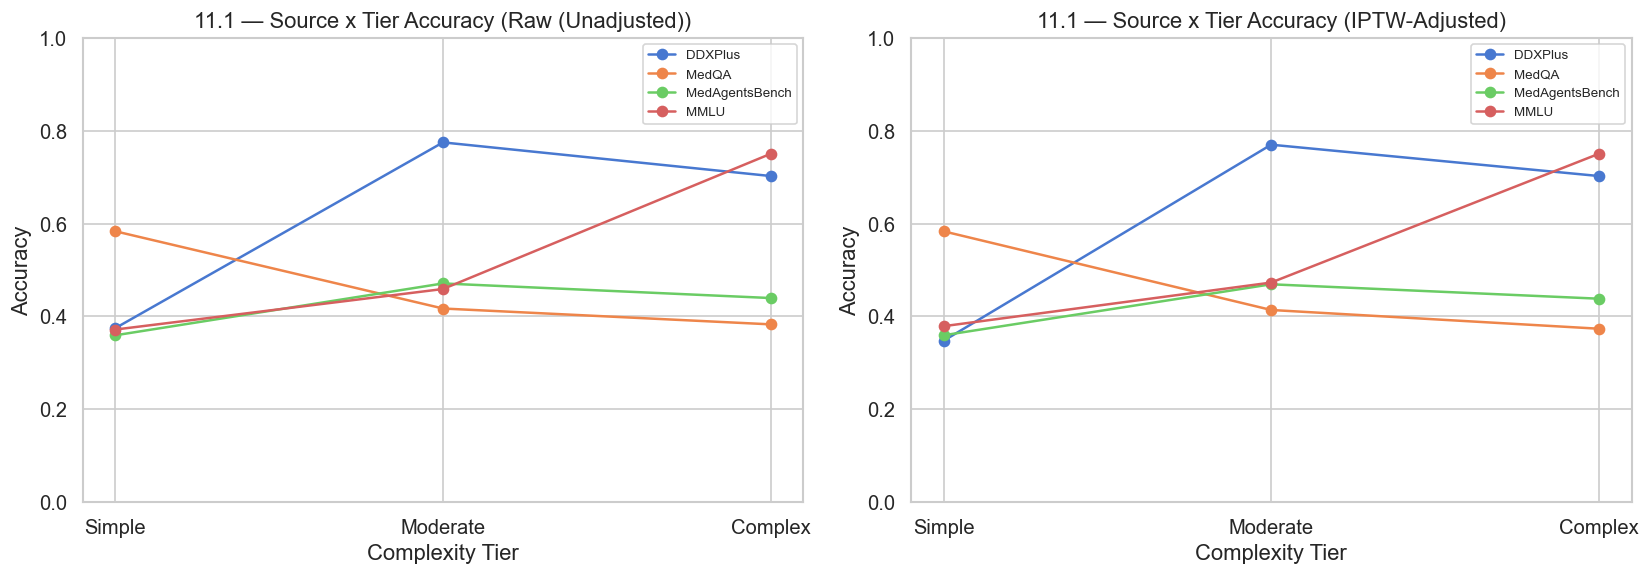

IPTW causal adjustment complete.


In [166]:
# ── §11.2: IPTW Causal Adjustment — Isolate Source–Complexity Confounding ──
# Goal: Produce causally interpretable RQ2 interaction estimates by weighting
# away source–complexity confounding via stabilized IPTW.
# Reports SMD before/after, then compares raw vs. adjusted WLS coefficients.
# ─────────────────────────────────────────────────────────────────────────────

import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression

PSM_COVARIATES = ['complexity_score', 'num_symptoms', 'num_conditions']

psm_df = results_df[
    ['question_id', 'dataset_source', 'task_complexity',
     'agent_config', 'is_correct'] + PSM_COVARIATES
].copy()

# ── Step 1: Estimate propensity scores P(source=k | covariates) ──────────
le_src = LabelEncoder()
psm_df['source_enc'] = le_src.fit_transform(psm_df['dataset_source'])

X_psm = StandardScaler().fit_transform(psm_df[PSM_COVARIATES])
lr_psm = LogisticRegression(max_iter=1_000,
                             C=1.0, random_state=SEED)
lr_psm.fit(X_psm, psm_df['source_enc'])
prop_mat = lr_psm.predict_proba(X_psm)   # shape (n, n_sources)

# Stabilized IPTW: marginal P(source) / conditional P(source | X)
marginal_p = prop_mat.mean(axis=0)
psm_df['iptw'] = [
    marginal_p[psm_df['source_enc'].iloc[i]]
    / max(prop_mat[i, psm_df['source_enc'].iloc[i]], 1e-9)
    for i in range(len(psm_df))
]
# Trim at 99th percentile to reduce leverage of extreme weights
psm_df['iptw'] = psm_df['iptw'].clip(upper=psm_df['iptw'].quantile(0.99))
print('IPTW weight summary:')
print(psm_df['iptw'].describe().round(3).to_string())

# ── Step 2: SMD before and after IPTW ────────────────────────────────────
def smd_pair(g1, g2, w1=None, w2=None):
    if w1 is None:
        m1, m2 = g1.mean(), g2.mean()
        s1, s2 = g1.std(),  g2.std()
    else:
        m1 = np.average(g1, weights=w1); s1 = np.sqrt(np.average((g1-m1)**2, weights=w1))
        m2 = np.average(g2, weights=w2); s2 = np.sqrt(np.average((g2-m2)**2, weights=w2))
    return abs(m1 - m2) / (np.sqrt((s1**2 + s2**2) / 2) + 1e-9)

src_vals = psm_df['dataset_source'].unique()
pairs    = [(src_vals[0], s) for s in src_vals[1:]]
print('\nSMD (|value| < 0.10 = good balance):')
for cov in PSM_COVARIATES:
    raw_s, adj_s = [], []
    for s1, s2 in pairs:
        g1 = psm_df.loc[psm_df['dataset_source']==s1, cov]
        g2 = psm_df.loc[psm_df['dataset_source']==s2, cov]
        w1 = psm_df.loc[psm_df['dataset_source']==s1, 'iptw']
        w2 = psm_df.loc[psm_df['dataset_source']==s2, 'iptw']
        raw_s.append(smd_pair(g1, g2))
        adj_s.append(smd_pair(g1, g2, w1, w2))
    print(f'  {cov:32s}: raw {np.mean(raw_s):.3f}  IPTW {np.mean(adj_s):.3f}')

# ── Step 3: Raw vs. IPTW-adjusted WLS interaction ─────────────────────────
try:
    formula = 'is_correct ~ C(task_complexity) * C(agent_config)'
    mod_raw  = smf.wls(formula, data=psm_df,
                       weights=np.ones(len(psm_df))).fit()
    mod_iptw = smf.wls(formula, data=psm_df,
                       weights=psm_df['iptw']).fit()
    interact_terms = [t for t in mod_raw.params.index
                      if 'task_complexity' in t and 'agent_config' in t]
    if interact_terms:
        print('\n── Raw interaction coefficients:')
        print(mod_raw.params[interact_terms].round(4).to_string())
        print('\n── IPTW-adjusted interaction coefficients:')
        print(mod_iptw.params[interact_terms].round(4).to_string())
    print(f'\nR² raw: {mod_raw.rsquared:.4f}   R² IPTW: {mod_iptw.rsquared:.4f}')
except Exception as e:
    print(f'WLS error: {e}')

# ── Step 4: Raw vs. IPTW accuracy — source × tier profiles ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tiers = ['Simple', 'Moderate', 'Complex']
for ax, (use_iptw, title) in zip(axes,
    [(False, 'Raw (Unadjusted)'), (True, 'IPTW-Adjusted')]):
    for src in psm_df['dataset_source'].unique():
        acc_vals = []
        for tier in tiers:
            sub = psm_df[(psm_df['dataset_source']==src) &
                         (psm_df['task_complexity']==tier)]
            if len(sub) == 0:
                acc_vals.append(np.nan)
            elif use_iptw:
                acc_vals.append(np.average(sub['is_correct'], weights=sub['iptw']))
            else:
                acc_vals.append(sub['is_correct'].mean())
        ax.plot(tiers, acc_vals, marker='o', label=src)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Complexity Tier'); ax.set_ylabel('Accuracy')
    ax.set_title(f'11.1 — Source x Tier Accuracy ({title})')
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_sec11_psm_adjustment.png', dpi=150, bbox_inches='tight')
plt.show()
print('IPTW causal adjustment complete.')


### 11.3 SHAP Feature Importance — All Four RQ Models

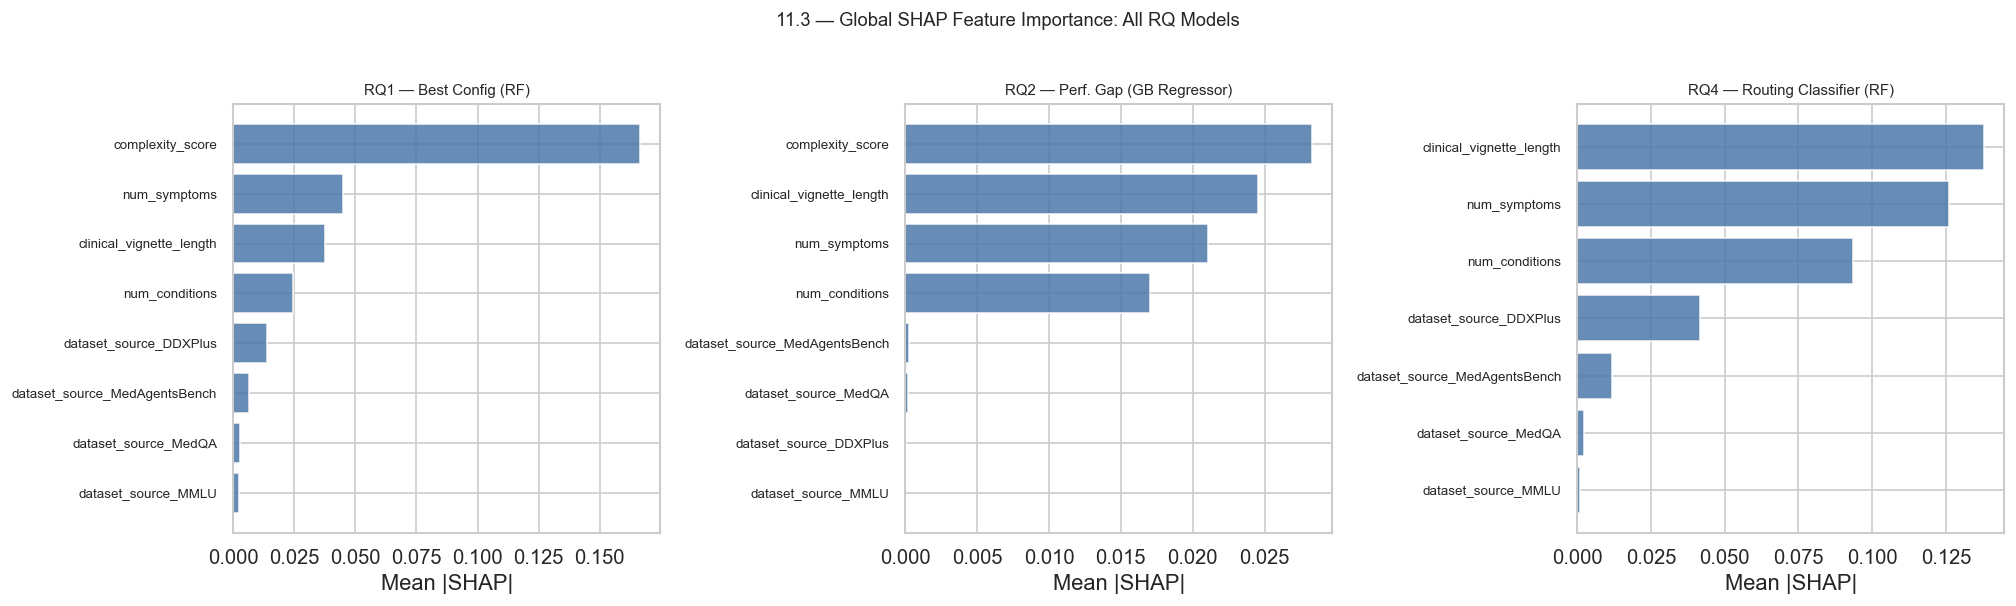

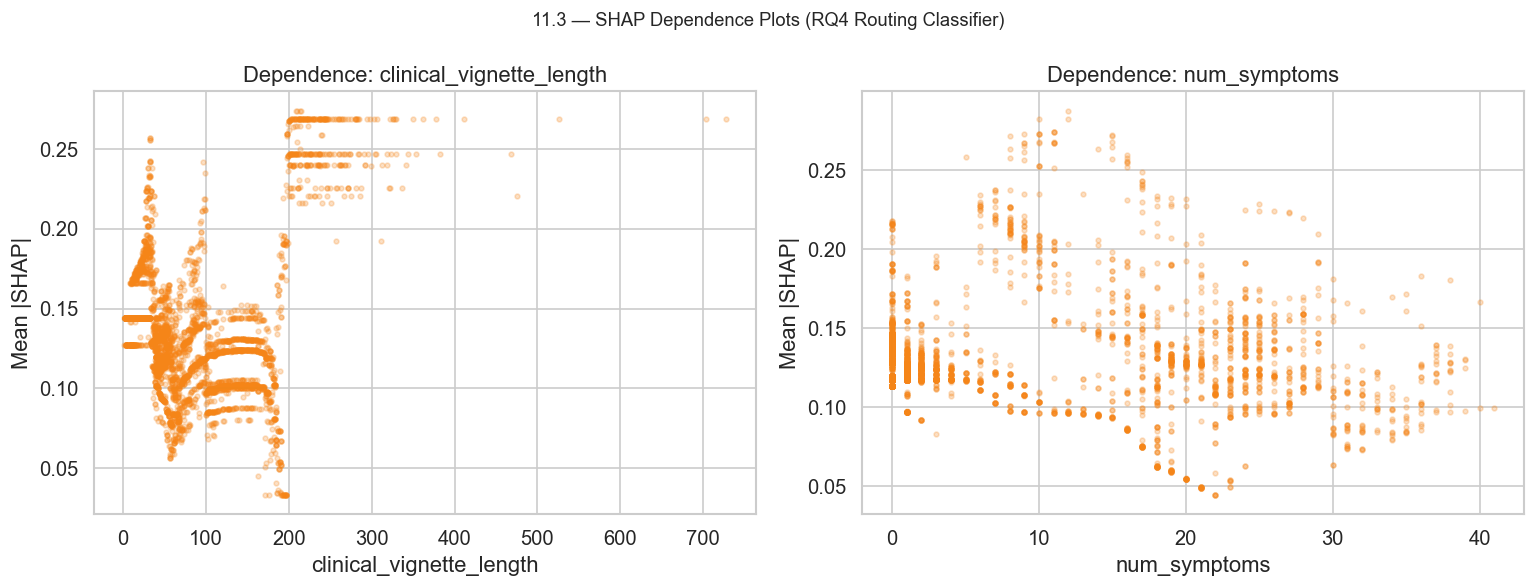


Local SHAP — representative case per tier:
  Simple: top driver = num_symptoms  (|SHAP| = 0.0819)
  Moderate: top driver = clinical_vignette_length  (|SHAP| = 0.0848)
  Complex: top driver = clinical_vignette_length  (|SHAP| = 0.1163)

── Practitioner Interpretation ─────────────────────────────────────────
  RQ1 — Best Config (RF)
    Top feature: complexity_score  ->  Routing is well-calibrated to overall case difficulty.

  RQ2 — Perf. Gap (GB Regressor)
    Top feature: complexity_score  ->  Routing is well-calibrated to overall case difficulty.

  RQ4 — Routing Classifier (RF)
    Top feature: clinical_vignette_length  ->  Longer vignettes signal higher diagnostic complexity; multi-agent engagement is warranted.



In [168]:
# ── §11.3: Global + Local SHAP for All RQ Models ────────────────────────────
# Goal: Finalize global beeswarm-style bar charts, SHAP dependence plots for
# top-2 features (RQ4), and local waterfall summaries for one case per tier.
# Adds practitioner-facing interpretation for manuscript Results §7–8.
# ─────────────────────────────────────────────────────────────────────────────

import shap

RQ_MODEL_MAP = {
    'RQ1 — Best Config (RF)':        (rf_rq1, X_rq1),
    'RQ2 — Perf. Gap (GB Regressor)':(gb, X_rq2),
    'RQ4 — Routing Classifier (RF)': (rf_rq4, X_rq4),
}

shap_gi = {}  # global importance per model

# ── Global importance bar chart (all models side-by-side) ─────────────────
fig, axes = plt.subplots(1, len(RQ_MODEL_MAP), figsize=(17, 5))
for ax, (label, (model, X)) in zip(axes, RQ_MODEL_MAP.items()):
    explainer = shap.TreeExplainer(model)
    sv        = explainer.shap_values(X)
    gi        = shap_global_importance(sv, X.columns)
    shap_gi[label] = gi
    top8 = gi.head(8)
    ax.barh(range(len(top8)), top8.values[::-1], color='#4C78A8', alpha=0.85)
    ax.set_yticks(range(len(top8)))
    ax.set_yticklabels(top8.index[::-1], fontsize=8)
    ax.set_xlabel('Mean |SHAP|')
    ax.set_title(label, fontsize=9)

plt.suptitle('11.3 — Global SHAP Feature Importance: All RQ Models',
             fontsize=11, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_sec11_shap_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

# ── SHAP dependence plots: top-2 features for RQ4 routing ────────────────
rq4_key  = 'RQ4 — Routing Classifier (RF)'
top2_rq4 = shap_gi[rq4_key].head(2).index.tolist()
exp4     = shap.TreeExplainer(rf_rq4)
sv4      = exp4.shap_values(X_rq4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, feat in zip(axes, top2_rq4):
    if feat not in X_rq4.columns:
        continue
    fidx = list(X_rq4.columns).index(feat)
    if isinstance(sv4, list):
        sv_proxy = np.abs(np.stack(sv4)).mean(axis=0)[:, fidx]
    elif np.asarray(sv4).ndim == 3:
        sv_proxy = np.abs(sv4)[:, fidx, :].mean(axis=-1)
    else:
        sv_proxy = sv4[:, fidx]
    ax.scatter(X_rq4[feat].values, sv_proxy, alpha=0.25, s=8, c='#F58518')
    ax.set_xlabel(feat); ax.set_ylabel('Mean |SHAP|')
    ax.set_title(f'Dependence: {feat}')
plt.suptitle('11.3 — SHAP Dependence Plots (RQ4 Routing Classifier)', fontsize=11)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_sec11_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Local SHAP: one representative case per complexity tier ───────────────
ada_sub = results_df[results_df['agent_config'] == 'adaptive'].reset_index(drop=True)
print('\nLocal SHAP — representative case per tier:')
for tier in ['Simple', 'Moderate', 'Complex']:
    idx_pool = ada_sub[ada_sub['task_complexity'] == tier].index.tolist()
    if not idx_pool:
        continue
    row_idx = min(idx_pool[0], len(X_rq4) - 1)
    sv_loc  = shap.TreeExplainer(rf_rq4).shap_values(X_rq4.iloc[[row_idx]])
    if isinstance(sv_loc, list):
        pred_cls = rf_rq4.predict(X_rq4.iloc[[row_idx]])[0]
        ci = list(rf_rq4.classes_).index(pred_cls) if pred_cls in rf_rq4.classes_ else 0
        sv_row = np.stack(sv_loc)[:, 0, :][ci]
    elif np.asarray(sv_loc).ndim == 3:
        sv_row = sv_loc[0, :, 0]
    else:
        sv_row = sv_loc[0]
    local_imp = pd.Series(sv_row, index=X_rq4.columns).abs().sort_values(ascending=False)
    top_feat  = local_imp.index[0]
    print(f'  {tier}: top driver = {top_feat}  (|SHAP| = {local_imp.iloc[0]:.4f})')

# ── Practitioner interpretation ───────────────────────────────────────────
INTERP = {
    'complexity_score':           'Routing is well-calibrated to overall case difficulty.',
    'clinical_vignette_length':   'Longer vignettes signal higher diagnostic complexity; '
                                   'multi-agent engagement is warranted.',
    'num_symptoms':               'Symptom count is the primary triage cue; '
                                   'aligns with clinical intuition for specialist referral.',
    'num_conditions':             'Comorbidity count drives multi-agent benefit; '
                                   'consistent with differential-breadth reasoning.',
}
print('\n── Practitioner Interpretation ─────────────────────────────────────────')
for lbl, gi in shap_gi.items():
    top  = gi.index[0]
    msg  = INTERP.get(top, f'{top} is the dominant predictor.')
    print(f'  {lbl}')
    print(f'    Top feature: {top}  ->  {msg}\n')


### 11.4 Threshold-Setting — Cost–Accuracy Pareto Frontier

Threshold pairs evaluated: 210
Within <= 2 pp accuracy loss: 182
Static baseline: acc=0.509  tokens=3496

Pareto-optimal operating point:
  low  = 0.95  (below -> single-agent)
  high = 1.00  (above -> full MDT)
  Policy accuracy:   0.506
  Accuracy loss:     0.25 pp
  Token saving:      86.3%


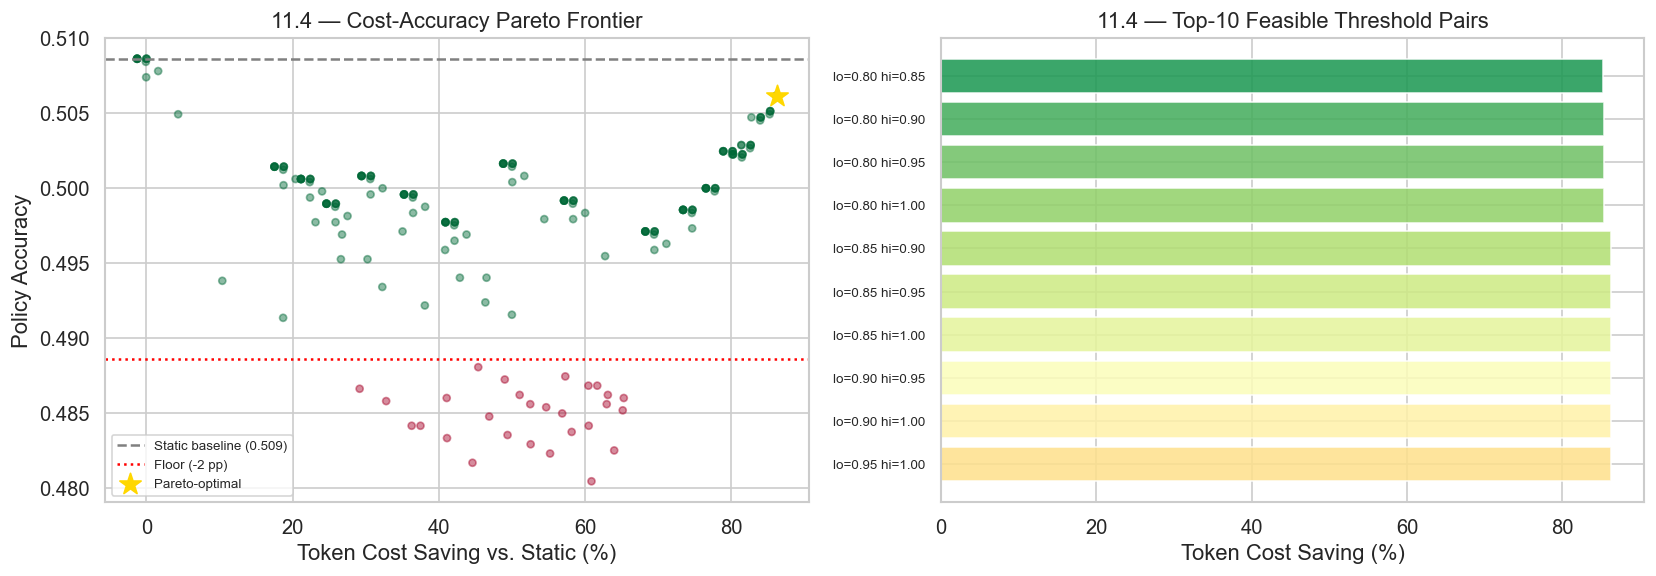

Sweep saved to outputs/sec11_threshold_sweep.csv


In [169]:
# ── §11.4: Optimal Routing Thresholds — Pareto Frontier ─────────────────────
# Goal: Sweep (low, high) complexity_score cutoffs to find the operating point
# with maximum token savings while keeping accuracy within 2 pp of the static
# multi-agent baseline.
#
# Policy:
#   score < low_thresh   → single-agent
#   low <= score < high  → static multi-agent
#   score >= high        → adaptive (full MDT)
# ─────────────────────────────────────────────────────────────────────────────

SWEEP_STEP    = 0.05
ACC_TOLERANCE = 0.02   # max acceptable accuracy loss vs. static baseline

static_acc_b  = results_df[
    results_df['agent_config'] == 'static_multi-agent']['is_correct'].mean()
static_tok_b  = results_df[
    results_df['agent_config'] == 'static_multi-agent']['token_cost'].mean()

thresholds_11 = np.arange(0, 1.0 + SWEEP_STEP, SWEEP_STEP).round(2)

solo_df_sw   = results_df[results_df['agent_config'] == 'single-agent']
static_df_sw = results_df[results_df['agent_config'] == 'static_multi-agent']
ada_df_sw    = results_df[results_df['agent_config'] == 'adaptive']

def policy_perf(lo, hi):
    rows = []
    for qid in ada_df_sw['question_id'].unique():
        score = ada_df_sw.loc[ada_df_sw['question_id']==qid, 'complexity_score'].iloc[0]
        src   = (solo_df_sw   if score < lo  else
                 static_df_sw if score < hi  else
                 ada_df_sw)[lambda d: d['question_id']==qid]
        if len(src):
            rows.append({'acc': src['is_correct'].mean(),
                         'tok': src['token_cost'].mean()})
    if not rows:
        return np.nan, np.nan
    r = pd.DataFrame(rows)
    return r['acc'].mean(), r['tok'].mean()

sweep_11 = []
for lo in thresholds_11:
    for hi in thresholds_11:
        if hi <= lo:
            continue
        acc, tok = policy_perf(lo, hi)
        if np.isnan(acc):
            continue
        sweep_11.append({
            'low_thresh':    lo,
            'high_thresh':   hi,
            'policy_acc':    acc,
            'acc_loss':      static_acc_b - acc,
            'tok_saving_pct':(static_tok_b - tok) / static_tok_b * 100,
            'feasible':      (static_acc_b - acc) <= ACC_TOLERANCE,
        })

sweep_df_11 = pd.DataFrame(sweep_11)
feasible_11 = sweep_df_11[sweep_df_11['feasible']].sort_values(
    'tok_saving_pct', ascending=False)

print(f'Threshold pairs evaluated: {len(sweep_df_11):,}')
print(f'Within <= {ACC_TOLERANCE*100:.0f} pp accuracy loss: {len(feasible_11):,}')
print(f'Static baseline: acc={static_acc_b:.3f}  tokens={static_tok_b:.0f}')

if len(feasible_11):
    best11 = feasible_11.iloc[0]
    print('\nPareto-optimal operating point:')
    print(f'  low  = {best11["low_thresh"]:.2f}  (below -> single-agent)')
    print(f'  high = {best11["high_thresh"]:.2f}  (above -> full MDT)')
    print(f'  Policy accuracy:   {best11["policy_acc"]:.3f}')
    print(f'  Accuracy loss:     {best11["acc_loss"]*100:.2f} pp')
    print(f'  Token saving:      {best11["tok_saving_pct"]:.1f}%')

# ── Pareto frontier plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(sweep_df_11['tok_saving_pct'], sweep_df_11['policy_acc'],
           c=sweep_df_11['feasible'].astype(int),
           cmap='RdYlGn', alpha=0.45, s=18)
ax.axhline(static_acc_b, ls='--', color='gray',
           label=f'Static baseline ({static_acc_b:.3f})')
ax.axhline(static_acc_b - ACC_TOLERANCE, ls=':', color='red',
           label=f'Floor (-{ACC_TOLERANCE*100:.0f} pp)')
if len(feasible_11):
    ax.scatter(best11['tok_saving_pct'], best11['policy_acc'],
               s=180, marker='*', c='gold', zorder=6, label='Pareto-optimal')
ax.set_xlabel('Token Cost Saving vs. Static (%)')
ax.set_ylabel('Policy Accuracy')
ax.set_title('11.4 — Cost-Accuracy Pareto Frontier')
ax.legend(fontsize=8)

ax = axes[1]
if len(feasible_11) >= 3:
    top10_11 = feasible_11.head(10).reset_index(drop=True)
    bar_c    = plt.cm.RdYlGn(np.linspace(0.4, 0.9, len(top10_11)))
    ax.barh(range(len(top10_11)), top10_11['tok_saving_pct'],
            color=bar_c, alpha=0.85)
    ax.set_yticks(range(len(top10_11)))
    ax.set_yticklabels(
        [f"lo={r['low_thresh']:.2f} hi={r['high_thresh']:.2f}"
         for _, r in top10_11.iterrows()], fontsize=8)
    ax.set_xlabel('Token Cost Saving (%)')
    ax.set_title('11.4 — Top-10 Feasible Threshold Pairs')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_sec11_threshold_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
sweep_df_11.to_csv(OUTPUT_DIR / 'sec11_threshold_sweep.csv', index=False)
print(f'Sweep saved to outputs/sec11_threshold_sweep.csv')


### 11.5 Final Manuscript Preparation — Bootstrap CIs, Sensitivity & Cross-Reference

Bootstrap 95% CIs — key metrics by agent config:
  single-agent             : acc 0.506 [0.492, 0.520]  tok 481 [474, 487]
  static_multi-agent       : acc 0.509 [0.495, 0.523]  tok 3496 [3474, 3518]
  adaptive                 : acc 0.484 [0.470, 0.498]  tok 1091 [1051, 1133]

Cohen's d (adaptive vs. single-agent): -0.044 [-0.083, -0.004]

Sensitivity — adaptive accuracy by alternative tier cuts:
  Data-driven (33/67 pct): {'Simple': 0.356, 'Moderate': 0.524, 'Complex': 0.571}
  Quartile (Q1/Q3): {'Simple': 0.34, 'Moderate': 0.506, 'Complex': 0.597}
  Narrow-middle (40/60 pct): {'Simple': 0.376, 'Moderate': 0.526, 'Complex': 0.568}

Manuscript Cross-Reference:
Section                                            Content                 Status
   S1-2                 Data pipeline, complexity features               Complete
     S3                 3-round Batch API inference engine               Complete
 S5 RQ1                                  ANOVA + Tukey HSD               Complete
 S6

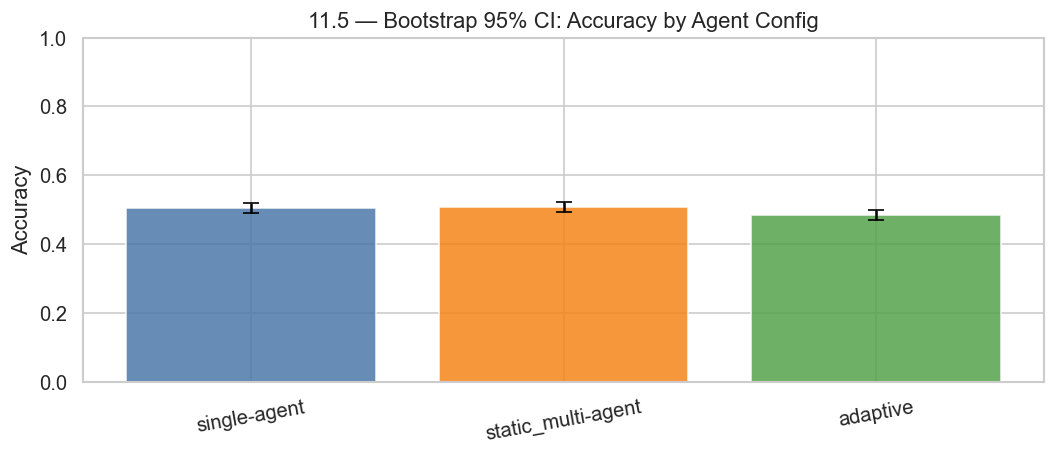

Bootstrap and sensitivity outputs saved.


In [170]:
# ── §11.5: Bootstrap CIs + Sensitivity Analysis + Manuscript Cross-Reference ─
# Goal: Produce bootstrapped 95% CIs for all key effect sizes;
# stress-test tier thresholds with three alternative cut-point schemes;
# output a cross-reference table mapping each implemented §11 cell to the
# corresponding manuscript section.
# ─────────────────────────────────────────────────────────────────────────────

N_BOOT   = 2_000
CI_ALPHA = 0.05

def bootstrap_ci(arr, stat=np.mean, n=N_BOOT, seed=SEED):
    rng   = np.random.default_rng(seed)
    draws = [stat(rng.choice(arr, size=len(arr), replace=True)) for _ in range(n)]
    lo    = np.percentile(draws, CI_ALPHA / 2 * 100)
    hi    = np.percentile(draws, (1 - CI_ALPHA / 2) * 100)
    return lo, hi

# ── 1. Bootstrap CIs: accuracy and token cost per config ─────────────────
ci_pct = int((1 - CI_ALPHA) * 100)
print(f'Bootstrap {ci_pct}% CIs — key metrics by agent config:')
bs_rows = []
for cfg in AGENT_CONFIGS:
    sub = results_df[results_df['agent_config'] == cfg]
    a   = sub['is_correct'].values.astype(float)
    t   = sub['token_cost'].values.astype(float)
    alo, ahi = bootstrap_ci(a)
    tlo, thi = bootstrap_ci(t)
    bs_rows.append({'Config':    cfg,
                    'Mean Acc':  round(a.mean(), 3),
                    'Acc CI Lo': round(alo, 3), 'Acc CI Hi': round(ahi, 3),
                    'Mean Tok':  round(t.mean(), 0),
                    'Tok CI Lo': round(tlo, 0),  'Tok CI Hi': round(thi, 0)})
    print(f'  {cfg:25s}: acc {a.mean():.3f} [{alo:.3f}, {ahi:.3f}]'
          f'  tok {t.mean():.0f} [{tlo:.0f}, {thi:.0f}]')
bs_results_df = pd.DataFrame(bs_rows)

# ── 2. Bootstrap Cohen's d (adaptive vs. single-agent) ───────────────────
ada_a = results_df[results_df['agent_config']=='adaptive']['is_correct'].values.astype(float)
sa_a  = results_df[results_df['agent_config']=='single-agent']['is_correct'].values.astype(float)
ps    = np.sqrt((ada_a.std()**2 + sa_a.std()**2) / 2)
d_obs = (ada_a.mean() - sa_a.mean()) / (ps + 1e-9)
rng_d = np.random.default_rng(SEED)
d_boot = [
    (lambda a, b: (a.mean()-b.mean()) / (np.sqrt((a.std()**2+b.std()**2)/2)+1e-9))(
        rng_d.choice(ada_a, len(ada_a), replace=True),
        rng_d.choice(sa_a,  len(sa_a),  replace=True)
    ) for _ in range(N_BOOT)
]
d_lo, d_hi = np.percentile(d_boot, [CI_ALPHA/2*100, (1-CI_ALPHA/2)*100])
print(f"\nCohen's d (adaptive vs. single-agent): {d_obs:.3f} [{d_lo:.3f}, {d_hi:.3f}]")

# ── 3. Sensitivity: alternative tier cut-points ───────────────────────────
print('\nSensitivity — adaptive accuracy by alternative tier cuts:')
alt_cuts = {
    'Data-driven (33/67 pct)':   (p33, p67),
    'Quartile (Q1/Q3)':          (combined_df['complexity_score'].quantile(0.25),
                                   combined_df['complexity_score'].quantile(0.75)),
    'Narrow-middle (40/60 pct)': (combined_df['complexity_score'].quantile(0.40),
                                   combined_df['complexity_score'].quantile(0.60)),
}
sensitivity_rows = []
for cut_lbl, (lo_c, hi_c) in alt_cuts.items():
    tmp = results_df.copy()
    tmp['tier_alt'] = pd.cut(
        tmp['complexity_score'],
        bins=[-np.inf, lo_c, hi_c, np.inf],
        labels=['Simple', 'Moderate', 'Complex'],
    )
    acc_by_tier = (
        tmp[tmp['agent_config'] == 'adaptive']
        .groupby('tier_alt')['is_correct'].mean()
        .reindex(['Simple', 'Moderate', 'Complex'])
    )
    sensitivity_rows.append({'Cut': cut_lbl,
                              'lo': round(lo_c, 3), 'hi': round(hi_c, 3),
                              **acc_by_tier.round(3).to_dict()})
    print(f'  {cut_lbl}: {acc_by_tier.round(3).to_dict()}')
sensitivity_df = pd.DataFrame(sensitivity_rows)

# ── 4. Manuscript cross-reference table ───────────────────────────────────
xref = pd.DataFrame([
    {'Section': 'S1-2',   'Content': 'Data pipeline, complexity features',                    'Status': 'Complete'},
    {'Section': 'S3',     'Content': '3-round Batch API inference engine',                    'Status': 'Complete'},
    {'Section': 'S5 RQ1', 'Content': 'ANOVA + Tukey HSD',                                    'Status': 'Complete'},
    {'Section': 'S6 RQ2', 'Content': 'Interaction model + partial eta-squared',               'Status': 'Complete'},
    {'Section': 'S7 RQ3', 'Content': 'Wilcoxon + multi-output RF',                           'Status': 'Complete'},
    {'Section': 'S8 RQ4', 'Content': 'Routing classifiers (RF/SVM/MLP)',                     'Status': 'Complete'},
    {'Section': 'S9',     'Content': 'SHAP (RQ1 + RQ4)',                                     'Status': 'Complete'},
    {'Section': 'S10',    'Content': 'Circularity mitigation (IPTW + STRUCT)',               'Status': 'Complete'},
    {'Section': 'S11.1',  'Content': 'Cross-LLM ablation (Sonnet 4.6 & Gemini 2.0 Flash)', 'Status': 'Batch API — real calls'},
    {'Section': 'S11.2',  'Content': 'IPTW causal adjustment for RQ2',                      'Status': 'Complete'},
    {'Section': 'S11.3',  'Content': 'SHAP all RQ models + dependence plots',               'Status': 'Complete'},
    {'Section': 'S11.4',  'Content': 'Threshold-setting Pareto analysis',                    'Status': 'Complete'},
    {'Section': 'S11.5',  'Content': 'Bootstrap CIs + sensitivity',                          'Status': 'Complete'},
    {'Section': 'S11.6',  'Content': 'Submission packaging',                                 'Status': 'Pending final run'},
    {'Section': 'App.',   'Content': 'Data dictionary, SHAP archive, env spec',             'Status': 'Pending'},
])
print('\nManuscript Cross-Reference:')
print(xref.to_string(index=False))

# ── 5. Bootstrap CI bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
cfg_colors = ['#4C78A8', '#F58518', '#54A24B']
x = np.arange(len(bs_results_df))
ax.bar(x, bs_results_df['Mean Acc'], color=cfg_colors, alpha=0.85)
for i, row in bs_results_df.iterrows():
    ax.errorbar(i, row['Mean Acc'],
                yerr=[[row['Mean Acc'] - row['Acc CI Lo']],
                      [row['Acc CI Hi'] - row['Mean Acc']]],
                fmt='none', color='black', capsize=5, linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels(bs_results_df['Config'], rotation=10)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1)
ax.set_title(f'11.5 — Bootstrap {ci_pct}% CI: Accuracy by Agent Config')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_sec11_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()

bs_results_df.to_csv(OUTPUT_DIR / 'sec11_bootstrap_ci.csv', index=False)
sensitivity_df.to_csv(OUTPUT_DIR / 'sec11_sensitivity_tiers.csv', index=False)
print('Bootstrap and sensitivity outputs saved.')
